In [1]:
!conda env list


# conda environments:
#
# * -> active
# + -> frozen
                         /home/njm12/ATMS_523/envs/era5-850
                         /home/njm12/ATMS_523/envs/xarray-climate
base                 *   /opt/conda



In [2]:
!conda run -p /home/njm12/ATMS_523/envs/xarray-climate python -m ipykernel install --user --name xarray-climate --display-name "Python (xarray-climate)"

Installed kernelspec xarray-climate in /home/njm12/.local/share/jupyter/kernels/xarray-climate



In [3]:
import sys
print(sys.executable)

/home/njm12/ATMS_523/envs/xarray-climate/bin/python


In [4]:
# ================================================================
# FIXED CELL: Load UMESC shapefiles + CRS handling
# ================================================================
# Imports and environment setup
import os
import glob
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString, Point, box
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import seaborn as sns
import matplotlib.patches as patches

from sklearn.cluster import DBSCAN
from geopy.distance import geodesic

#Interactive Tool Imports
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook"  # or "notebook_connected"

#Statistical Significance Testing Imports
from scipy.stats import kruskal
import itertools

# ------------------------------------------------
# Ensure PROJ is found (adjust if needed)
# ------------------------------------------------
os.environ["PROJ_LIB"] = "/home/njm12/ATMS_523/envs/xarray-climate/share/proj"

# ------------------------------------------------
# Configuration
# ------------------------------------------------
base_dir = "/home/njm12/ATMS_596/ATMS-596-Capstone-Project/Land-Water"
target_crs = "EPSG:26915"

# ------------------------------------------------
# Load UMESC shapefiles (WITH CRS FIX)
# ------------------------------------------------
pool_dirs = [f"Pool {p}" for p in range(12, 27) if p != 23] + ["Open River", "Open River 2"]

gdfs = []

for pool_dir in pool_dirs:

    if "Open River" in pool_dir:
        shp_files = glob.glob(os.path.join(base_dir, pool_dir, "*z16n83.shp"))
        source_crs = "EPSG:26916"  # UTM Zone 16
    else:
        shp_files = glob.glob(os.path.join(base_dir, pool_dir, "*z15n83.shp"))
        source_crs = "EPSG:26915"  # UTM Zone 15

    for f in shp_files:

        gdf = gpd.read_file(f)

        # ------------------------------------------------
        # CRITICAL FIX: Assign CRS if missing
        # ------------------------------------------------
        if gdf.crs is None:
            gdf = gdf.set_crs(source_crs)

        # ------------------------------------------------
        # Reproject to common CRS
        # ------------------------------------------------
        gdf = gdf.to_crs(target_crs)

        gdf["POOL"] = pool_dir
        gdfs.append(gdf)

# Combine all
umesc_all = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=target_crs)

print("UMESC combined:", umesc_all.shape)
print("Pools included:", sorted(umesc_all["POOL"].unique()))

# ------------------------------------------------
# Clean geometries
# ------------------------------------------------
umesc_all["geometry"] = umesc_all.geometry.make_valid()
umesc_all["geometry"] = umesc_all.buffer(0)

# ------------------------------------------------
# Build river geometry
# ------------------------------------------------
river_union = umesc_all.union_all()

# Approximate centerline
river_centerline = gpd.GeoSeries([river_union], crs=target_crs).buffer(-200).boundary
river_centerline = gpd.GeoDataFrame(geometry=river_centerline, crs=target_crs)

print("River centerline constructed successfully.")

# ------------------------------------------------
# Create Illinois river subset + buffer
# ------------------------------------------------
url = "https://www2.census.gov/geo/tiger/TIGER2023/STATE/tl_2023_us_state.zip"
states = gpd.read_file(url)

illinois = states[states["NAME"] == "Illinois"].to_crs(target_crs)

water_only = umesc_all[umesc_all["LAND_WATER"] == "Water"].copy()

# Ensure valid geometries
water_only["geometry"] = water_only.buffer(0)
illinois["geometry"] = illinois.buffer(0)

# Clip to Illinois
water_il = gpd.clip(water_only, illinois)

print("Clipped water shapes:", water_il.shape)

# ------------------------------------------------
# Final river geometry + buffer
# ------------------------------------------------
river_il_geom = water_il.union_all()

from shapely.validation import make_valid
river_il_geom = make_valid(river_il_geom)

# 10 km buffer
river_buffer = river_il_geom.buffer(10000)

print("River buffer created (~10 km).")

# ------------------------------------------------
# Sanity check: buffer distance
# ------------------------------------------------
from shapely.ops import nearest_points

river_point = river_il_geom.representative_point()
nearest = nearest_points(river_point, river_buffer.boundary)[1]

distance_km = river_point.distance(nearest) / 1000
print(f"Buffer distance check: {distance_km:.2f} km")

# ------------------------------------------------
# DONE
# ------------------------------------------------
print("\nUMESC + river geometry ready for analysis")

UMESC combined: (8050, 14)
Pools included: ['Open River', 'Open River 2', 'Pool 12', 'Pool 13', 'Pool 14', 'Pool 15', 'Pool 16', 'Pool 17', 'Pool 18', 'Pool 19', 'Pool 20', 'Pool 21', 'Pool 22', 'Pool 24', 'Pool 25', 'Pool 26']
River centerline constructed successfully.
Clipped water shapes: (2876, 14)
River buffer created (~10 km).
Buffer distance check: 10.67 km

UMESC + river geometry ready for analysis


In [5]:
from shapely.geometry import LineString, Point

tornado_csv = "/home/njm12/ATMS_596/ATMS-596-Capstone-Project/CSV Files/tornadoes_with_dbscan_outbreaks.csv"  # Update with your CSV path
states_of_interest = ["IL", "IA", "MO"]

tornadoes = pd.read_csv(tornado_csv, parse_dates=["date"])

tornadoes = tornadoes[
    tornadoes["st"].isin(states_of_interest)
]

# Fix longitudes
tornadoes["slon"] = tornadoes["slon"].apply(lambda x: -x if x > 0 else x)
tornadoes["elon"] = tornadoes["elon"].apply(lambda x: -x if x > 0 else x)

# Drop bad coords
tornadoes = tornadoes.dropna(subset=["slon","slat","elon","elat"])

# Geometry builder
def make_geom(row):
    if (row["slon"] == row["elon"]) and (row["slat"] == row["elat"]):
        return Point(row["slon"], row["slat"])
    return LineString([(row["slon"], row["slat"]), (row["elon"], row["elat"])])

tornadoes["geometry"] = tornadoes.apply(make_geom, axis=1)

tornado_gdf = gpd.GeoDataFrame(tornadoes, geometry="geometry", crs="EPSG:4326")
tornado_gdf = tornado_gdf.to_crs(target_crs)

print("Tornado dataset:", tornado_gdf.shape)

Tornado dataset: (8287, 44)


In [6]:
# ================================================================
# DBSCAN PARAMETERS (REQUIRED)
# ================================================================

SPACE_WINDOW_KM = 50   # <-- adjust if needed (this is your spatial clustering radius)
OUTBREAK_THRESHOLD = 20  # minimum tornadoes in cluster to be considered outbreak

# ================================================================
# FIXED DBSCAN CELL (PRESERVE ORIGINAL LABELS)
# ================================================================

from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd

# ------------------------------------------------
# PRESERVE ORIGINAL OUTBREAK LABELS
# ------------------------------------------------
if "outbreak_24h_original" not in tornado_gdf.columns:
    tornado_gdf["outbreak_24h_original"] = tornado_gdf["outbreak_24h"]

# ------------------------------------------------
# Convert datetime safely
# ------------------------------------------------
tornado_gdf["datetime"] = pd.to_datetime(
    tornado_gdf["datetime"], utc=True, errors="coerce"
)

# ------------------------------------------------
# CLEAN GEOMETRIES
# ------------------------------------------------
tornado_gdf = tornado_gdf[
    (tornado_gdf.geometry.is_valid) &
    (~tornado_gdf.geometry.is_empty)
].copy()

tornado_gdf = tornado_gdf.dropna(subset=["datetime"])

print("After cleaning:", tornado_gdf.shape)

# ------------------------------------------------
# SAFE geometry extraction
# ------------------------------------------------
def get_xy(df):
    pts = df.geometry.representative_point()
    return pts.x, pts.y

# ------------------------------------------------
# Feature builder
# ------------------------------------------------
def build_features(df, hours):

    df = df.copy()

    t0 = df["datetime"].min()
    df["time_sec"] = (df["datetime"] - t0).dt.total_seconds()

    time_scale = SPACE_WINDOW_KM / (hours * 3600)
    df["time_scaled"] = df["time_sec"] * time_scale

    x, y = get_xy(df)
    df["x_km"] = x / 1000
    df["y_km"] = y / 1000

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=["x_km", "y_km", "time_scaled"])

    return df, df[["x_km","y_km","time_scaled"]].values

# ------------------------------------------------
# Run DBSCAN (SAFE — DOES NOT OVERWRITE ORIGINAL)
# ------------------------------------------------
TIME_WINDOWS = [6, 12, 24]

for hours in TIME_WINDOWS:

    df_clean, X = build_features(tornado_gdf, hours)

    print(f"\nFeature matrix shape ({hours}h):", X.shape)

    clustering = DBSCAN(
        eps=SPACE_WINDOW_KM,
        min_samples=3
    ).fit(X)

    # ------------------------------------------------
    # NEW COLUMN NAMES (DO NOT OVERWRITE)
    # ------------------------------------------------
    cluster_col = f"cluster_{hours}h_new"
    outbreak_col = f"outbreak_{hours}h_new"

    df_clean[cluster_col] = clustering.labels_

    clustered = df_clean[df_clean[cluster_col] != -1]
    sizes = clustered.groupby(cluster_col).size()

    df_clean["cluster_size"] = df_clean[cluster_col].map(sizes)

    df_clean[outbreak_col] = np.where(
        (df_clean[cluster_col] != -1) &
        (df_clean["cluster_size"] >= OUTBREAK_THRESHOLD),
        "Outbreak",
        "Individual"
    )

    print(f"\n--- {hours}h window (NEW DBSCAN) ---")
    print(df_clean[outbreak_col].value_counts())

    # ------------------------------------------------
    # Merge WITHOUT touching original labels
    # ------------------------------------------------
    tornado_gdf.loc[df_clean.index, cluster_col] = df_clean[cluster_col]
    tornado_gdf.loc[df_clean.index, outbreak_col] = df_clean[outbreak_col]

# ------------------------------------------------
# FINAL CHECK
# ------------------------------------------------
print("\n--- ORIGINAL OUTBREAK COUNTS (PRESERVED) ---")
print(tornado_gdf["outbreak_24h_original"].value_counts())

print("\n--- NEW DBSCAN OUTBREAK COUNTS ---")
print(tornado_gdf["outbreak_24h_new"].value_counts())

After cleaning: (5793, 45)

Feature matrix shape (6h): (5793, 3)

--- 6h window (NEW DBSCAN) ---
outbreak_6h_new
Individual    5565
Outbreak       228
Name: count, dtype: int64

Feature matrix shape (12h): (5793, 3)

--- 12h window (NEW DBSCAN) ---
outbreak_12h_new
Individual    5537
Outbreak       256
Name: count, dtype: int64

Feature matrix shape (24h): (5793, 3)

--- 24h window (NEW DBSCAN) ---
outbreak_24h_new
Individual    5534
Outbreak       259
Name: count, dtype: int64

--- ORIGINAL OUTBREAK COUNTS (PRESERVED) ---
outbreak_24h_original
Individual    4542
Outbreak      1251
Name: count, dtype: int64

--- NEW DBSCAN OUTBREAK COUNTS ---
outbreak_24h_new
Individual    5534
Outbreak       259
Name: count, dtype: int64


In [7]:
# TIME_WINDOWS = [6, 12, 24]   # hours
# SPACE_WINDOW_KM = 150        # spatial radius
# OUTBREAK_THRESHOLD = 20      # tornado count threshold

# import numpy as np

# # ================================================================
# # FIXED DBSCAN CELL (robust to geometry issues)
# # ================================================================

# # Convert datetime safely
# tornado_gdf["datetime"] = pd.to_datetime(tornado_gdf["datetime"], utc=True, errors="coerce")

# # ------------------------------------------------
# # CLEAN GEOMETRIES (CRITICAL FIX)
# # ------------------------------------------------

# # Remove invalid or empty geometries
# tornado_gdf = tornado_gdf[
#     (tornado_gdf.geometry.is_valid) &
#     (~tornado_gdf.geometry.is_empty)
# ].copy()

# # Drop any rows with missing datetime
# tornado_gdf = tornado_gdf.dropna(subset=["datetime"])

# print("After cleaning:", tornado_gdf.shape)

# # ------------------------------------------------
# # SAFE centroid replacement
# # ------------------------------------------------
# # Use representative_point() instead of centroid
# # (guaranteed to be inside geometry and more stable)

# def get_xy(df):
#     pts = df.geometry.representative_point()
#     return pts.x, pts.y

# # ------------------------------------------------
# # Feature builder (FIXED)
# # ------------------------------------------------
# def build_features(df, hours):

#     df = df.copy()

#     t0 = df["datetime"].min()
#     df["time_sec"] = (df["datetime"] - t0).dt.total_seconds()

#     time_scale = SPACE_WINDOW_KM / (hours * 3600)
#     df["time_scaled"] = df["time_sec"] * time_scale

#     # SAFE geometry extraction
#     x, y = get_xy(df)
#     df["x_km"] = x / 1000
#     df["y_km"] = y / 1000

#     # ------------------------------------------------
#     # FINAL CLEAN (guarantee no NaNs)
#     # ------------------------------------------------
#     df = df.replace([np.inf, -np.inf], np.nan)
#     df = df.dropna(subset=["x_km", "y_km", "time_scaled"])

#     return df, df[["x_km","y_km","time_scaled"]].values

# # ------------------------------------------------
# # Run DBSCAN (FIXED)
# # ------------------------------------------------

# for hours in TIME_WINDOWS:

#     df_clean, X = build_features(tornado_gdf, hours)

#     print(f"\nFeature matrix shape ({hours}h):", X.shape)

#     clustering = DBSCAN(
#         eps=SPACE_WINDOW_KM,
#         min_samples=3
#     ).fit(X)

#     cluster_col = f"cluster_{hours}h"
#     outbreak_col = f"outbreak_{hours}h"

#     # Assign only to cleaned dataframe
#     df_clean[cluster_col] = clustering.labels_

#     clustered = df_clean[df_clean[cluster_col] != -1]
#     sizes = clustered.groupby(cluster_col).size()

#     df_clean["cluster_size"] = df_clean[cluster_col].map(sizes)

#     df_clean[outbreak_col] = np.where(
#         (df_clean[cluster_col] != -1) &
#         (df_clean["cluster_size"] >= OUTBREAK_THRESHOLD),
#         "Outbreak",
#         "Individual"
#     )

#     print(f"\n--- {hours}h window ---")
#     print(df_clean[outbreak_col].value_counts())

#     # ------------------------------------------------
#     # Merge results back into main dataframe safely
#     # ------------------------------------------------
#     tornado_gdf.loc[df_clean.index, cluster_col] = df_clean[cluster_col]
#     tornado_gdf.loc[df_clean.index, outbreak_col] = df_clean[outbreak_col]

In [8]:
# ================================================================
# Load state boundaries (for plotting)
# ================================================================

url = "https://www2.census.gov/geo/tiger/TIGER2023/STATE/tl_2023_us_state.zip"

states = gpd.read_file(url)

# Keep only your study region states
states_plot = states[states["STUSPS"].isin(states_of_interest)].copy()

# Reproject to match tornado + river CRS
states_plot = states_plot.to_crs(target_crs)

print("States loaded:", states_plot["STUSPS"].tolist())

river_latlon = gpd.GeoSeries([river_il_geom], crs=target_crs).to_crs("EPSG:4326")
buffer_latlon = gpd.GeoSeries([river_buffer], crs=target_crs).to_crs("EPSG:4326")
states_latlon = states_plot.to_crs("EPSG:4326")

States loaded: ['IL', 'MO', 'IA']



--- Plotting 6-hour window ---


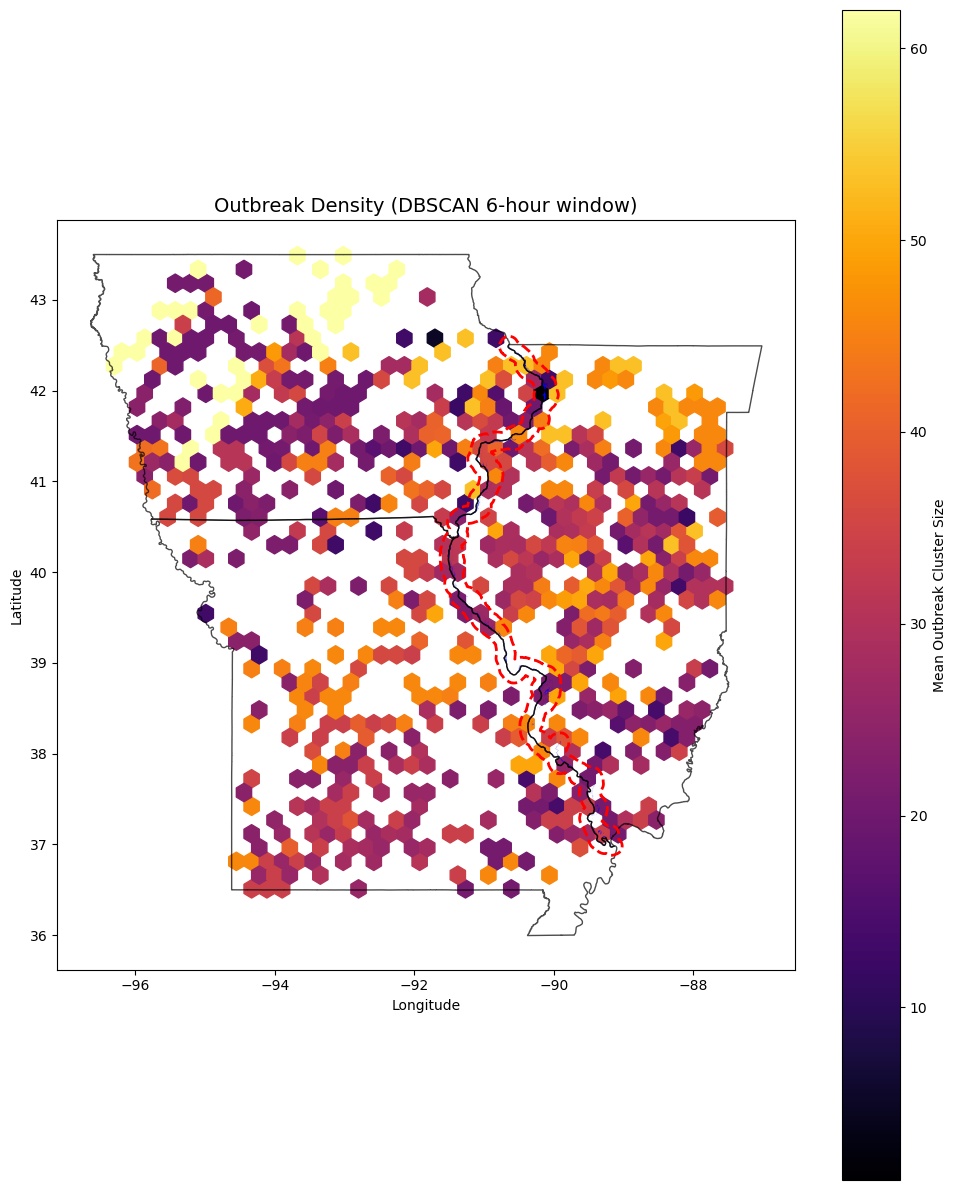


--- Plotting 12-hour window ---


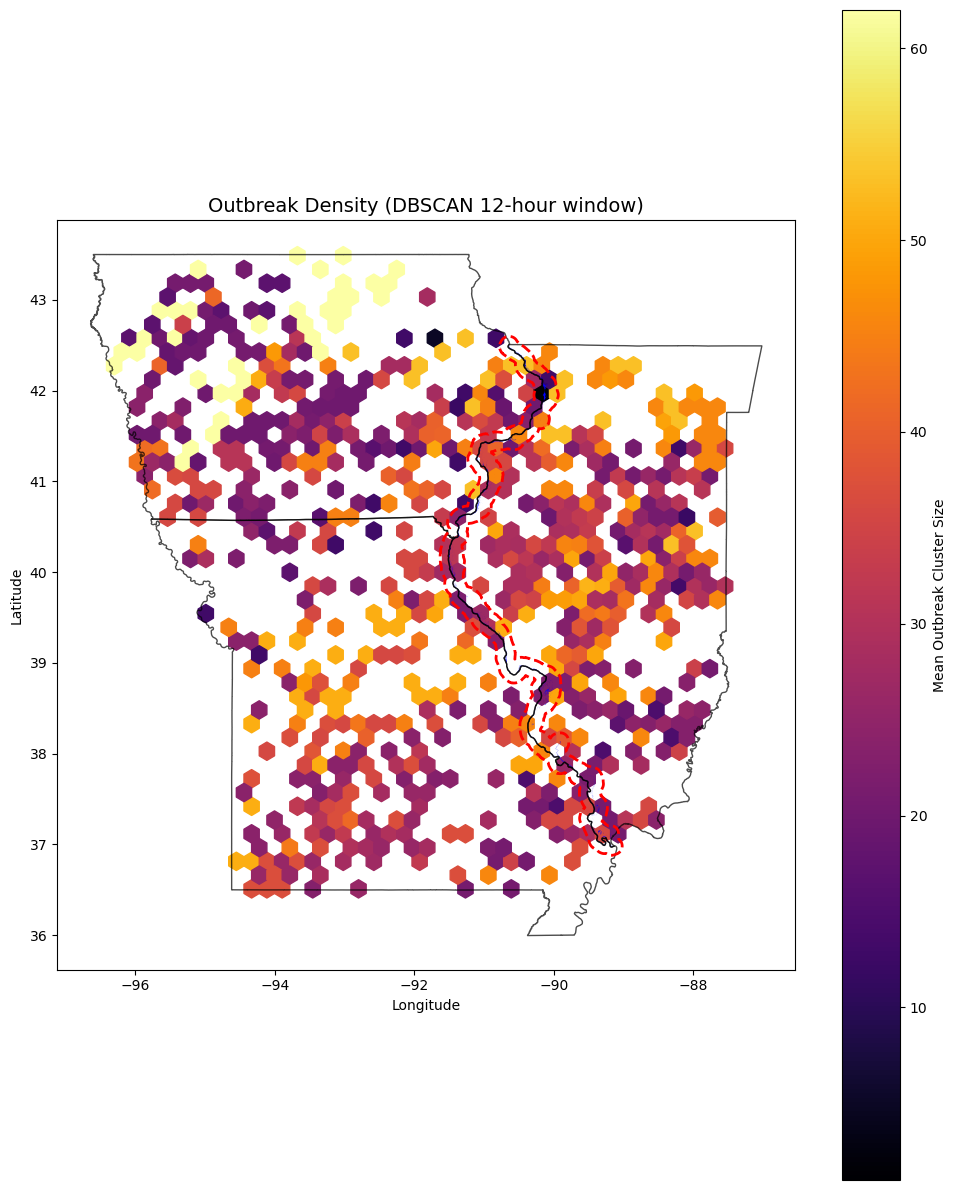


--- Plotting 24-hour window ---


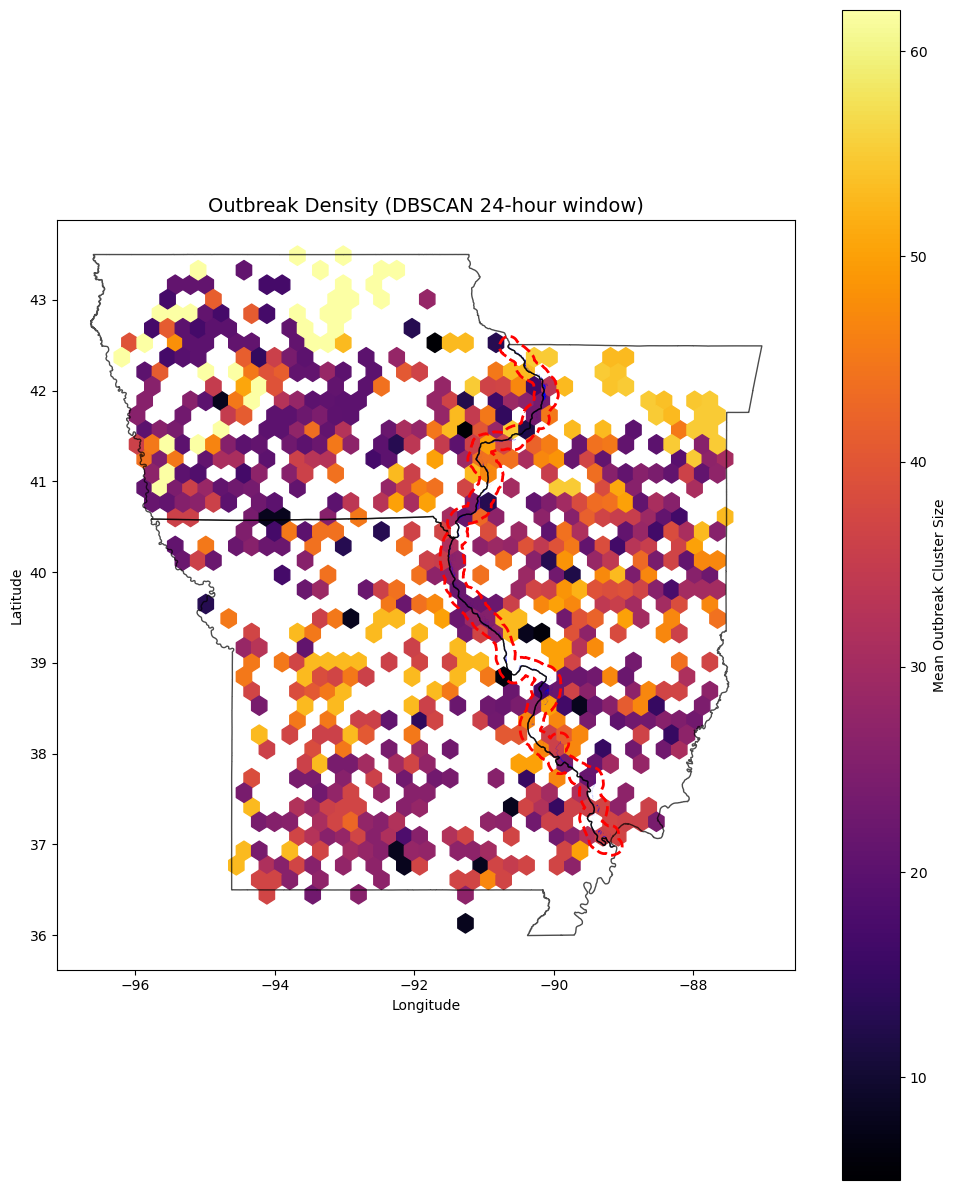

In [9]:
# ================================================================
# Cell: Outbreak Heatmaps (Hexbin - FIXED)
# ================================================================

import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

def plot_outbreak_heatmap(hours):

    cluster_col = f"cluster_{hours}h"
    outbreak_col = f"outbreak_{hours}h"

    # ------------------------------------------------
    # FIX: use tornado_gdf instead of df
    # ------------------------------------------------
    subset = tornado_gdf[tornado_gdf[outbreak_col] == "Outbreak"].copy()

    if len(subset) == 0:
        print(f"No outbreak tornadoes for {hours}h window")
        return

    # ------------------------------------------------
    # Convert to GeoDataFrame
    # ------------------------------------------------
    gdf_plot = gpd.GeoDataFrame(
        subset,
        geometry=gpd.points_from_xy(subset["slon"], subset["slat"]),
        crs="EPSG:4326"
    )

    # Extract coordinates
    gdf_plot["x"] = gdf_plot.geometry.x
    gdf_plot["y"] = gdf_plot.geometry.y

    # ------------------------------------------------
    # Weight by cluster size
    # ------------------------------------------------
    cluster_sizes = subset.groupby(cluster_col).size()
    gdf_plot["weight"] = subset[cluster_col].map(cluster_sizes)

    # Clean
    gdf_plot = gdf_plot.replace([np.inf, -np.inf], np.nan)
    gdf_plot = gdf_plot.dropna(subset=["x", "y", "weight"])

    if len(gdf_plot) == 0:
        print(f"No valid data after cleaning for {hours}h")
        return

# ------------------------------------------------
# Plot
# ------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 12))

# HEXBIN (lat/lon)
    hb = ax.hexbin(
        gdf_plot["x"],   # longitude
        gdf_plot["y"],   # latitude
        C=gdf_plot["weight"],
        gridsize=40,
        reduce_C_function=np.mean,
        cmap="inferno"
    )

# ------------------------------------------------
# State boundaries (lat/lon)
# ------------------------------------------------
    states_latlon.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1,
        alpha=0.7
    )

# ------------------------------------------------
# River (lat/lon)
# ------------------------------------------------
    river_latlon.plot(
        ax=ax,
        color="blue",
        linewidth=1,
        label="River"
    )

# ------------------------------------------------
# Buffer (lat/lon)
# ------------------------------------------------
    buffer_latlon.boundary.plot(
        ax=ax,
        color="red",
        linewidth=2,
        linestyle="--",
        label="10 km Buffer"
    )

    # Colorbar
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Mean Outbreak Cluster Size")
    
    # ------------------------------------------------
    # Labels (FIXED)
    # ------------------------------------------------
    ax.set_title(f"Outbreak Density (DBSCAN {hours}-hour window)", fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    
    plt.tight_layout()
    plt.show()

# ------------------------------------------------
# Run
# ------------------------------------------------
for h in [6, 12, 24]:
    print(f"\n--- Plotting {h}-hour window ---")
    plot_outbreak_heatmap(h)

In [10]:
#hexbin map shows tornado-weighted density. Where are the largest tornado outbreaks located and where are the smallest tornado outbreaks located (size-wise) between 1950-2024. 

In [11]:
for h in [6, 12, 24]:
    cluster_col = f"cluster_{h}h"
    outbreak_col = f"outbreak_{h}h"

    subset = tornado_gdf[
        (tornado_gdf[outbreak_col] == "Outbreak") &
        (tornado_gdf[cluster_col] != -1)
    ]

    n_events = subset[cluster_col].nunique()

    print(f"{h}h window → outbreak events:", n_events)

6h window → outbreak events: 40
12h window → outbreak events: 42
24h window → outbreak events: 48


In [12]:
# ================================================================
# Cell: Outbreak Event Frequency Maps (Cluster-Based)
# ================================================================

import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

def plot_outbreak_event_map(hours):

    cluster_col = f"cluster_{hours}h"
    outbreak_col = f"outbreak_{hours}h"

    # ------------------------------------------------
    # Keep only outbreak tornadoes
    # ------------------------------------------------
    subset = tornado_gdf[
        (tornado_gdf[outbreak_col] == "Outbreak") &
        (tornado_gdf[cluster_col] != -1)
    ].copy()

    if len(subset) == 0:
        print(f"No outbreak events for {hours}h")
        return

    # ------------------------------------------------
    # Collapse clusters → event centroids
    # ------------------------------------------------
    event_centroids = (
        subset
        .groupby(cluster_col)
        .geometry
        .apply(lambda g: g.unary_union.centroid)
    )

    event_gdf = gpd.GeoDataFrame(
        geometry=event_centroids,
        crs=target_crs
    )

    # Convert to lat/lon for plotting
    event_latlon = event_gdf.to_crs("EPSG:4326")

    event_latlon["lon"] = event_latlon.geometry.x
    event_latlon["lat"] = event_latlon.geometry.y

    # ------------------------------------------------
    # Plot
    # ------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 12))

    # HEXBIN of EVENT frequency (not tornadoes!)
    hb = ax.hexbin(
        event_latlon["lon"],
        event_latlon["lat"],
        gridsize=35,
        cmap="viridis",
        mincnt=1
    )

    # ------------------------------------------------
    # State boundaries
    # ------------------------------------------------
    states_latlon.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1,
        alpha=0.7
    )

    # ------------------------------------------------
    # River + buffer
    # ------------------------------------------------
    river_latlon.plot(ax=ax, color="blue", linewidth=1)
    buffer_latlon.boundary.plot(ax=ax, color="red", linestyle="--", linewidth=2)

    # ------------------------------------------------
    # Colorbar
    # ------------------------------------------------
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Number of Outbreak Events")

    # Labels
    ax.set_title(f"Outbreak Event Frequency ({hours}-hour window)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.tight_layout()
    plt.show()


--- 6-hour event map ---


/tmp/ipykernel_1432/1796556534.py:33: DeprecationWarning:

The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.



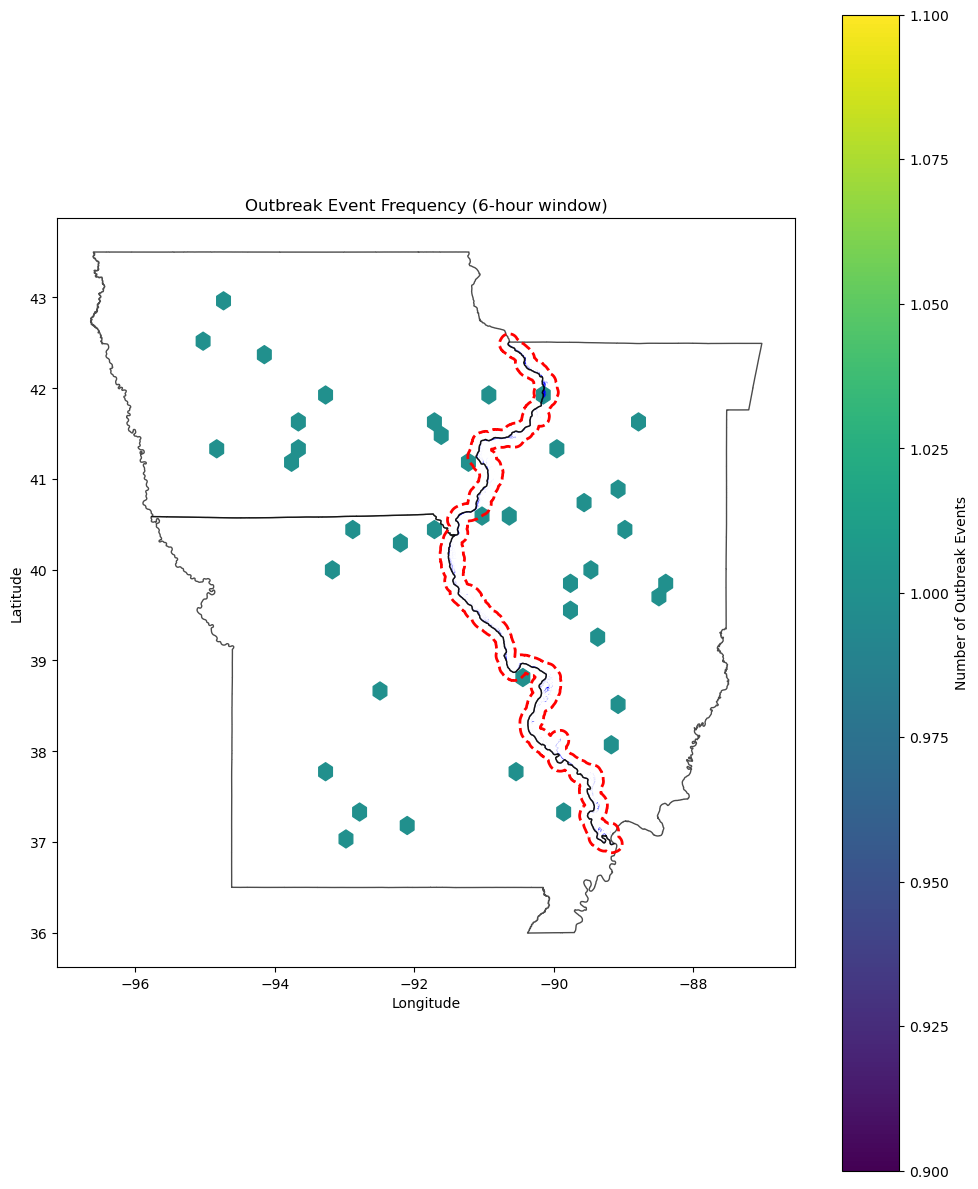


--- 12-hour event map ---


/tmp/ipykernel_1432/1796556534.py:33: DeprecationWarning:

The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.



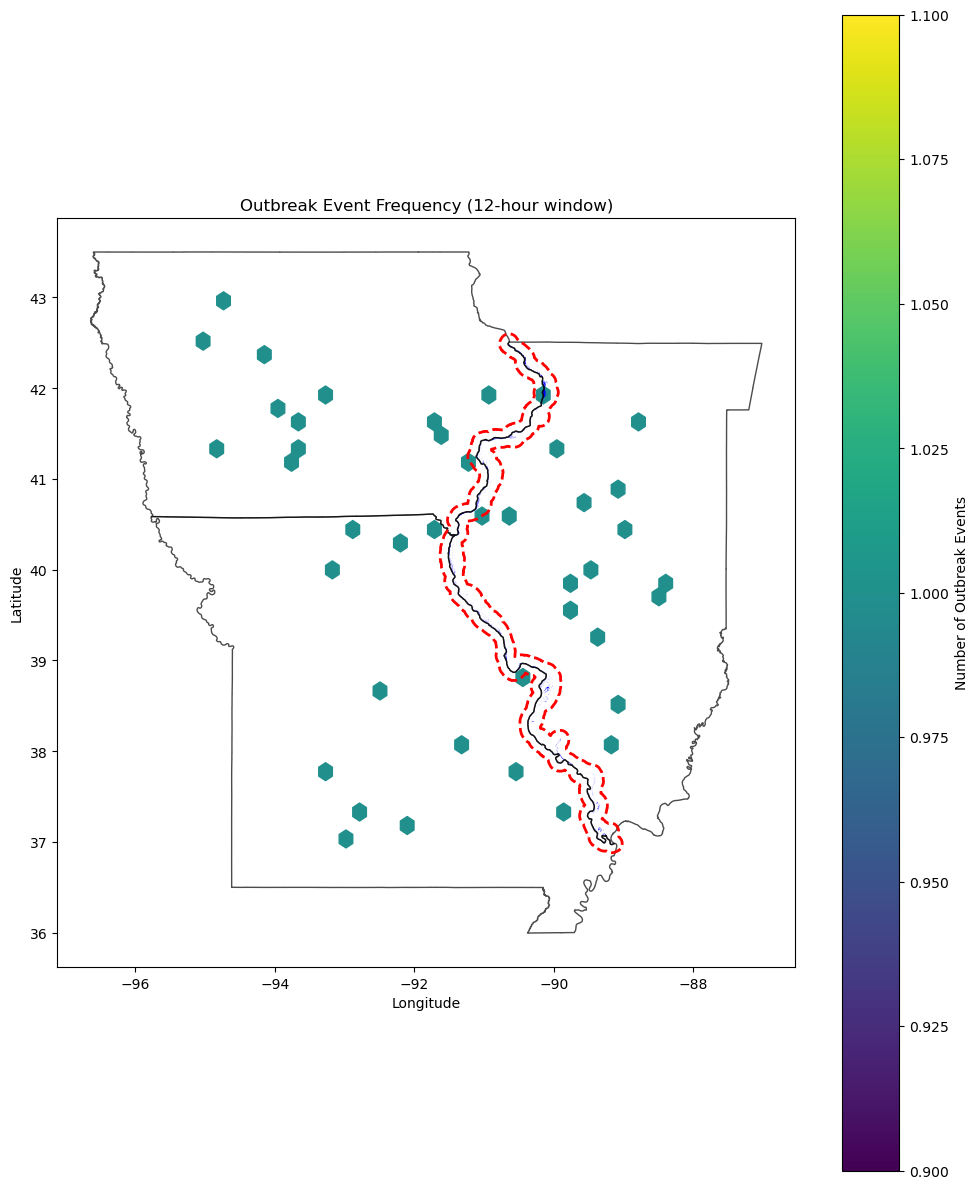


--- 24-hour event map ---


/tmp/ipykernel_1432/1796556534.py:33: DeprecationWarning:

The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.



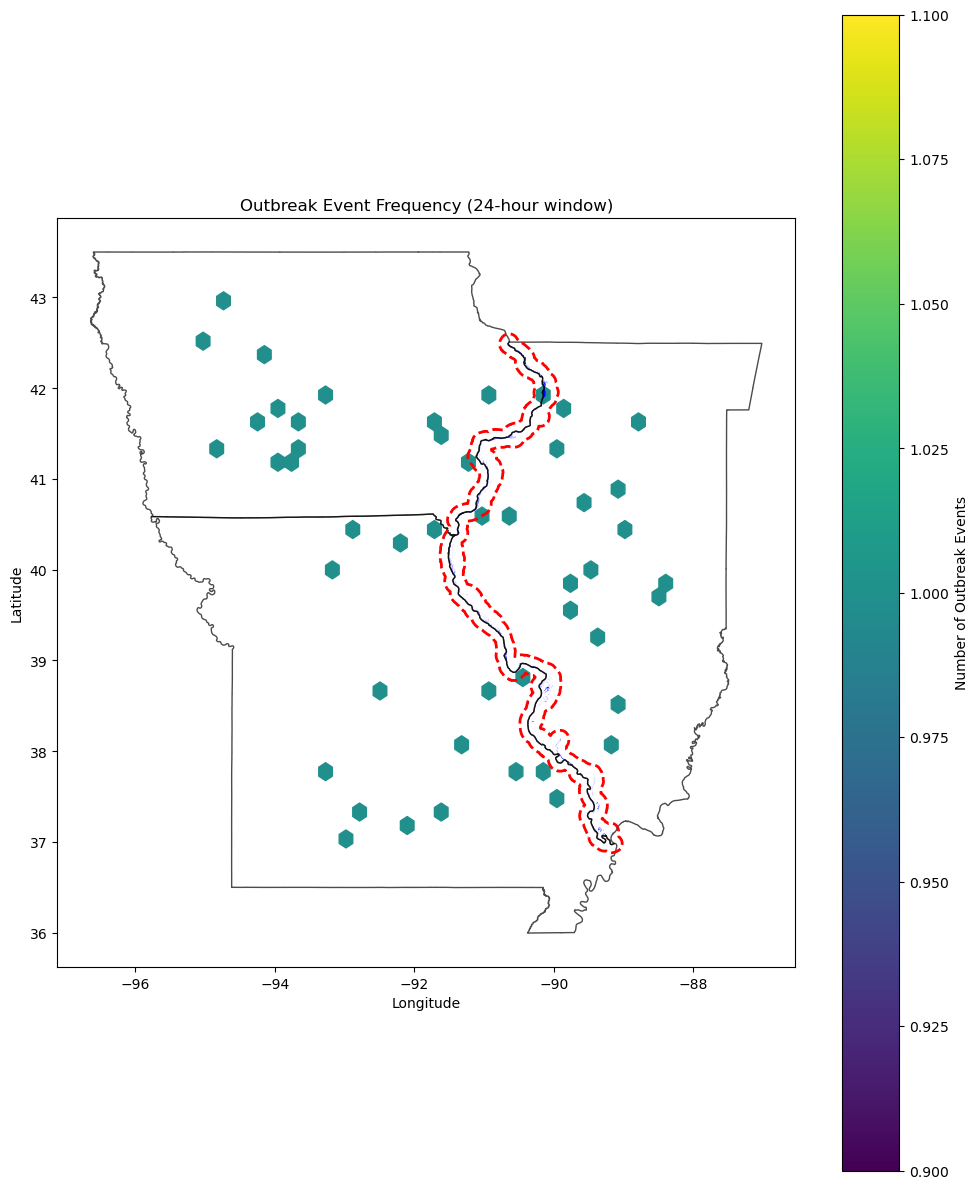

In [13]:
for h in [6, 12, 24]:
    print(f"\n--- {h}-hour event map ---")
    plot_outbreak_event_map(h)

In [14]:
# ================================================================
# Cell: Continuous Outbreak Density Map (KDE)
# ================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

def plot_outbreak_kde(hours):

    cluster_col = f"cluster_{hours}h"
    outbreak_col = f"outbreak_{hours}h"

    # ------------------------------------------------
    # Use outbreak tornadoes (NOT centroids)
    # ------------------------------------------------
    subset = tornado_gdf[tornado_gdf[outbreak_col] == "Outbreak"].copy()

    if len(subset) == 0:
        print(f"No outbreak tornadoes for {hours}h")
        return

    # ------------------------------------------------
    # Convert to lat/lon points
    # ------------------------------------------------
    gdf_plot = gpd.GeoDataFrame(
        subset,
        geometry=gpd.points_from_xy(subset["slon"], subset["slat"]),
        crs="EPSG:4326"
    )

    gdf_plot["lon"] = gdf_plot.geometry.x
    gdf_plot["lat"] = gdf_plot.geometry.y

    # ------------------------------------------------
    # Plot
    # ------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 12))

    # KDE = smooth continuous shading
    sns.kdeplot(
        x=gdf_plot["lon"],
        y=gdf_plot["lat"],
        fill=True,
        cmap="inferno",
        bw_adjust=0.6,   # controls smoothness
        levels=50,       # more levels = smoother gradient
        thresh=0.01,
        ax=ax
    )

    # ------------------------------------------------
    # State boundaries
    # ------------------------------------------------
    states_latlon.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1,
        alpha=0.6
    )

    # ------------------------------------------------
    # River + buffer
    # ------------------------------------------------
    river_latlon.plot(ax=ax, color="blue", linewidth=1)
    buffer_latlon.boundary.plot(ax=ax, color="red", linestyle="--", linewidth=2)

    # Labels
    ax.set_title(f"Continuous Outbreak Density ({hours}-hour window)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.tight_layout()
    plt.show()


--- KDE 6-hour ---


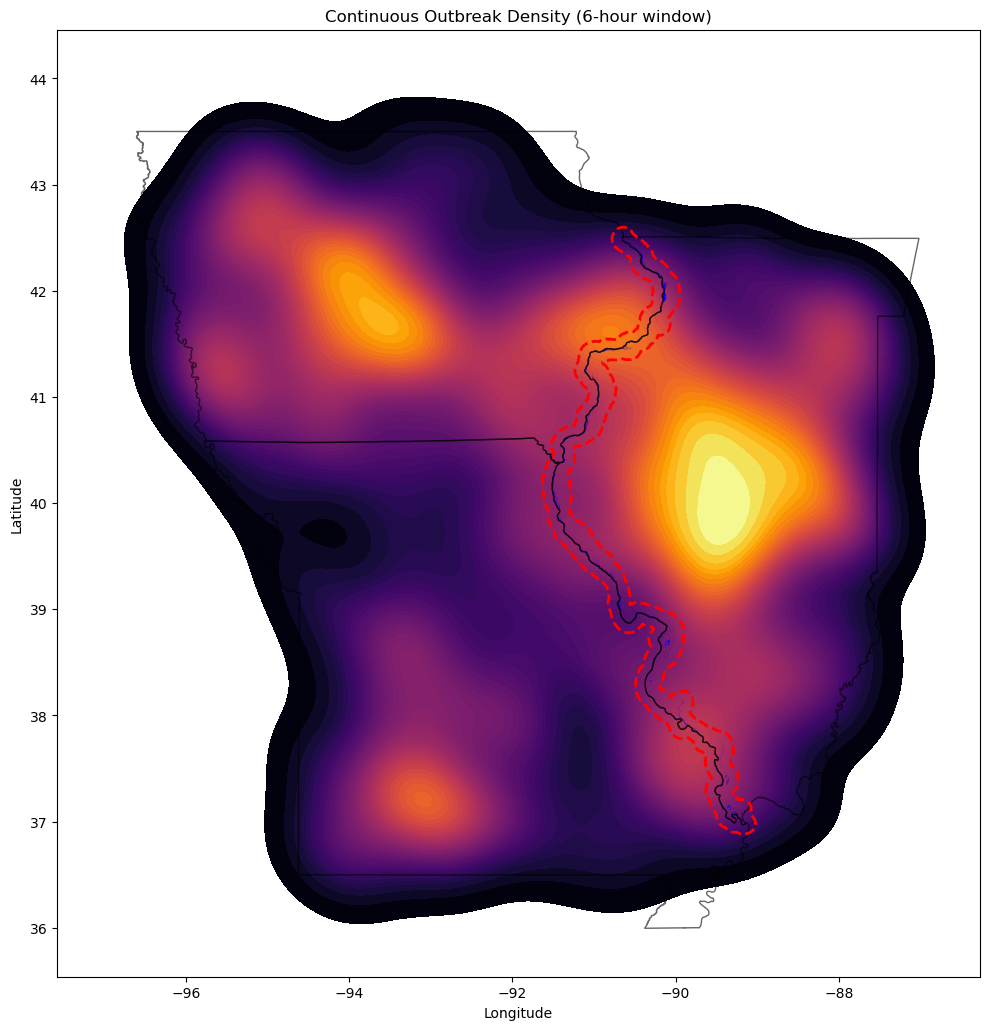


--- KDE 12-hour ---


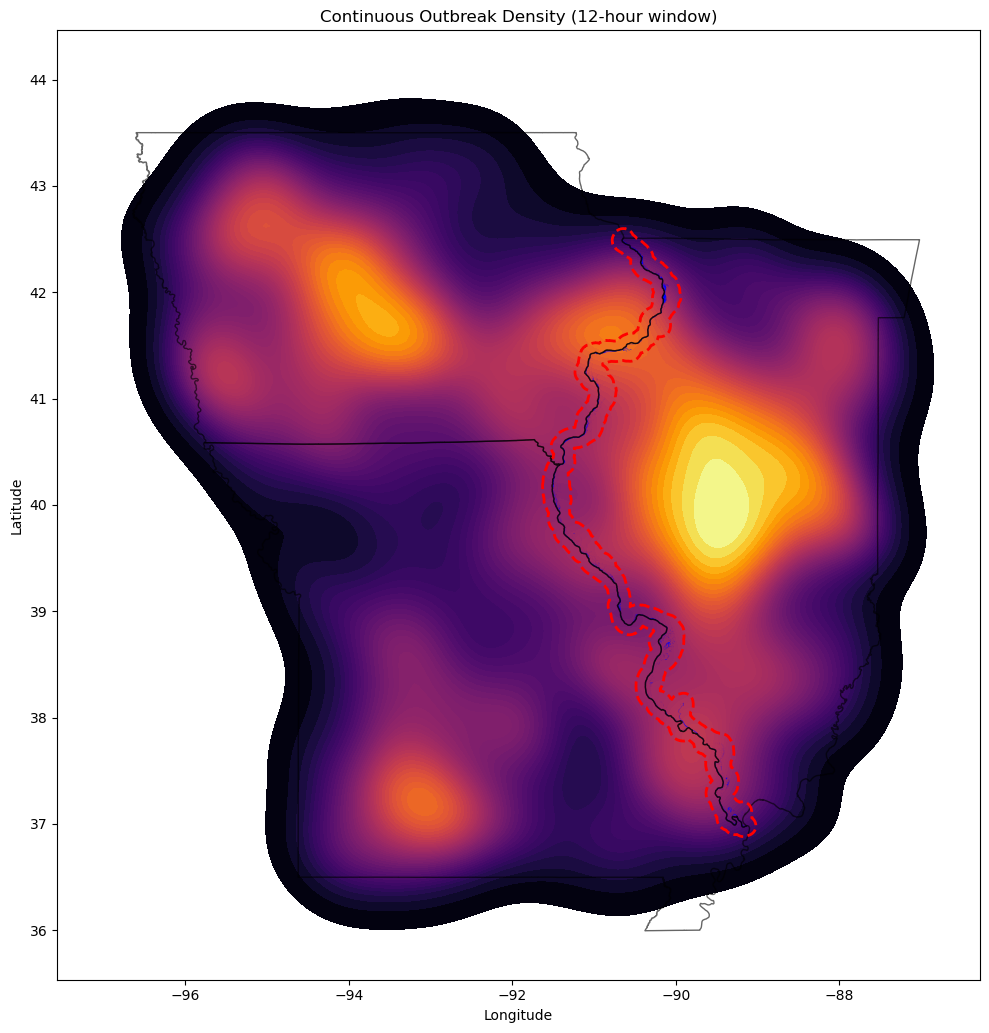


--- KDE 24-hour ---


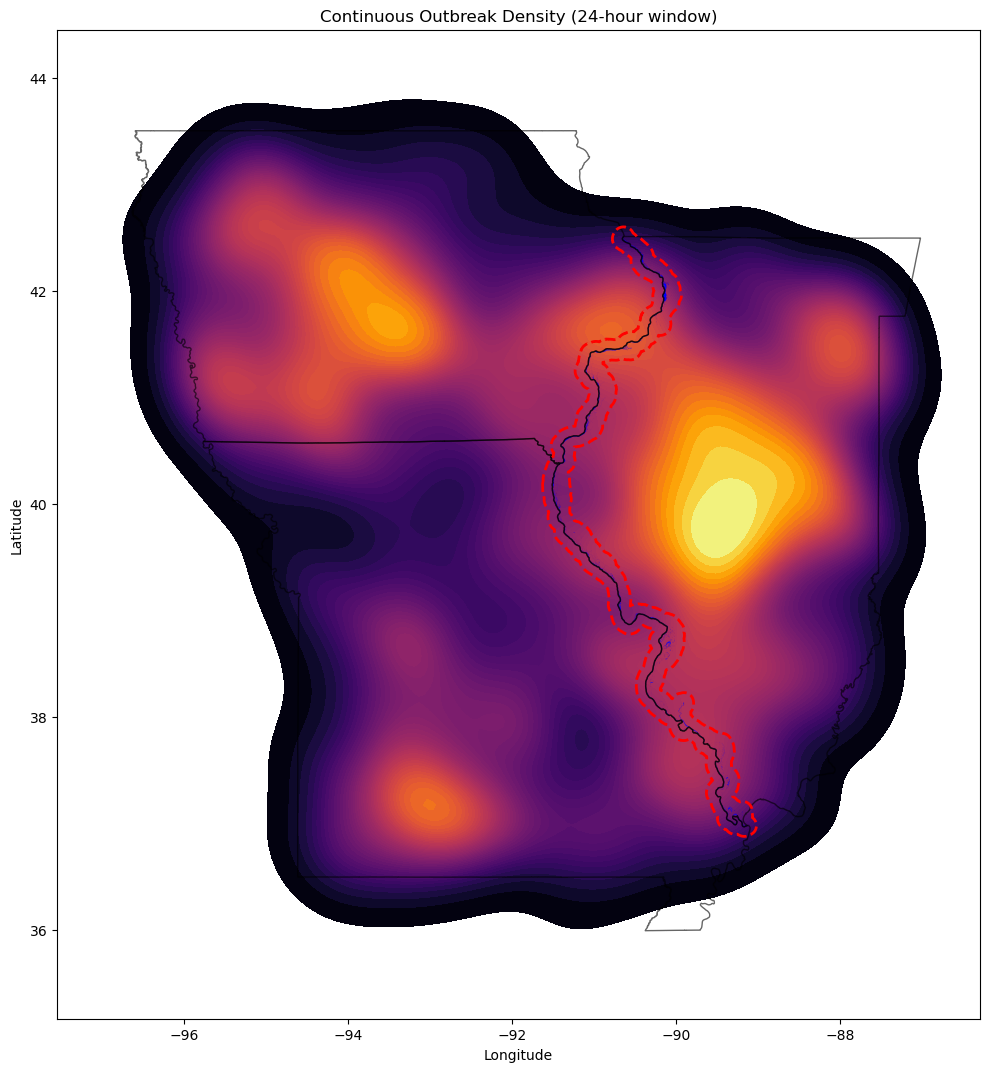

In [15]:
for h in [6, 12, 24]:
    print(f"\n--- KDE {h}-hour ---")
    plot_outbreak_kde(h)

In [16]:
#These maps (above) show where tornado-producing outbreaks concentrate spatially

In [17]:
# ================================================================
# FINAL CELL: Outbreak Density Comparison (CONSISTENT SCALING)
# ================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import numpy as np

def plot_outbreak_time_comparison():

    cluster_col = "cluster_24h"
    outbreak_col = "outbreak_24h"

    # ------------------------------------------------
    # Define periods
    # ------------------------------------------------
    period1 = ("1950-01-01", "1975-12-31")
    period2 = ("1999-01-01", "2024-12-31")

    periods = [
        ("1950–1975", period1),
        ("1999–2024", period2)
    ]

    # ------------------------------------------------
    # Build datasets first (IMPORTANT for consistent scaling)
    # ------------------------------------------------
    datasets = []

    for label, (start, end) in periods:

        subset = tornado_gdf[
            (tornado_gdf[outbreak_col] == "Outbreak") &
            (tornado_gdf["datetime"] >= pd.to_datetime(start, utc=True)) &
            (tornado_gdf["datetime"] <= pd.to_datetime(end, utc=True))
        ].copy()

        gdf_plot = gpd.GeoDataFrame(
            subset,
            geometry=gpd.points_from_xy(subset["slon"], subset["slat"]),
            crs="EPSG:4326"
        )

        gdf_plot["lon"] = gdf_plot.geometry.x
        gdf_plot["lat"] = gdf_plot.geometry.y

        datasets.append((label, gdf_plot))

    # ------------------------------------------------
    # Combine for global density scaling
    # ------------------------------------------------
    all_data = pd.concat([d[1][["lon","lat"]] for d in datasets])

    # ------------------------------------------------
    # Plot
    # ------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharex=True, sharey=True)

    for ax, (label, gdf_plot) in zip(axes, datasets):

        if len(gdf_plot) == 0:
            ax.set_title(f"{label} (No Data)")
            continue

        # ------------------------------------------------
        # KDE with SAME normalization
        # ------------------------------------------------
        sns.kdeplot(
            data=all_data,   # ensures same scaling
            x="lon",
            y="lat",
            fill=False,
            levels=50,
            color="none",
            ax=ax
        )

        sns.kdeplot(
            data=gdf_plot,
            x="lon",
            y="lat",
            fill=True,
            cmap="inferno",
            bw_adjust=0.6,
            levels=50,
            thresh=0.01,
            ax=ax
        )

        # ------------------------------------------------
        # Boundaries
        # ------------------------------------------------
        states_latlon.boundary.plot(ax=ax, color="black", linewidth=1, alpha=0.6)
        river_latlon.plot(ax=ax, color="blue", linewidth=1)
        buffer_latlon.boundary.plot(ax=ax, color="red", linestyle="--", linewidth=2)

        # Titles
        ax.set_title(f"Outbreak Density\n{label}", fontsize=12)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    plt.suptitle(
        "Spatial Distribution of Tornado Outbreaks (24-hour DBSCAN)",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

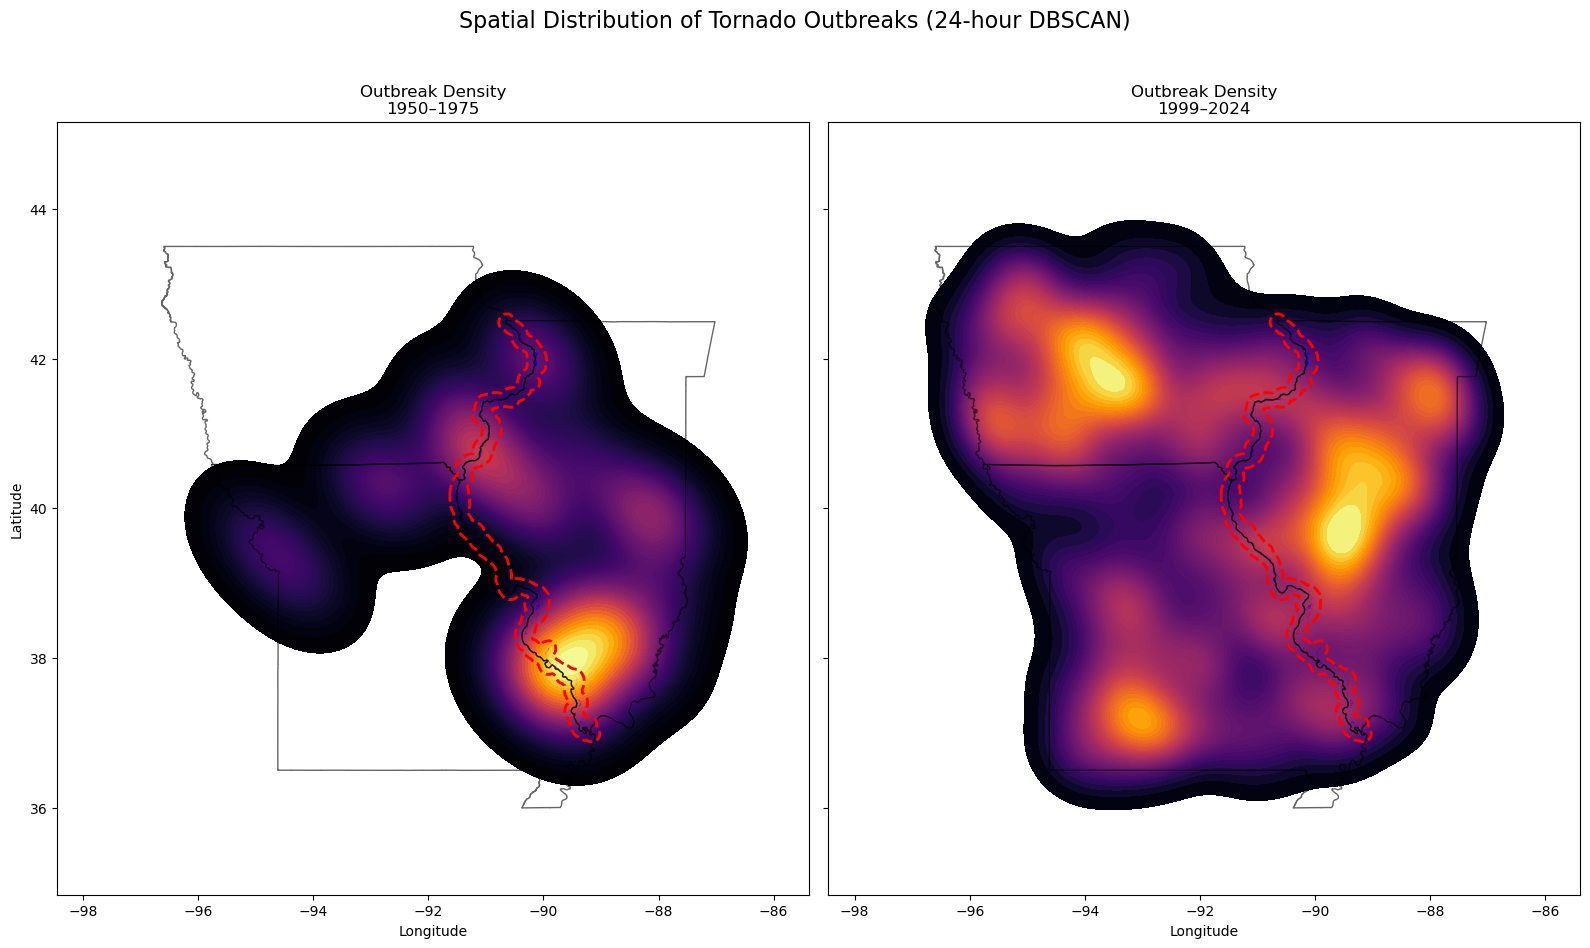

In [18]:
plot_outbreak_time_comparison()

In [19]:
subset_old = tornado_gdf[
    (tornado_gdf["datetime"] >= pd.to_datetime("1999-01-01", utc=True)) &
    (tornado_gdf["datetime"] <= pd.to_datetime("2024-12-31", utc=True))
]

print("Total tornadoes (1999-2024):", len(subset_old))

print("Outbreak tornadoes (24h):")
print(subset_old["outbreak_24h"].value_counts())

Total tornadoes (1999-2024): 4098
Outbreak tornadoes (24h):
outbreak_24h
Individual    3050
Outbreak      1048
Name: count, dtype: int64


In [20]:
# ================================================================
# List outbreak events (24-hour DBSCAN)
# ================================================================

cluster_col = "cluster_24h"
outbreak_col = "outbreak_24h"

# ------------------------------------------------
# Keep only outbreak clusters (exclude noise)
# ------------------------------------------------
subset = tornado_gdf[
    (tornado_gdf[outbreak_col] == "Outbreak") &
    (tornado_gdf[cluster_col] != -1)
].copy()

# ------------------------------------------------
# Group by cluster (event)
# ------------------------------------------------
events = subset.groupby(cluster_col).agg(
    start_time=("datetime", "min"),
    end_time=("datetime", "max"),
    n_tornadoes=("datetime", "count")
).reset_index()

# Duration (hours)
events["duration_hours"] = (
    events["end_time"] - events["start_time"]
).dt.total_seconds() / 3600

# Sort chronologically
events = events.sort_values("start_time")

# ------------------------------------------------
# Print results
# ------------------------------------------------
print("\nTotal outbreak events (24h window):", len(events))
print("\nAll events:\n")
print(events.head(50))

print("\nAll event start dates:\n")
print(events["start_time"].dt.strftime("%Y-%m-%d %H:%M:%S").to_list())

#The n_tornadoes count listed below for each outbreak are the tornadoes left after cleaning and filtering. If you look in the CSV file, there will be many more than the count listed below. 


Total outbreak events (24h window): 48

All events:

    cluster_24h                start_time                  end_time  \
0            25 1957-12-18 19:50:00+00:00 1957-12-19 00:40:00+00:00   
1            92 1967-01-24 17:50:00+00:00 1967-01-25 02:40:00+00:00   
2           164 1974-06-20 21:45:00+00:00 1974-06-20 21:45:00+00:00   
3           166 1974-08-11 00:00:00+00:00 1974-08-11 00:00:00+00:00   
4           232 1982-12-02 03:30:00+00:00 1982-12-03 03:10:00+00:00   
5           235 1983-05-01 18:20:00+00:00 1983-05-02 01:10:00+00:00   
6           245 1984-06-07 19:45:00+00:00 1984-06-08 03:00:00+00:00   
7           275 1988-05-08 15:56:00+00:00 1988-05-08 23:00:00+00:00   
8           345 1995-05-09 20:11:00+00:00 1995-05-10 01:00:00+00:00   
9           349 1995-05-27 22:15:00+00:00 1995-05-28 02:19:00+00:00   
10          352 1995-07-27 19:50:00+00:00 1995-07-27 23:51:00+00:00   
11          353 1996-04-19 01:05:00+00:00 1996-04-20 03:03:00+00:00   
12          361 1997-04

1950–1975: 767 tornadoes
1999–2024: 4098 tornadoes


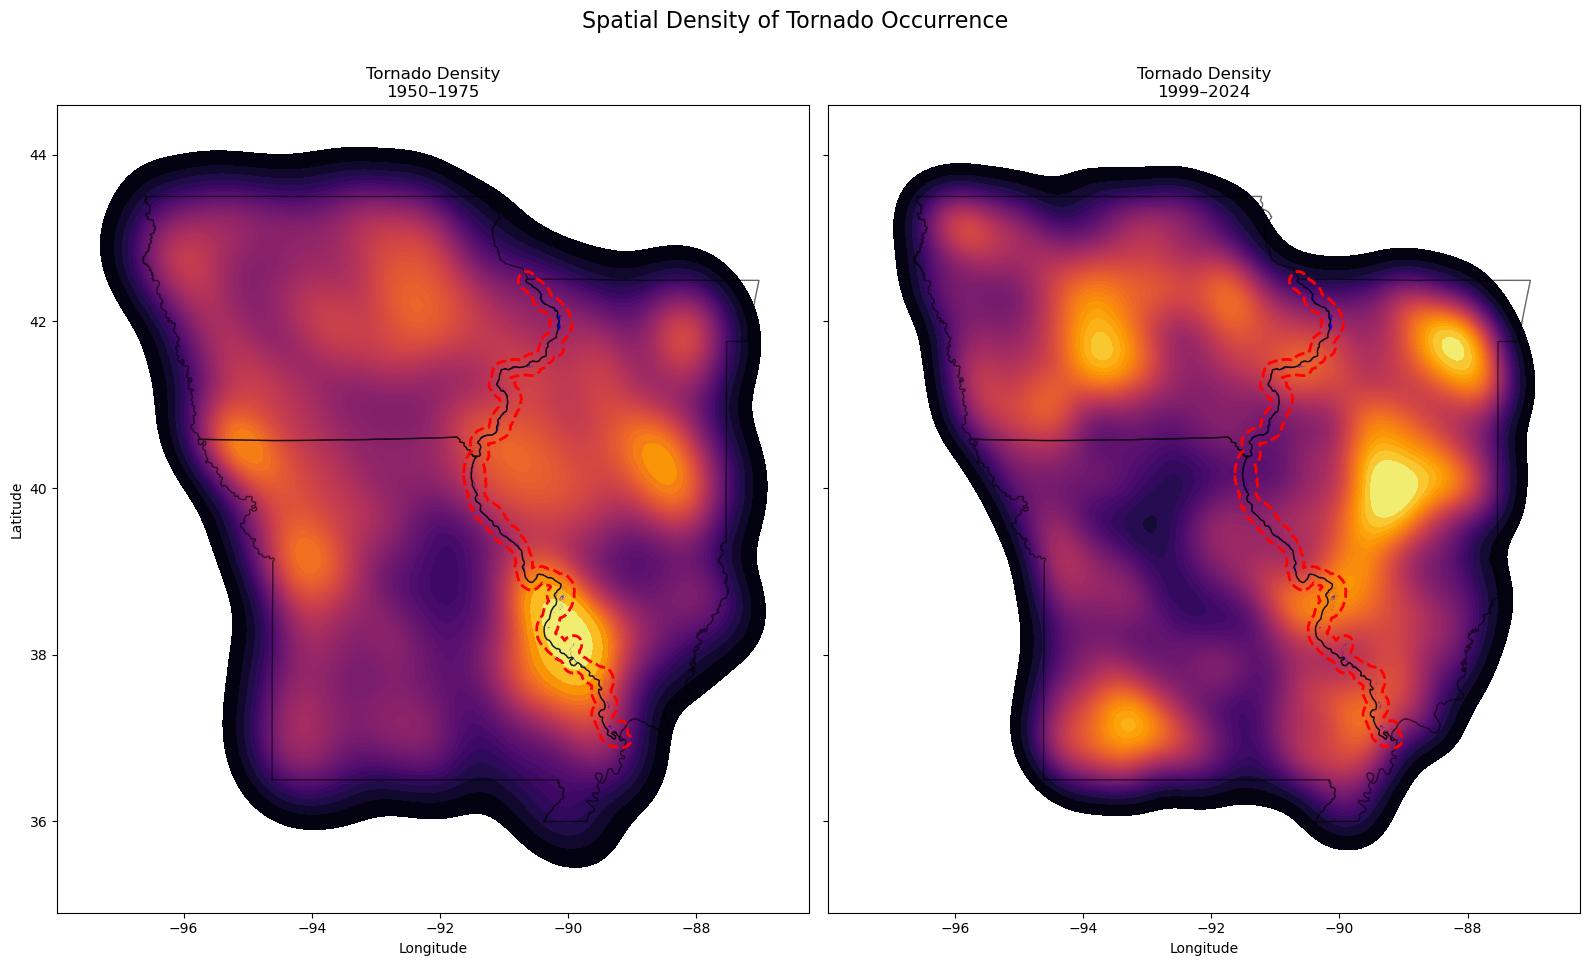

In [21]:
# ================================================================
# Cell: Tornado Frequency Density Comparison (Two Periods)
# ================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import pandas as pd

def plot_tornado_density_comparison():

    # ------------------------------------------------
    # Define periods
    # ------------------------------------------------
    periods = [
        ("1950–1975", "1950-01-01", "1975-12-31"),
        ("1999–2024", "1999-01-01", "2024-12-31")
    ]

    fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharex=True, sharey=True)

    for ax, (label, start, end) in zip(axes, periods):

        # ------------------------------------------------
        # Filter by time ONLY (no outbreak filter)
        # ------------------------------------------------
        subset = tornado_gdf[
            (tornado_gdf["datetime"] >= pd.to_datetime(start, utc=True)) &
            (tornado_gdf["datetime"] <= pd.to_datetime(end, utc=True))
        ].copy()

        print(f"{label}: {len(subset)} tornadoes")

        if len(subset) == 0:
            ax.set_title(f"{label} (No Data)")
            continue

        # ------------------------------------------------
        # Convert to lat/lon points
        # ------------------------------------------------
        gdf_plot = gpd.GeoDataFrame(
            subset,
            geometry=gpd.points_from_xy(subset["slon"], subset["slat"]),
            crs="EPSG:4326"
        )

        gdf_plot["lon"] = gdf_plot.geometry.x
        gdf_plot["lat"] = gdf_plot.geometry.y

        # ------------------------------------------------
        # KDE (continuous shading)
        # ------------------------------------------------
        sns.kdeplot(
            x=gdf_plot["lon"],
            y=gdf_plot["lat"],
            fill=True,
            cmap="inferno",
            bw_adjust=0.6,   # smoothness
            levels=60,       # more levels = smoother gradient
            thresh=0.01,
            ax=ax
        )

        # ------------------------------------------------
        # Add map features
        # ------------------------------------------------
        states_latlon.boundary.plot(ax=ax, color="black", linewidth=1, alpha=0.6)
        river_latlon.plot(ax=ax, color="blue", linewidth=1)
        buffer_latlon.boundary.plot(ax=ax, color="red", linestyle="--", linewidth=2)

        # ------------------------------------------------
        # Labels
        # ------------------------------------------------
        ax.set_title(f"Tornado Density\n{label}", fontsize=12)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    plt.suptitle("Spatial Density of Tornado Occurrence", fontsize=16)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------
# Run
# ------------------------------------------------
plot_tornado_density_comparison()

1950–1975: 767 tornadoes
1999–2024: 4098 tornadoes


/tmp/ipykernel_1432/99533268.py:113: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



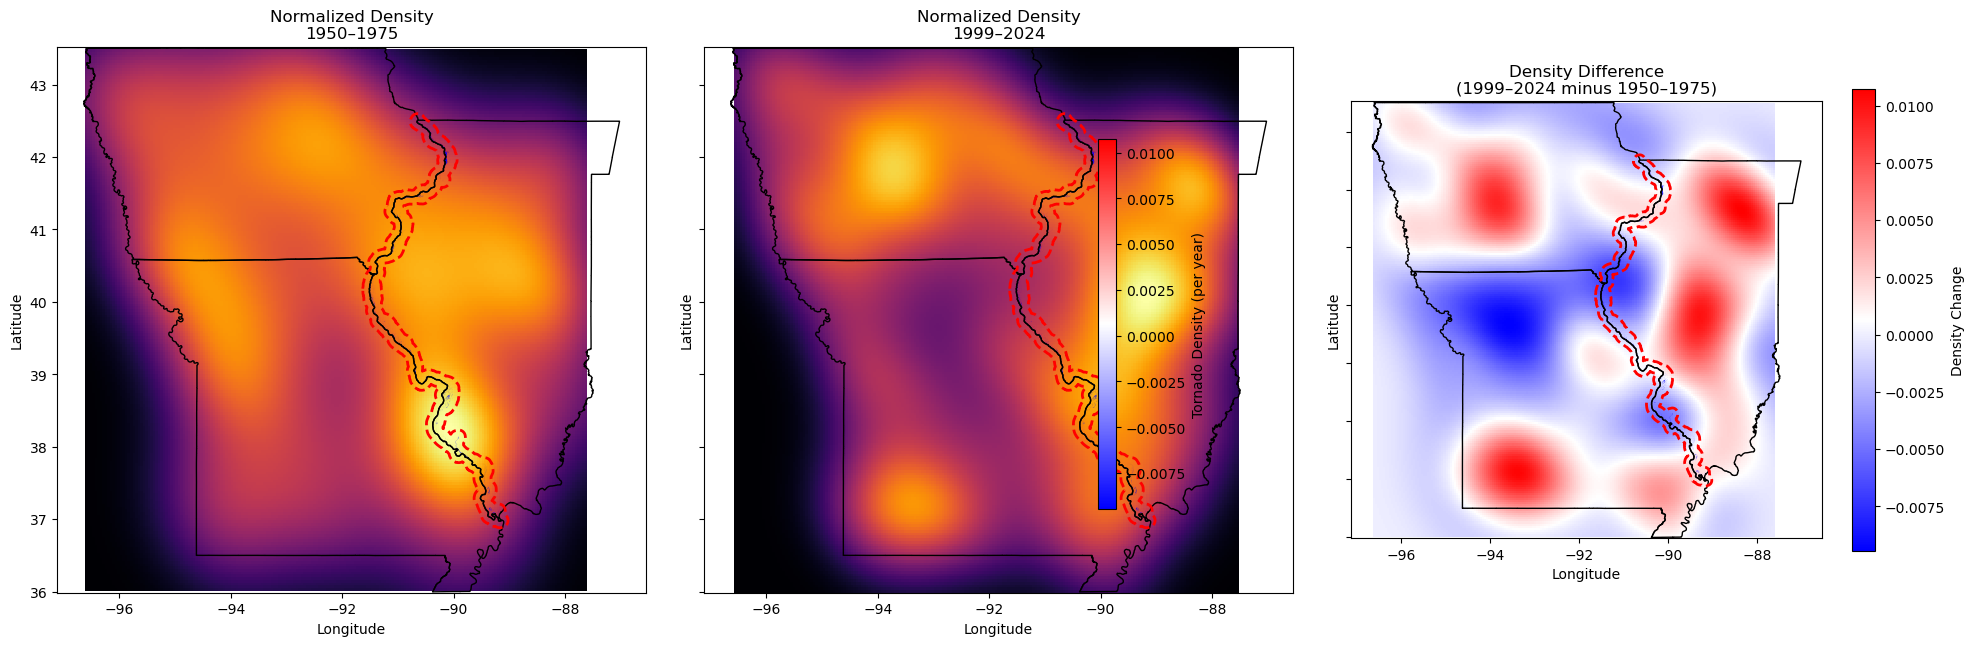

In [22]:
# ================================================================
# Cell: NORMALIZED Density + DIFFERENCE Map
# ================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde

def compute_density_grid(gdf_plot, xmin, xmax, ymin, ymax):

    xy = np.vstack([gdf_plot["lon"], gdf_plot["lat"]])

    kde = gaussian_kde(
        xy,
        weights=gdf_plot["weight"]
    )

    xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
    grid_coords = np.vstack([xx.ravel(), yy.ravel()])

    zz = kde(grid_coords).reshape(xx.shape)

    return xx, yy, zz


def plot_normalized_and_difference():

    periods = [
        ("1950–1975", "1950-01-01", "1975-12-31", 26),
        ("1999–2024", "1999-01-01", "2024-12-31", 26)
    ]

    density_grids = []

    # ------------------------------------------------
    # Build grids
    # ------------------------------------------------
    for label, start, end, nyears in periods:

        subset = tornado_gdf[
            (tornado_gdf["datetime"] >= pd.to_datetime(start, utc=True)) &
            (tornado_gdf["datetime"] <= pd.to_datetime(end, utc=True))
        ].copy()

        print(f"{label}: {len(subset)} tornadoes")

        gdf_plot = gpd.GeoDataFrame(
            subset,
            geometry=gpd.points_from_xy(subset["slon"], subset["slat"]),
            crs="EPSG:4326"
        )

        gdf_plot["lon"] = gdf_plot.geometry.x
        gdf_plot["lat"] = gdf_plot.geometry.y

        # Normalize by years
        gdf_plot["weight"] = 1 / nyears

        xmin, ymin, xmax, ymax = gdf_plot.total_bounds

        xx, yy, zz = compute_density_grid(gdf_plot, xmin, xmax, ymin, ymax)

        density_grids.append((label, xx, yy, zz))

    # ------------------------------------------------
    # Plot
    # ------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharex=True, sharey=True)

    # --- Individual maps ---
    for ax, (label, xx, yy, zz) in zip(axes[:2], density_grids):

        pcm = ax.pcolormesh(
            xx, yy, zz,
            shading="auto",
            cmap="inferno"
        )

        states_latlon.boundary.plot(ax=ax, color="black", linewidth=1)
        river_latlon.plot(ax=ax, color="blue", linewidth=1)
        buffer_latlon.boundary.plot(ax=ax, color="red", linestyle="--", linewidth=2)

        ax.set_title(f"Normalized Density\n{label}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    # --- Difference map ---
    zz_diff = density_grids[1][3] - density_grids[0][3]

    pcm = axes[2].pcolormesh(
        density_grids[0][1],
        density_grids[0][2],
        zz_diff,
        shading="auto",
        cmap="bwr"   # blue = decrease, red = increase
    )

    states_latlon.boundary.plot(ax=axes[2], color="black", linewidth=1)
    river_latlon.plot(ax=axes[2], color="blue", linewidth=1)
    buffer_latlon.boundary.plot(ax=axes[2], color="red", linestyle="--", linewidth=2)

    axes[2].set_title("Density Difference\n(1999–2024 minus 1950–1975)")
    axes[2].set_xlabel("Longitude")
    axes[2].set_ylabel("Latitude")

    # Colorbars
    fig.colorbar(pcm, ax=axes[:2], shrink=0.6, label="Tornado Density (per year)")
    fig.colorbar(pcm, ax=axes[2], shrink=0.6, label="Density Change")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------
# Run
# ------------------------------------------------
plot_normalized_and_difference()

In [23]:
# ================================================================
# EF-scale distribution for ALL river/buffer interactions
# ================================================================

# All tornadoes that intersect buffer OR river
river_zone = tornado_gdf[
    tornado_gdf.intersects(river_buffer) |
    tornado_gdf.intersects(river_il_geom)
].copy()

print("\nTotal tornadoes in river/buffer zone:", len(river_zone))

print("\nEF-scale distribution (river + buffer):")
print(
    river_zone["mag"]
    .value_counts()
    .sort_index()
)


Total tornadoes in river/buffer zone: 372

EF-scale distribution (river + buffer):
mag
0    124
1    122
2     79
3     37
4     10
Name: count, dtype: int64


In [24]:
# ================================================================
# Tornado Interaction Classification + EF-scale breakdown
# ================================================================

from shapely.ops import nearest_points

# ------------------------------------------------
# 1. Use ALL tornadoes (not just weak)
# ------------------------------------------------
all_tornadoes = tornado_gdf.copy()

# ------------------------------------------------
# 2. Crossing tornadoes (touch river itself)
# ------------------------------------------------
crossing_tornadoes = all_tornadoes[
    all_tornadoes.intersects(river_il_geom)
].copy()

# ------------------------------------------------
# 3. Buffer-only tornadoes (NOT crossing river)
# ------------------------------------------------
buffer_only = all_tornadoes[
    all_tornadoes.intersects(river_buffer) &
    (~all_tornadoes.intersects(river_il_geom))
].copy()

# ------------------------------------------------
# 4. Robust west/east classification
# (based on nearest point on river)
# ------------------------------------------------
def assign_side(row):
    centroid = row.geometry.representative_point()
    nearest = nearest_points(centroid, river_il_geom)[1]
    dx = centroid.x - nearest.x
    return "West" if dx < 0 else "East"

buffer_only["side"] = buffer_only.apply(assign_side, axis=1)

west_side = buffer_only[buffer_only["side"] == "West"]
east_side = buffer_only[buffer_only["side"] == "East"]

# ------------------------------------------------
# 5. Print summary counts
# ------------------------------------------------
print("\n--- Tornado Interaction Summary ---")
print(f"Total tornadoes: {len(all_tornadoes)}")
print(f"  • West-side:  {len(west_side)}")
print(f"  • East-side:  {len(east_side)}")
print(f"  • Crossing:   {len(crossing_tornadoes)}")
print(f"  • Sum check:  {len(west_side) + len(east_side) + len(crossing_tornadoes)}")

# ------------------------------------------------
# 6. EF-scale breakdowns
# ------------------------------------------------

def print_ef_counts(label, df):
    print(f"\n{label} EF-scale counts:")
    print(df["mag"].value_counts().sort_index())

print_ef_counts("West-side", west_side)
print_ef_counts("East-side", east_side)
print_ef_counts("Crossing", crossing_tornadoes)



--- Tornado Interaction Summary ---
Total tornadoes: 5793
  • West-side:  142
  • East-side:  141
  • Crossing:   89
  • Sum check:  372

West-side EF-scale counts:
mag
0    51
1    47
2    29
3    14
4     1
Name: count, dtype: int64

East-side EF-scale counts:
mag
0    56
1    48
2    27
3     8
4     2
Name: count, dtype: int64

Crossing EF-scale counts:
mag
0    17
1    27
2    23
3    15
4     7
Name: count, dtype: int64


In [25]:
# # ================================================================
# # Recreate buffer_only, crossing_tornadoes, etc.
# # ================================================================

# # 1. Use ALL tornadoes
# all_tornadoes = tornado_gdf.copy()

# # 2. Crossing tornadoes (touch river)
# crossing_tornadoes = all_tornadoes[
#     all_tornadoes.intersects(river_il_geom)
# ].copy()

# # 3. Buffer-only tornadoes (NOT crossing river)
# buffer_only = all_tornadoes[
#     all_tornadoes.intersects(river_buffer) &
#     (~all_tornadoes.intersects(river_il_geom))
# ].copy()

# print("Buffer-only tornadoes:", len(buffer_only))
# print("Crossing tornadoes:", len(crossing_tornadoes))
# print("Total in buffer zone:", len(buffer_only) + len(crossing_tornadoes))

# # ------------------------------------------------
# # WEST / EAST (MATCH ORIGINAL METHOD)
# # ------------------------------------------------
# buffer_only["centroid"] = buffer_only.geometry.centroid

# river_center_x = river_il_geom.centroid.x

# west_side = buffer_only[buffer_only["centroid"].x < river_center_x]
# east_side = buffer_only[buffer_only["centroid"].x >= river_center_x]

# # ------------------------------------------------
# # PRINT
# # ------------------------------------------------
# print("\n--- Tornado Interaction Summary ---")
# print(f"Total tornadoes: {len(all_tornadoes)}")
# print(f"  • West-side:  {len(west_side)}")
# print(f"  • East-side:  {len(east_side)}")
# print(f"  • Crossing:   {len(crossing_tornadoes)}")
# print(f"  • Sum check:  {len(west_side) + len(east_side) + len(crossing_tornadoes)}")

# # ------------------------------------------------
# # 6. EF-scale breakdowns
# # ------------------------------------------------

# def print_ef_counts(label, df):
#     print(f"\n{label} EF-scale counts:")
#     print(df["mag"].value_counts().sort_index())

# print_ef_counts("West-side", west_side)
# print_ef_counts("East-side", east_side)
# print_ef_counts("Crossing", crossing_tornadoes)

In [26]:
# # ================================================================
# # Cell: Path Length Boxplot (Styled) + 5-number summary
# # ================================================================

# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np
# from matplotlib.patches import Patch

# # ------------------------------------------------
# # 1. Prepare data
# # ------------------------------------------------

# def prepare_group(df, label):
#     out = df.copy()
#     out["side_type"] = label
#     out["path_km"] = out["len"] * 1.60934  # miles → km
#     return out[["side_type", "path_km"]]

# west_df  = prepare_group(west_side, "West Side")
# east_df  = prepare_group(east_side, "East Side")
# cross_df = prepare_group(crossing_tornadoes, "Crossed River")

# plot_df = pd.concat([west_df, east_df, cross_df], ignore_index=True)

# # Clean
# plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
# plot_df = plot_df.dropna(subset=["path_km"])

# # Ensure consistent order
# order = ["West Side", "East Side", "Crossed River"]

# # ------------------------------------------------
# # 2. Boxplot (MATCHES YOUR STYLE)
# # ------------------------------------------------

# plt.figure(figsize=(9,6))
# palette = sns.color_palette("Set2", 3)

# ax = sns.boxplot(
#     data=plot_df,
#     x="side_type",
#     y="path_km",
#     order=order,
#     palette=palette,
#     showfliers=False
# )

# # Counts for legend
# counts = plot_df["side_type"].value_counts()

# legend_elements = [
#     Patch(facecolor=palette[i], edgecolor='black',
#           label=f"{cat} (n={counts[cat]})")
#     for i, cat in enumerate(order)
# ]

# ax.legend(handles=legend_elements, loc='upper left', title="Group")

# ax.set_title("Tornado Path Length (km) by River Interaction", fontsize=14)
# ax.set_xlabel("Group")
# ax.set_ylabel("Path Length (km)")
# ax.grid(axis='y', linestyle='--', alpha=0.4)

# sns.despine()
# plt.tight_layout()
# plt.show()

# # ------------------------------------------------
# # 3. 5-number summary (clean + readable)
# # ------------------------------------------------

# def five_number(series):
#     return [
#         np.min(series),
#         np.percentile(series, 25),
#         np.median(series),
#         np.percentile(series, 75),
#         np.max(series)
#     ]

# summary_df = []

# for group in order:
#     values = plot_df[plot_df["side_type"] == group]["path_km"]
#     stats = five_number(values)

#     summary_df.append([
#         group,
#         round(stats[0], 2),
#         round(stats[1], 2),
#         round(stats[2], 2),
#         round(stats[3], 2),
#         round(stats[4], 2)
#     ])

# summary_df = pd.DataFrame(
#     summary_df,
#     columns=["Group", "Min", "Q1", "Median", "Q3", "Max"]
# )

# print("\n--- 5-Number Summary (Path Length in km) ---")
# display(summary_df)

In [27]:
# from scipy.stats import kruskal
# import itertools
# import pandas as pd

# # ------------------------------------------------
# # 1. Kruskal-Wallis Test (overall)
# # ------------------------------------------------

# groups = [
#     plot_df[plot_df["side_type"] == "West Side"]["path_km"],
#     plot_df[plot_df["side_type"] == "East Side"]["path_km"],
#     plot_df[plot_df["side_type"] == "Crossed River"]["path_km"]
# ]

# H, p = kruskal(*groups)

# print("\nKruskal-Wallis Test")
# print("-------------------")
# print(f"H = {H:.3f}")
# print(f"p-value = {p:.6f}")

# # ------------------------------------------------
# # 2. Pairwise comparisons (Bonferroni corrected)
# # ------------------------------------------------

# group_names = ["West Side", "East Side", "Crossed River"]
# pairs = list(itertools.combinations(group_names, 2))

# results = []

# for g1, g2 in pairs:

#     data1 = plot_df[plot_df["side_type"] == g1]["path_km"]
#     data2 = plot_df[plot_df["side_type"] == g2]["path_km"]

#     H_pair, p_pair = kruskal(data1, data2)

#     results.append({
#         "Group1": g1,
#         "Group2": g2,
#         "H": round(H_pair, 3),
#         "p-value": p_pair
#     })

# results_df = pd.DataFrame(results)

# # Bonferroni correction
# results_df["Adj p-value (Bonferroni)"] = results_df["p-value"] * len(results_df)
# results_df["Significant?"] = results_df["p-value"] < 0.05
# results_df["Adj Significant?"] = results_df["Adj p-value (Bonferroni)"] < 0.05

# print("\nPairwise Kruskal-Wallis Tests")
# print("--------------------------------")
# display(results_df)

/tmp/ipykernel_586/4273373069.py:42: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




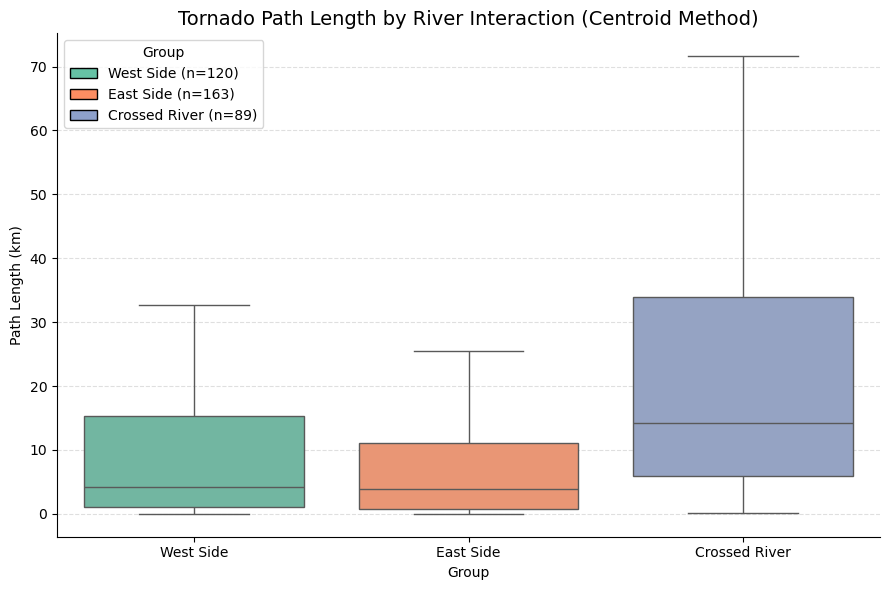


--- 5-Number Summary (Path Length in km) ---


,Group,Min,Q1,Median,Q3,Max
0,West Side,0.00,1.12,4.20,15.37,147.25
1,East Side,0.03,0.80,3.88,11.02,122.15
2,Crossed River,0.16,5.86,14.16,33.96,237.22


In [28]:
# # ================================================================
# # Cell: Path Length Analysis (CENTROID SPLIT METHOD)
# # ================================================================

# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np
# from matplotlib.patches import Patch
# from scipy.stats import kruskal
# import itertools
# import pandas as pd

# # ------------------------------------------------
# # 1. Prepare data
# # ------------------------------------------------

# def prepare_group(df, label):
#     out = df.copy()
#     out["side_type"] = label
#     out["path_km"] = out["len"] * 1.60934  # miles → km
#     return out[["side_type", "path_km"]]

# west_df  = prepare_group(west_side, "West Side")
# east_df  = prepare_group(east_side, "East Side")
# cross_df = prepare_group(crossing_tornadoes, "Crossed River")

# plot_df = pd.concat([west_df, east_df, cross_df], ignore_index=True)

# # Clean
# plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
# plot_df = plot_df.dropna(subset=["path_km"])

# order = ["West Side", "East Side", "Crossed River"]

# # ------------------------------------------------
# # 2. Boxplot
# # ------------------------------------------------

# plt.figure(figsize=(9,6))
# palette = sns.color_palette("Set2", 3)

# ax = sns.boxplot(
#     data=plot_df,
#     x="side_type",
#     y="path_km",
#     order=order,
#     palette=palette,
#     showfliers=False
# )

# counts = plot_df["side_type"].value_counts()

# legend_elements = [
#     Patch(facecolor=palette[i], edgecolor='black',
#           label=f"{cat} (n={counts[cat]})")
#     for i, cat in enumerate(order)
# ]

# ax.legend(handles=legend_elements, loc='upper left', title="Group")

# ax.set_title("Tornado Path Length by River Interaction (Centroid Method)", fontsize=14)
# ax.set_xlabel("Group")
# ax.set_ylabel("Path Length (km)")
# ax.grid(axis='y', linestyle='--', alpha=0.4)

# sns.despine()
# plt.tight_layout()
# plt.show()

# # ------------------------------------------------
# # 5. 5-number summary (clean + readable)
# # ------------------------------------------------

# def five_number(series):
#     return [
#         np.min(series),
#         np.percentile(series, 25),
#         np.median(series),
#         np.percentile(series, 75),
#         np.max(series)
#     ]

# summary_df = []

# for group in order:
#     values = plot_df[plot_df["side_type"] == group]["path_km"]
#     stats = five_number(values)

#     summary_df.append([
#         group,
#         round(stats[0], 2),
#         round(stats[1], 2),
#         round(stats[2], 2),
#         round(stats[3], 2),
#         round(stats[4], 2)
#     ])

# summary_df = pd.DataFrame(
#     summary_df,
#     columns=["Group", "Min", "Q1", "Median", "Q3", "Max"]
# )

# print("\n--- 5-Number Summary (Path Length in km) ---")
# display(summary_df)

In [29]:
# # ------------------------------------------------
# # 3. Kruskal-Wallis Test
# # ------------------------------------------------

# groups = [
#     plot_df[plot_df["side_type"] == "West Side"]["path_km"],
#     plot_df[plot_df["side_type"] == "East Side"]["path_km"],
#     plot_df[plot_df["side_type"] == "Crossed River"]["path_km"]
# ]

# H, p = kruskal(*groups)

# print("\nKruskal-Wallis Test")
# print("-------------------")
# print(f"H = {H:.3f}")
# print(f"p-value = {p:.6f}")

# # ------------------------------------------------
# # 4. Pairwise comparisons (Bonferroni)
# # ------------------------------------------------

# group_names = order
# pairs = list(itertools.combinations(group_names, 2))

# results = []

# for g1, g2 in pairs:

#     data1 = plot_df[plot_df["side_type"] == g1]["path_km"]
#     data2 = plot_df[plot_df["side_type"] == g2]["path_km"]

#     H_pair, p_pair = kruskal(data1, data2)

#     results.append({
#         "Group1": g1,
#         "Group2": g2,
#         "H": round(H_pair, 3),
#         "p-value": p_pair
#     })

# results_df = pd.DataFrame(results)

# # Bonferroni correction
# results_df["Adj p-value (Bonferroni)"] = results_df["p-value"] * len(results_df)
# results_df["Significant?"] = results_df["p-value"] < 0.05
# results_df["Adj Significant?"] = results_df["Adj p-value (Bonferroni)"] < 0.05

# print("\nPairwise Kruskal-Wallis Tests")
# print("--------------------------------")
# display(results_df)


Kruskal-Wallis Test
-------------------
H = 41.970
p-value = 0.000000

Pairwise Kruskal-Wallis Tests
--------------------------------


,Group1,Group2,H,p-value,Adj p-value (Bonferroni),Significant?,Adj Significant?
0,West Side,East Side,0.159,6.898077e-01,2.069423e+00,False,False
1,West Side,Crossed River,27.385,1.667479e-07,5.002438e-07,True,True
2,East Side,Crossed River,38.999,4.239175e-10,1.271752e-09,True,True


/tmp/ipykernel_1432/3298857307.py:42: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




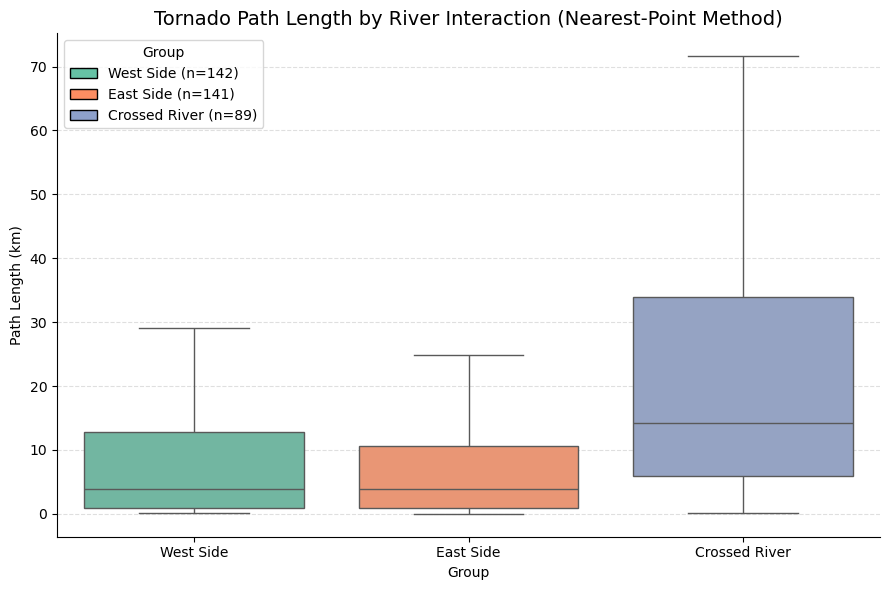


--- 5-Number Summary (Path Length in km) ---


,Group,Min,Q1,Median,Q3,Max
0,West Side,0.06,0.93,3.94,12.87,147.25
1,East Side,0.00,0.84,3.88,10.62,107.83
2,Crossed River,0.16,5.86,14.16,33.96,237.22


In [27]:
# ================================================================
# Cell: Path Length Analysis (NEAREST-POINT METHOD)
# ================================================================

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from scipy.stats import kruskal
import itertools
import pandas as pd

# ------------------------------------------------
# 1. Prepare data (USING NEAREST-POINT CLASSIFICATION)
# ------------------------------------------------

def prepare_group(df, label):
    out = df.copy()
    out["side_type"] = label
    out["path_km"] = out["len"] * 1.60934  # miles → km
    return out[["side_type", "path_km"]]

west_df  = prepare_group(west_side, "West Side")
east_df  = prepare_group(east_side, "East Side")
cross_df = prepare_group(crossing_tornadoes, "Crossed River")

plot_df = pd.concat([west_df, east_df, cross_df], ignore_index=True)

# Clean
plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
plot_df = plot_df.dropna(subset=["path_km"])

order = ["West Side", "East Side", "Crossed River"]

# ------------------------------------------------
# 2. Boxplot
# ------------------------------------------------

plt.figure(figsize=(9,6))
palette = sns.color_palette("Set2", 3)

ax = sns.boxplot(
    data=plot_df,
    x="side_type",
    y="path_km",
    order=order,
    palette=palette,
    showfliers=False
)

counts = plot_df["side_type"].value_counts()

legend_elements = [
    Patch(facecolor=palette[i], edgecolor='black',
          label=f"{cat} (n={counts[cat]})")
    for i, cat in enumerate(order)
]

ax.legend(handles=legend_elements, loc='upper left', title="Group")

ax.set_title("Tornado Path Length by River Interaction (Nearest-Point Method)", fontsize=14)
ax.set_xlabel("Group")
ax.set_ylabel("Path Length (km)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 3. 5-number summary
# ------------------------------------------------

def five_number(series):
    return [
        np.min(series),
        np.percentile(series, 25),
        np.median(series),
        np.percentile(series, 75),
        np.max(series)
    ]

summary_df = []

for group in order:
    values = plot_df[plot_df["side_type"] == group]["path_km"]
    stats = five_number(values)

    summary_df.append([
        group,
        round(stats[0], 2),
        round(stats[1], 2),
        round(stats[2], 2),
        round(stats[3], 2),
        round(stats[4], 2)
    ])

summary_df = pd.DataFrame(
    summary_df,
    columns=["Group", "Min", "Q1", "Median", "Q3", "Max"]
)

print("\n--- 5-Number Summary (Path Length in km) ---")
display(summary_df)


In [28]:
# ------------------------------------------------
# 4. Kruskal-Wallis Test
# ------------------------------------------------

groups = [
    plot_df[plot_df["side_type"] == "West Side"]["path_km"],
    plot_df[plot_df["side_type"] == "East Side"]["path_km"],
    plot_df[plot_df["side_type"] == "Crossed River"]["path_km"]
]

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test")
print("-------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

# ------------------------------------------------
# 5. Pairwise comparisons (Bonferroni)
# ------------------------------------------------

pairs = list(itertools.combinations(order, 2))

results = []

for g1, g2 in pairs:

    data1 = plot_df[plot_df["side_type"] == g1]["path_km"]
    data2 = plot_df[plot_df["side_type"] == g2]["path_km"]

    H_pair, p_pair = kruskal(data1, data2)

    results.append({
        "Group1": g1,
        "Group2": g2,
        "H": round(H_pair, 3),
        "p-value": p_pair
    })

results_df = pd.DataFrame(results)

# Bonferroni correction
results_df["Adj p-value (Bonferroni)"] = results_df["p-value"] * len(results_df)
results_df["Significant?"] = results_df["p-value"] < 0.05
results_df["Adj Significant?"] = results_df["Adj p-value (Bonferroni)"] < 0.05

print("\nPairwise Kruskal-Wallis Tests")
print("--------------------------------")
display(results_df)


Kruskal-Wallis Test
-------------------
H = 42.261
p-value = 0.000000

Pairwise Kruskal-Wallis Tests
--------------------------------


,Group1,Group2,H,p-value,Adj p-value (Bonferroni),Significant?,Adj Significant?
0,West Side,East Side,0.561,4.538501e-01,1.361550e+00,False,False
1,West Side,Crossed River,30.462,3.404605e-08,1.021381e-07,True,True
2,East Side,Crossed River,36.957,1.207776e-09,3.623329e-09,True,True


In [29]:
# ================================================================
# Recreate river_buffer_tornadoes (required for diagnostics)
# ================================================================

# Combine groups
river_buffer_tornadoes = pd.concat([
    west_side, east_side, crossing_tornadoes
]).copy()

# Assign side_type robustly
river_buffer_tornadoes["side_type"] = "Unknown"

river_buffer_tornadoes.loc[
    river_buffer_tornadoes.index.isin(west_side.index),
    "side_type"
] = "West Side"

river_buffer_tornadoes.loc[
    river_buffer_tornadoes.index.isin(east_side.index),
    "side_type"
] = "East Side"

river_buffer_tornadoes.loc[
    river_buffer_tornadoes.index.isin(crossing_tornadoes.index),
    "side_type"
] = "Crossed River"

# Ensure datetime is clean
river_buffer_tornadoes["date"] = pd.to_datetime(
    river_buffer_tornadoes["date"], errors="coerce"
)

# Assign season
def get_season(month):
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    else:
        return "SON"

river_buffer_tornadoes["season"] = river_buffer_tornadoes["date"].dt.month.apply(get_season)

print("Recreated river_buffer_tornadoes:", river_buffer_tornadoes.shape)

Recreated river_buffer_tornadoes: (372, 54)


In [30]:
print("\n--- Missing diagnostics ---")

print("Missing side_type:", river_buffer_tornadoes["side_type"].isna().sum())
print("Missing season:", river_buffer_tornadoes["season"].isna().sum())
print("Missing mag:", river_buffer_tornadoes["mag"].isna().sum())

missing_rows = river_buffer_tornadoes[
    river_buffer_tornadoes[["side_type", "season", "mag"]].isna().any(axis=1)
]

print("\nRows being dropped by groupby:")
print(missing_rows[["date", "mag", "side_type", "season"]])
print("Count dropped:", len(missing_rows))


--- Missing diagnostics ---
Missing side_type: 0
Missing season: 0
Missing mag: 0

Rows being dropped by groupby:
Empty DataFrame
Columns: [date, mag, side_type, season]
Index: []
Count dropped: 0


/tmp/ipykernel_1432/1299236270.py:31: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'West Side' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.



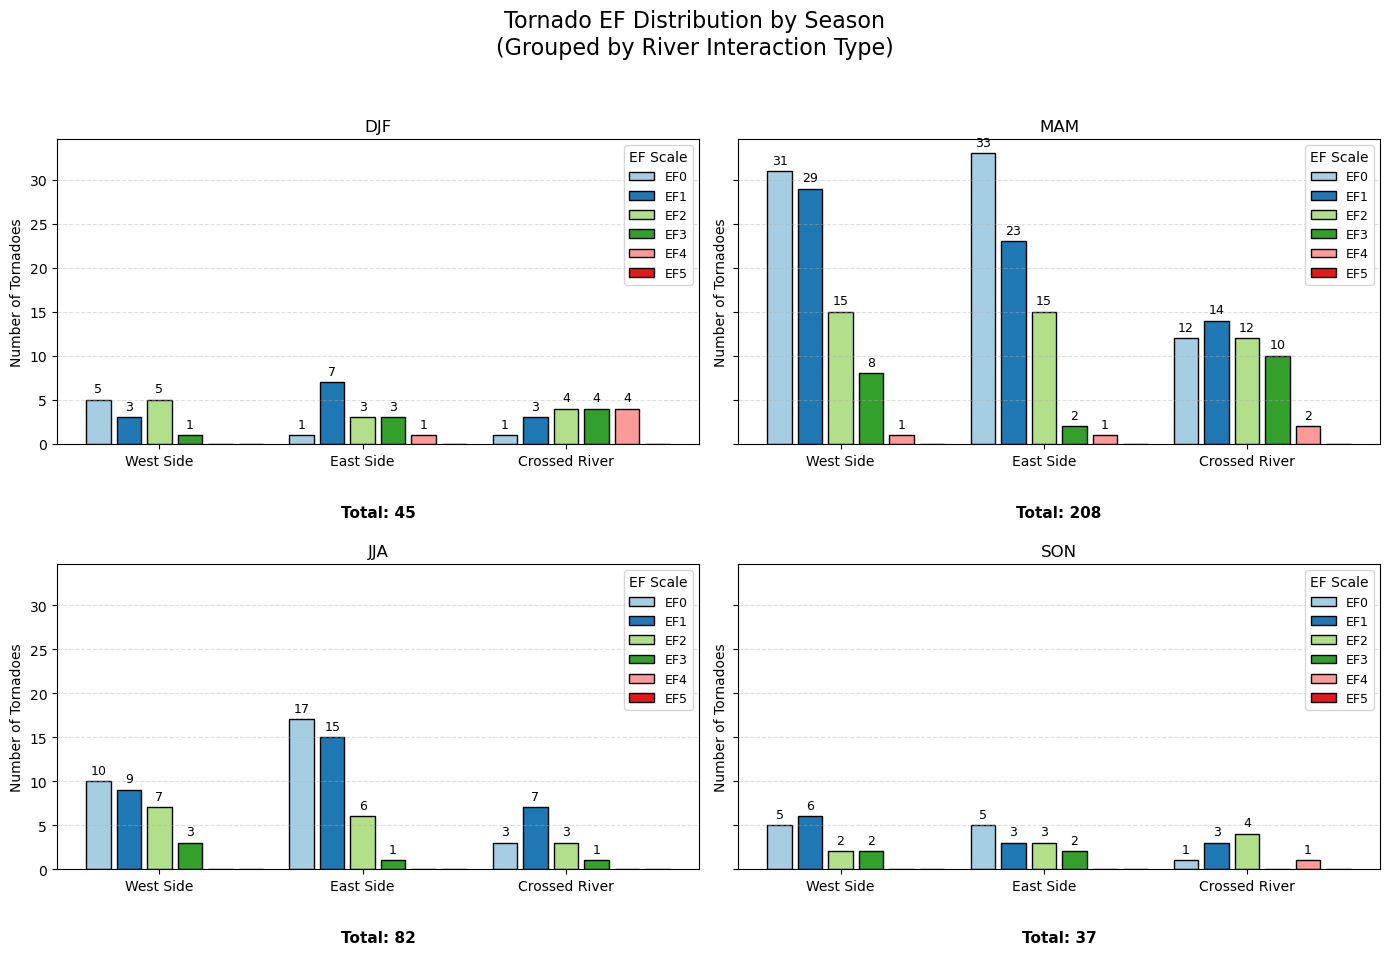


Total tornadoes (should match 372): 372
side_type
West Side        142
East Side        141
Crossed River     89
Name: count, dtype: int64


In [31]:
# ================================================================
# Cell: Seasonal EF Distribution (Grouped Bars + Per-Plot Legends)
# ================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------
# 1. Season function
# ------------------------------------------------
def get_season(month):
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    else:
        return "SON"

# ------------------------------------------------
# 2. Combine tornadoes (buffer + crossing)
# ------------------------------------------------
river_buffer_tornadoes = pd.concat([
    west_side, east_side, crossing_tornadoes
]).copy()

# Assign side_type
river_buffer_tornadoes["side_type"] = np.nan
river_buffer_tornadoes.loc[west_side.index, "side_type"] = "West Side"
river_buffer_tornadoes.loc[east_side.index, "side_type"] = "East Side"
river_buffer_tornadoes.loc[crossing_tornadoes.index, "side_type"] = "Crossed River"

# Ensure datetime + assign season
river_buffer_tornadoes["date"] = pd.to_datetime(
    river_buffer_tornadoes["date"], errors="coerce"
)

river_buffer_tornadoes["season"] = river_buffer_tornadoes["date"].dt.month.apply(get_season)

# ------------------------------------------------
# 3. Group counts
# ------------------------------------------------
plot_data = (
    river_buffer_tornadoes
    .groupby(["season", "side_type", "mag"])
    .size()
    .reset_index(name="count")
)

# ------------------------------------------------
# 4. Plot setup
# ------------------------------------------------
seasons = ["DJF", "MAM", "JJA", "SON"]
sides = ["West Side", "East Side", "Crossed River"]
ef_order = [0, 1, 2, 3, 4, 5]

colors = {
    0: "#a6cee3",
    1: "#1f78b4",
    2: "#b2df8a",
    3: "#33a02c",
    4: "#fb9a99",
    5: "#e31a1c"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

bar_width = 0.12
spacing_factor = 1.25

# ------------------------------------------------
# 5. Plot each season
# ------------------------------------------------
for i, season in enumerate(seasons):

    ax = axes[i]
    season_data = plot_data[plot_data["season"] == season]

    seasonal_total = river_buffer_tornadoes[
        river_buffer_tornadoes["season"] == season
    ].shape[0]

    x = np.arange(len(sides))

    # -------------------------------
    # GROUPED BARS (NOT stacked)
    # -------------------------------
    for j, ef in enumerate(ef_order):

        ef_counts = []

        for side in sides:
            val = season_data[
                (season_data["side_type"] == side) &
                (season_data["mag"] == ef)
            ]["count"]
            ef_counts.append(val.values[0] if not val.empty else 0)

        bars = ax.bar(
            x + j * bar_width * spacing_factor,
            ef_counts,
            width=bar_width,
            color=colors[ef],
            edgecolor='k'
        )

        # Add labels above bars
        for rect, count in zip(bars, ef_counts):
            if count > 0:
                ax.text(
                    rect.get_x() + rect.get_width()/2,
                    rect.get_height() + 0.5,
                    int(count),
                    ha='center',
                    va='bottom',
                    fontsize=9
                )

    # -------------------------------
    # Axis formatting
    # -------------------------------
    ax.set_xticks(x + bar_width * 2.5)
    ax.set_xticklabels(sides)
    ax.set_title(season, fontsize=12)
    ax.set_ylabel("Number of Tornadoes")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    # -------------------------------
    # Legend (PER SUBPLOT)
    # -------------------------------
    legend_handles = [
        plt.Rectangle((0,0),1,1, color=colors[ef], ec='k', label=f"EF{ef}")
        for ef in ef_order
    ]

    ax.legend(
        handles=legend_handles,
        title="EF Scale",
        fontsize=9,
        title_fontsize=10,
        loc="upper right"
    )

    # -------------------------------
    # Seasonal total
    # -------------------------------
    ax.text(
        0.5, -0.20,
        f"Total: {seasonal_total}",
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=11,
        fontweight='bold'
    )

# ------------------------------------------------
# 6. Title + layout
# ------------------------------------------------
plt.suptitle(
    "Tornado EF Distribution by Season\n(Grouped by River Interaction Type)",
    fontsize=16
)

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()

# ------------------------------------------------
# 7. Sanity check
# ------------------------------------------------
print("\nTotal tornadoes (should match 372):", len(river_buffer_tornadoes))
print(river_buffer_tornadoes["side_type"].value_counts())

/tmp/ipykernel_1432/1717380685.py:31: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'West Side' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.




Counts:
Outbreak tornadoes: 92
Non-outbreak tornadoes: 280
Total: 372


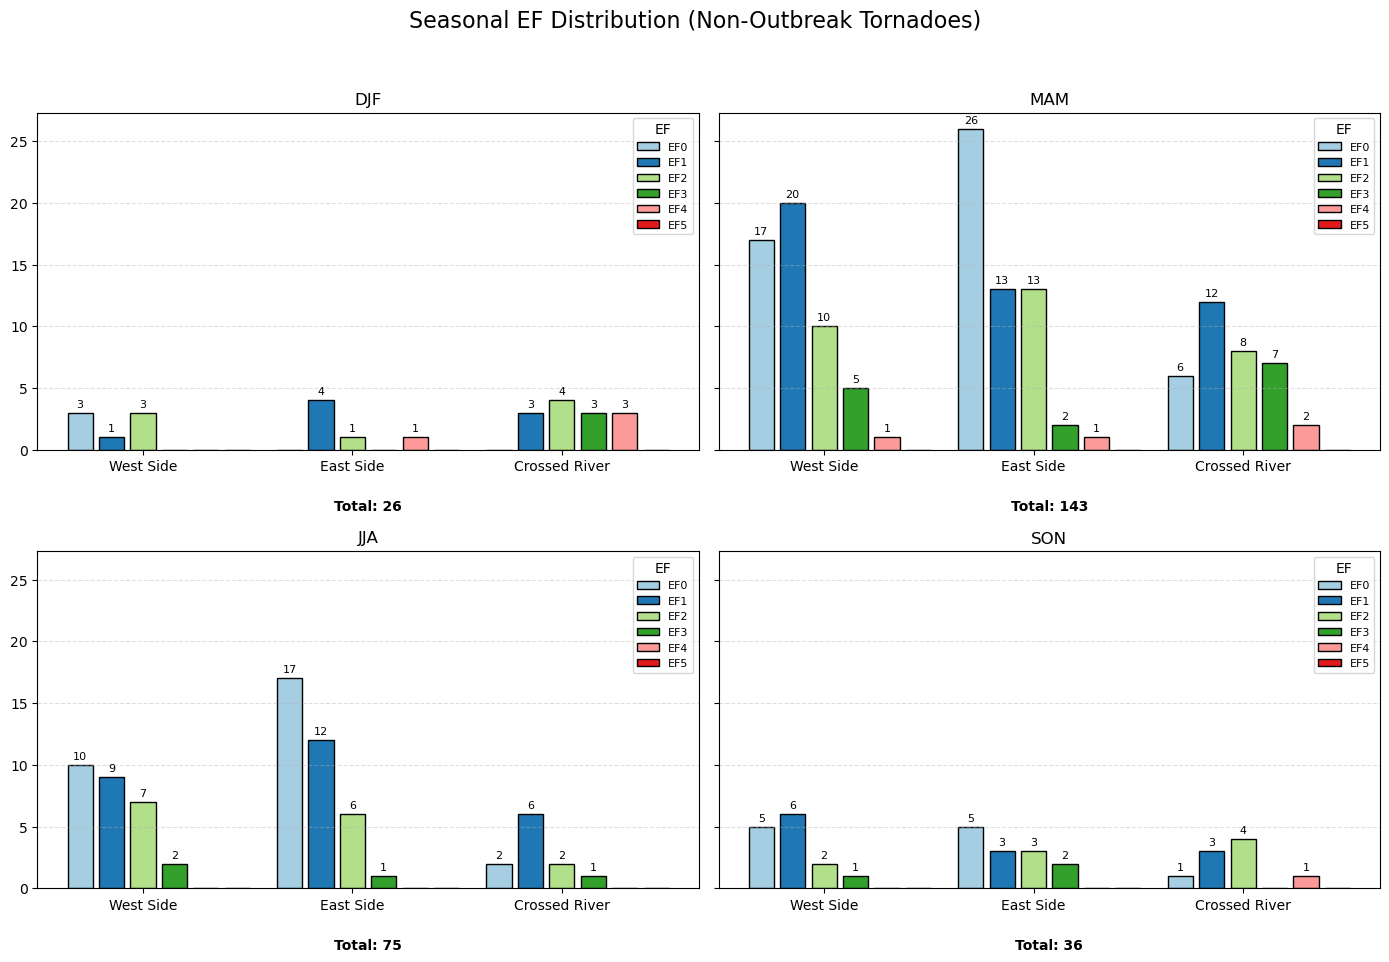

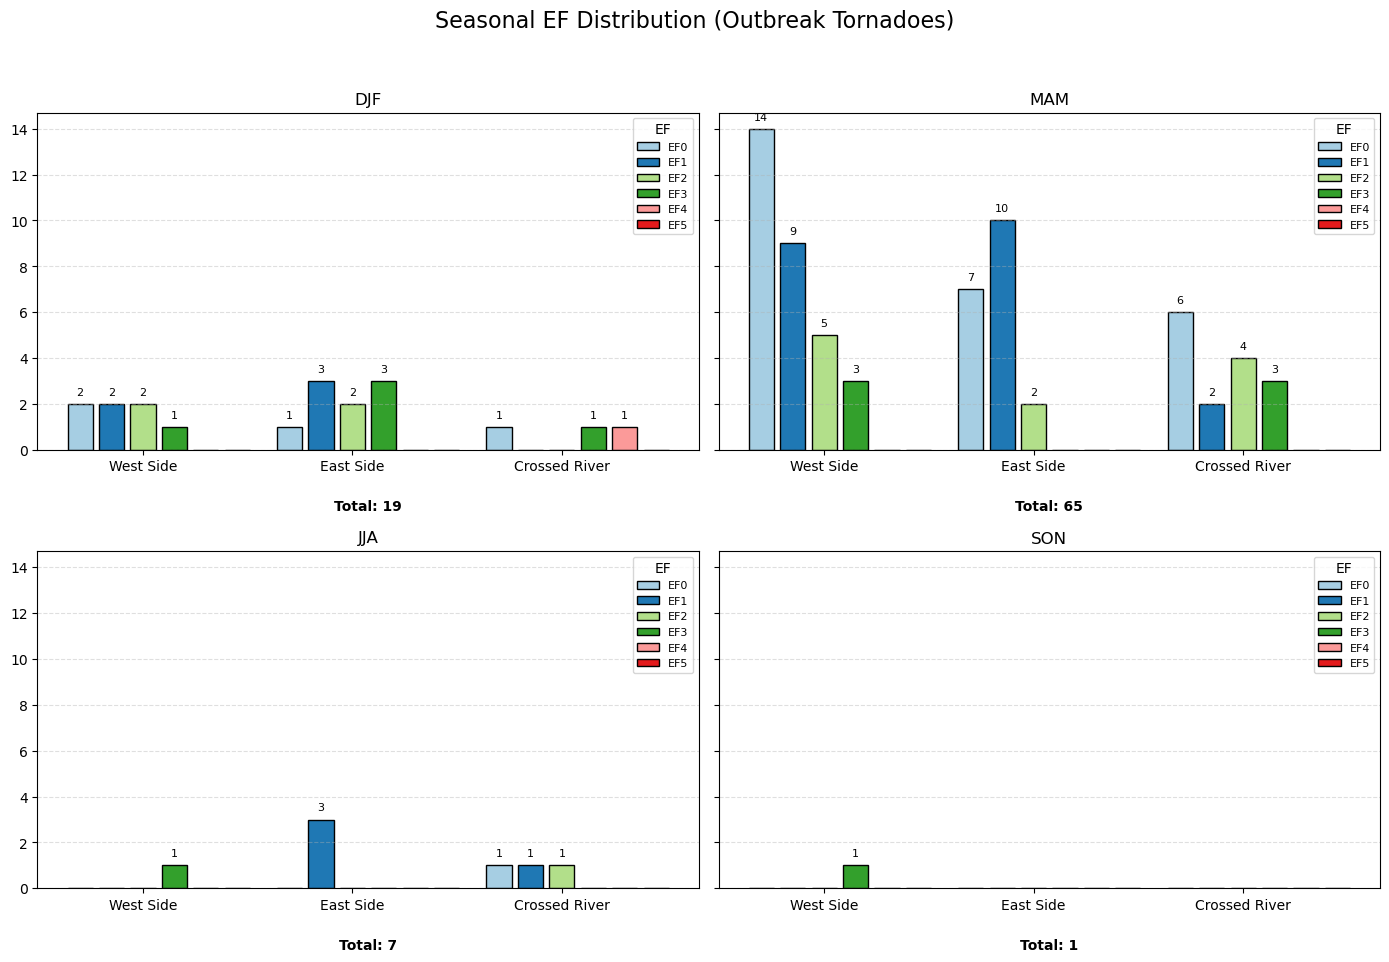

In [32]:
# ================================================================
# Cell: Seasonal EF Distribution (Outbreak vs Non-Outbreak)
# ================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------
# 1. Season function
# ------------------------------------------------
def get_season(month):
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    else:
        return "SON"

# ------------------------------------------------
# 2. Combine tornadoes (372)
# ------------------------------------------------
river_buffer_tornadoes = pd.concat([
    west_side, east_side, crossing_tornadoes
]).copy()

# Assign side_type
river_buffer_tornadoes["side_type"] = np.nan
river_buffer_tornadoes.loc[west_side.index, "side_type"] = "West Side"
river_buffer_tornadoes.loc[east_side.index, "side_type"] = "East Side"
river_buffer_tornadoes.loc[crossing_tornadoes.index, "side_type"] = "Crossed River"

# Ensure datetime
river_buffer_tornadoes["date"] = pd.to_datetime(
    river_buffer_tornadoes["date"], errors="coerce"
)

river_buffer_tornadoes["season"] = river_buffer_tornadoes["date"].dt.month.apply(get_season)

# ------------------------------------------------
# 3. Split outbreak vs non-outbreak (24h window)
# ------------------------------------------------
outbreak_col = "outbreak_24h"

outbreak_df = river_buffer_tornadoes[
    river_buffer_tornadoes[outbreak_col] == "Outbreak"
].copy()

non_outbreak_df = river_buffer_tornadoes[
    river_buffer_tornadoes[outbreak_col] == "Individual"
].copy()

print("\nCounts:")
print("Outbreak tornadoes:", len(outbreak_df))
print("Non-outbreak tornadoes:", len(non_outbreak_df))
print("Total:", len(river_buffer_tornadoes))

# ------------------------------------------------
# 4. Plotting function (reusable)
# ------------------------------------------------
def plot_seasonal(df, title):

    plot_data = (
        df.groupby(["season", "side_type", "mag"])
        .size()
        .reset_index(name="count")
    )

    seasons = ["DJF", "MAM", "JJA", "SON"]
    sides = ["West Side", "East Side", "Crossed River"]
    ef_order = [0, 1, 2, 3, 4, 5]

    colors = {
        0: "#a6cee3",
        1: "#1f78b4",
        2: "#b2df8a",
        3: "#33a02c",
        4: "#fb9a99",
        5: "#e31a1c"
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
    axes = axes.flatten()

    bar_width = 0.12
    spacing_factor = 1.25

    for i, season in enumerate(seasons):

        ax = axes[i]
        season_data = plot_data[plot_data["season"] == season]

        seasonal_total = df[df["season"] == season].shape[0]

        x = np.arange(len(sides))

        for j, ef in enumerate(ef_order):

            ef_counts = []

            for side in sides:
                val = season_data[
                    (season_data["side_type"] == side) &
                    (season_data["mag"] == ef)
                ]["count"]
                ef_counts.append(val.values[0] if not val.empty else 0)

            bars = ax.bar(
                x + j * bar_width * spacing_factor,
                ef_counts,
                width=bar_width,
                color=colors[ef],
                edgecolor='k'
            )

            # Labels
            for rect, count in zip(bars, ef_counts):
                if count > 0:
                    ax.text(
                        rect.get_x() + rect.get_width()/2,
                        rect.get_height() + 0.3,
                        int(count),
                        ha='center',
                        va='bottom',
                        fontsize=8
                    )

        ax.set_xticks(x + bar_width * 2.5)
        ax.set_xticklabels(sides)
        ax.set_title(season)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

        # Legend per subplot
        legend_handles = [
            plt.Rectangle((0,0),1,1, color=colors[ef], ec='k', label=f"EF{ef}")
            for ef in ef_order
        ]

        ax.legend(
            handles=legend_handles,
            fontsize=8,
            title="EF",
            loc="upper right"
        )

        # Seasonal total
        ax.text(
            0.5, -0.18,
            f"Total: {seasonal_total}",
            transform=ax.transAxes,
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0.02, 1, 0.95])
    plt.show()

# ------------------------------------------------
# 5. Generate both plots
# ------------------------------------------------

plot_seasonal(non_outbreak_df,
    "Seasonal EF Distribution (Non-Outbreak Tornadoes)")

plot_seasonal(outbreak_df,
    "Seasonal EF Distribution (Outbreak Tornadoes)")

/tmp/ipykernel_1432/614588046.py:121: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




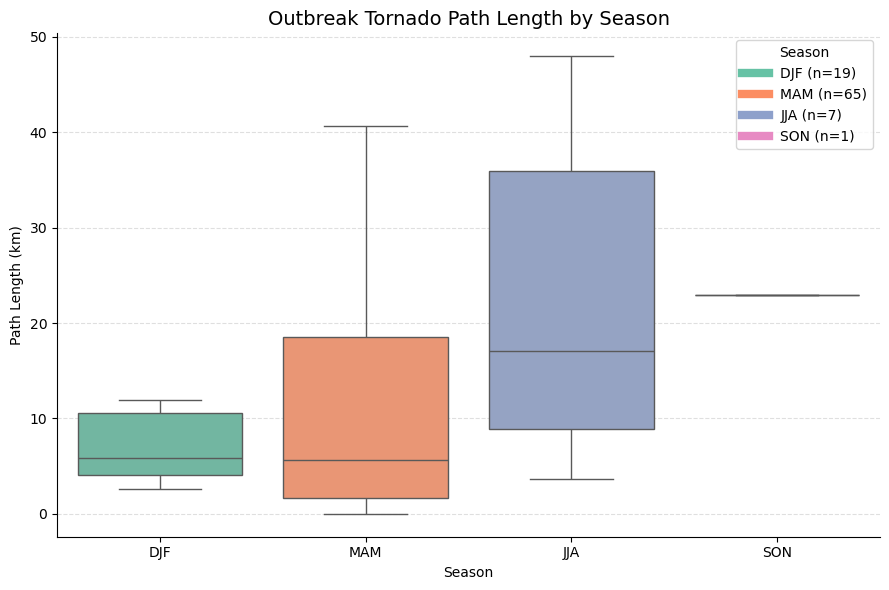


5-Number Summary (Path Length km)
  Season    Min     Q1  Median     Q3     Max
0    DJF   2.66   4.11    5.86  10.54   45.54
1    MAM   0.00   1.61    5.63  18.51  111.37
2    JJA   3.60   8.85   17.06  35.96   47.97
3    SON  22.93  22.93   22.93  22.93   22.93


/tmp/ipykernel_1432/614588046.py:121: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




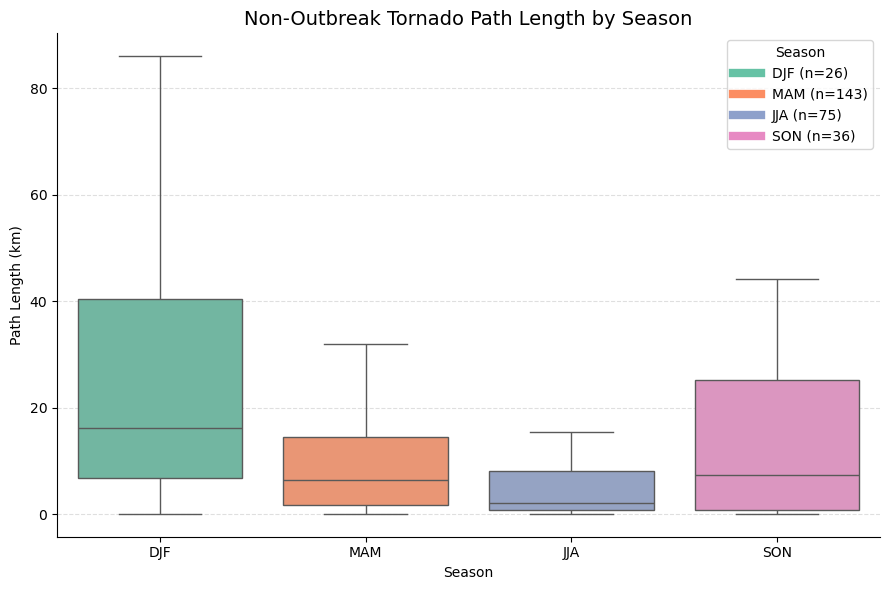


5-Number Summary (Path Length km)
  Season   Min    Q1  Median     Q3     Max
0    DJF  0.06  6.81   16.19  40.38  154.34
1    MAM  0.03  1.67    6.39  14.40  204.55
2    JJA  0.08  0.80    2.09   8.05  237.22
3    SON  0.06  0.82    7.40  25.21  103.80

================ Outbreak Tornadoes =================

Kruskal-Wallis Test
-------------------
H = 4.839
p-value = 0.183999

Pairwise Comparisons
---------------------
  Group1 Group2         H   p-value  Adj p-value  Significant?  \
0    DJF    MAM  0.687128  0.407143     2.442858         False   
1    DJF    JJA  2.528015  0.111841     0.671045         False   
2    DJF    SON  0.910459  0.339993     2.039956         False   
3    MAM    JJA  3.264091  0.070812     0.424873         False   
4    MAM    SON  1.049207  0.305690     1.834139         False   
5    JJA    SON  0.047619  0.827259     4.963556         False   

   Adj Significant?  
0             False  
1             False  
2             False  
3             False  
4  

In [33]:
# ================================================================
# Cell: Seasonal Pathlength Boxplots (Outbreak vs Non-Outbreak)
# ================================================================

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import kruskal
import itertools

# ------------------------------------------------
# 1. Prepare dataset (buffer tornadoes)
# ------------------------------------------------
river_buffer_tornadoes = pd.concat([
    west_side, east_side, crossing_tornadoes
]).copy()

# Path length in km
river_buffer_tornadoes["path_km"] = river_buffer_tornadoes["len"] * 1.60934

# Season (USE LOCAL DATE)
river_buffer_tornadoes["date"] = pd.to_datetime(
    river_buffer_tornadoes["date"], errors="coerce"
)

def get_season(month):
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    else:
        return "SON"

river_buffer_tornadoes["season"] = river_buffer_tornadoes["date"].dt.month.apply(get_season)

# ------------------------------------------------
# 2. Attach outbreak classification (24h window)
# ------------------------------------------------
river_buffer_tornadoes["outbreak_type"] = river_buffer_tornadoes["outbreak_24h"]

# Clean
river_buffer_tornadoes = river_buffer_tornadoes.dropna(
    subset=["path_km", "season", "outbreak_type"]
)

# Order
season_order = ["DJF", "MAM", "JJA", "SON"]
palette = sns.color_palette("Set2", 4)

# ------------------------------------------------
# 3. Function: 5-number summary
# ------------------------------------------------
def five_number(series):
    return [
        np.min(series),
        np.percentile(series, 25),
        np.median(series),
        np.percentile(series, 75),
        np.max(series)
    ]

# ------------------------------------------------
# 4. Function: stats + pairwise tests
# ------------------------------------------------
def run_stats(df, label):

    print(f"\n================ {label} =================")

    groups = [
        df[df["season"] == s]["path_km"]
        for s in season_order
    ]

    # Kruskal-Wallis
    H, p = kruskal(*groups)

    print("\nKruskal-Wallis Test")
    print("-------------------")
    print(f"H = {H:.3f}")
    print(f"p-value = {p:.6f}")

    # Pairwise
    pairs = list(itertools.combinations(season_order, 2))
    results = []

    for g1, g2 in pairs:
        d1 = df[df["season"] == g1]["path_km"]
        d2 = df[df["season"] == g2]["path_km"]

        H_pair, p_pair = kruskal(d1, d2)

        results.append({
            "Group1": g1,
            "Group2": g2,
            "H": H_pair,
            "p-value": p_pair
        })

    results_df = pd.DataFrame(results)

    # Bonferroni
    results_df["Adj p-value"] = results_df["p-value"] * len(results_df)
    results_df["Significant?"] = results_df["p-value"] < 0.05
    results_df["Adj Significant?"] = results_df["Adj p-value"] < 0.05

    print("\nPairwise Comparisons")
    print("---------------------")
    print(results_df)


# ------------------------------------------------
# 5. Plot function
# ------------------------------------------------
def plot_box(df, title):

    plt.figure(figsize=(9,6))

    ax = sns.boxplot(
        data=df,
        x="season",
        y="path_km",
        order=season_order,
        palette=palette,
        showfliers=False
    )

    # Counts
    counts = df["season"].value_counts()

    legend_elements = [
        plt.Line2D([0],[0], color=palette[i], lw=6,
                   label=f"{season_order[i]} (n={counts.get(season_order[i],0)})")
        for i in range(len(season_order))
    ]

    ax.legend(handles=legend_elements, title="Season")

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Season")
    ax.set_ylabel("Path Length (km)")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    sns.despine()
    plt.tight_layout()
    plt.show()

    # 5-number summary
    summary = []
    for s in season_order:
        vals = df[df["season"] == s]["path_km"]
        stats = five_number(vals)

        summary.append([
            s,
            round(stats[0],2),
            round(stats[1],2),
            round(stats[2],2),
            round(stats[3],2),
            round(stats[4],2)
        ])

    summary_df = pd.DataFrame(
        summary,
        columns=["Season","Min","Q1","Median","Q3","Max"]
    )

    print("\n5-Number Summary (Path Length km)")
    print(summary_df)


# ------------------------------------------------
# 6. Split datasets
# ------------------------------------------------
outbreak_df = river_buffer_tornadoes[
    river_buffer_tornadoes["outbreak_type"] == "Outbreak"
]

non_outbreak_df = river_buffer_tornadoes[
    river_buffer_tornadoes["outbreak_type"] == "Individual"
]

# ------------------------------------------------
# 7. Plots
# ------------------------------------------------
plot_box(outbreak_df, "Outbreak Tornado Path Length by Season") #Using DBSCAN approach
plot_box(non_outbreak_df, "Non-Outbreak Tornado Path Length by Season")

# ------------------------------------------------
# 8. Statistics
# ------------------------------------------------
run_stats(outbreak_df, "Outbreak Tornadoes")
run_stats(non_outbreak_df, "Non-Outbreak Tornadoes")

/tmp/ipykernel_1432/85440011.py:125: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




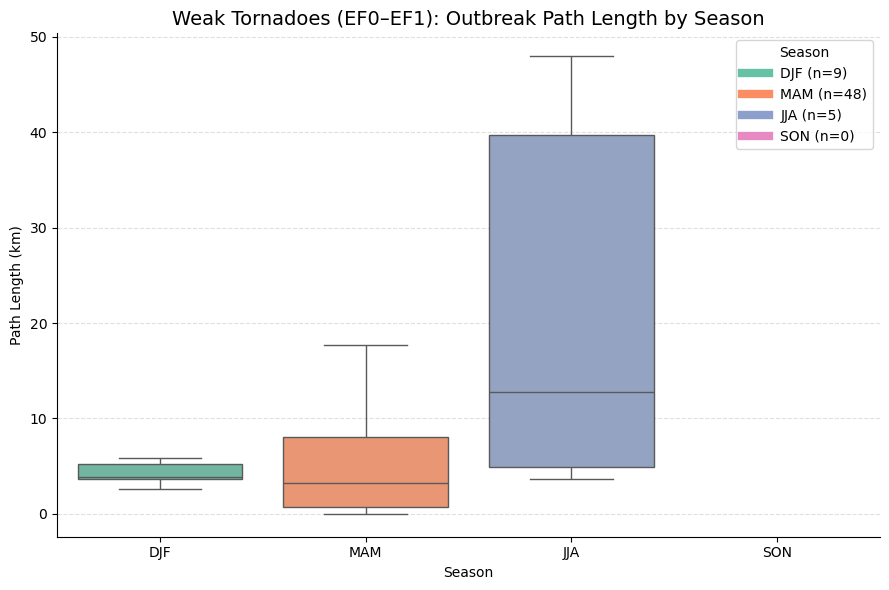


5-Number Summary (Path Length km)
  Season   Min    Q1  Median     Q3    Max
0    DJF  2.66  3.67    3.88   5.25   8.01
1    MAM  0.00  0.76    3.22   8.05  44.90
2    JJA  3.60  4.91   12.79  39.73  47.97
3    SON   NaN   NaN     NaN    NaN    NaN


/tmp/ipykernel_1432/85440011.py:125: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




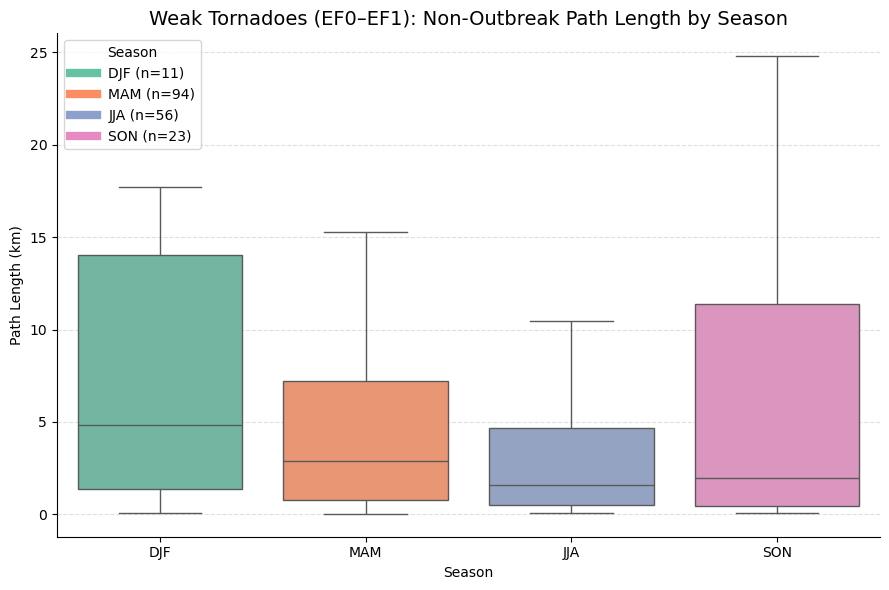


5-Number Summary (Path Length km)
  Season   Min    Q1  Median     Q3     Max
0    DJF  0.06  1.38    4.83  14.01  154.34
1    MAM  0.03  0.80    2.88   7.24  166.57
2    JJA  0.08  0.49    1.61   4.67  237.22
3    SON  0.06  0.48    2.00  11.37   32.73

================ Weak Tornadoes – Outbreak =================

Kruskal-Wallis Test
-------------------
H = nan
p-value = nan

Pairwise Comparisons
---------------------
  Group1 Group2         H   p-value  Adj p-value  Significant?  \
0    DJF    MAM  0.431818  0.511098     3.066589         False   
1    DJF    JJA  2.777778  0.095581     0.573484         False   
2    DJF    SON       NaN       NaN          NaN         False   
3    MAM    JJA  4.547303  0.032971     0.197824          True   
4    MAM    SON       NaN       NaN          NaN         False   
5    JJA    SON       NaN       NaN          NaN         False   

   Adj Significant?  
0             False  
1             False  
2             False  
3             False  
4  

/tmp/ipykernel_1432/85440011.py:83: SmallSampleWarning:

One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.

/tmp/ipykernel_1432/85440011.py:97: SmallSampleWarning:

One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.

/tmp/ipykernel_1432/85440011.py:97: SmallSampleWarning:

One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.

/tmp/ipykernel_1432/85440011.py:97: SmallSampleWarning:

One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.



In [34]:
# ================================================================
# Cell: Seasonal Pathlength Boxplots (Weak Tornadoes: EF0–EF1)
# ================================================================

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import kruskal
import itertools

# ------------------------------------------------
# 1. Prepare dataset (buffer tornadoes)
# ------------------------------------------------
river_buffer_tornadoes = pd.concat([
    west_side, east_side, crossing_tornadoes
]).copy()

# Path length (km)
river_buffer_tornadoes["path_km"] = river_buffer_tornadoes["len"] * 1.60934

# ------------------------------------------------
# FILTER: Weak tornadoes only (EF0–EF1)
# ------------------------------------------------
river_buffer_tornadoes = river_buffer_tornadoes[
    river_buffer_tornadoes["mag"].isin([0, 1])
].copy()

# Season (LOCAL time)
river_buffer_tornadoes["date"] = pd.to_datetime(
    river_buffer_tornadoes["date"], errors="coerce"
)

def get_season(month):
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    else:
        return "SON"

river_buffer_tornadoes["season"] = river_buffer_tornadoes["date"].dt.month.apply(get_season)

# ------------------------------------------------
# 2. Outbreak classification (24h)
# ------------------------------------------------
river_buffer_tornadoes["outbreak_type"] = river_buffer_tornadoes["outbreak_24h"]

# Clean
river_buffer_tornadoes = river_buffer_tornadoes.dropna(
    subset=["path_km", "season", "outbreak_type"]
)

season_order = ["DJF", "MAM", "JJA", "SON"]
palette = sns.color_palette("Set2", 4)

# ------------------------------------------------
# 3. 5-number summary
# ------------------------------------------------
def five_number(series):
    return [
        np.min(series),
        np.percentile(series, 25),
        np.median(series),
        np.percentile(series, 75),
        np.max(series)
    ]

# ------------------------------------------------
# 4. Stats function
# ------------------------------------------------
def run_stats(df, label):

    print(f"\n================ {label} =================")

    groups = [
        df[df["season"] == s]["path_km"]
        for s in season_order
    ]

    H, p = kruskal(*groups)

    print("\nKruskal-Wallis Test")
    print("-------------------")
    print(f"H = {H:.3f}")
    print(f"p-value = {p:.6f}")

    pairs = list(itertools.combinations(season_order, 2))
    results = []

    for g1, g2 in pairs:
        d1 = df[df["season"] == g1]["path_km"]
        d2 = df[df["season"] == g2]["path_km"]

        H_pair, p_pair = kruskal(d1, d2)

        results.append({
            "Group1": g1,
            "Group2": g2,
            "H": H_pair,
            "p-value": p_pair
        })

    results_df = pd.DataFrame(results)

    # Bonferroni correction
    results_df["Adj p-value"] = results_df["p-value"] * len(results_df)
    results_df["Significant?"] = results_df["p-value"] < 0.05
    results_df["Adj Significant?"] = results_df["Adj p-value"] < 0.05

    print("\nPairwise Comparisons")
    print("---------------------")
    print(results_df)


# ------------------------------------------------
# 5. Plot function
# ------------------------------------------------
def plot_box(df, title):

    plt.figure(figsize=(9,6))

    ax = sns.boxplot(
        data=df,
        x="season",
        y="path_km",
        order=season_order,
        palette=palette,
        showfliers=False
    )

    # Counts
    counts = df["season"].value_counts()

    legend_elements = [
        plt.Line2D([0],[0], color=palette[i], lw=6,
                   label=f"{season_order[i]} (n={counts.get(season_order[i],0)})")
        for i in range(len(season_order))
    ]

    ax.legend(handles=legend_elements, title="Season")

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Season")
    ax.set_ylabel("Path Length (km)")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    sns.despine()
    plt.tight_layout()
    plt.show()

    # 5-number summary
    summary = []
    for s in season_order:
        vals = df[df["season"] == s]["path_km"]

        if len(vals) == 0:
            summary.append([s, np.nan, np.nan, np.nan, np.nan, np.nan])
            continue

        stats = five_number(vals)

        summary.append([
            s,
            round(stats[0],2),
            round(stats[1],2),
            round(stats[2],2),
            round(stats[3],2),
            round(stats[4],2)
        ])

    summary_df = pd.DataFrame(
        summary,
        columns=["Season","Min","Q1","Median","Q3","Max"]
    )

    print("\n5-Number Summary (Path Length km)")
    print(summary_df)


# ------------------------------------------------
# 6. Split datasets
# ------------------------------------------------
outbreak_df = river_buffer_tornadoes[
    river_buffer_tornadoes["outbreak_type"] == "Outbreak"
]

non_outbreak_df = river_buffer_tornadoes[
    river_buffer_tornadoes["outbreak_type"] == "Individual"
]

# ------------------------------------------------
# 7. Plots
# ------------------------------------------------
plot_box(outbreak_df, "Weak Tornadoes (EF0–EF1): Outbreak Path Length by Season")
plot_box(non_outbreak_df, "Weak Tornadoes (EF0–EF1): Non-Outbreak Path Length by Season")

# ------------------------------------------------
# 8. Statistics
# ------------------------------------------------
run_stats(outbreak_df, "Weak Tornadoes – Outbreak")
run_stats(non_outbreak_df, "Weak Tornadoes – Non-Outbreak")

In [35]:
#Questions to consider: 
#Do weak tornadoes behave differently in outbreaks vs isolated cases?
#Does seasonality matter even for weak events?
#Are weak tornadoes in spring outbreaks longer-lived than winter ones?

/tmp/ipykernel_1432/2912303516.py:127: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




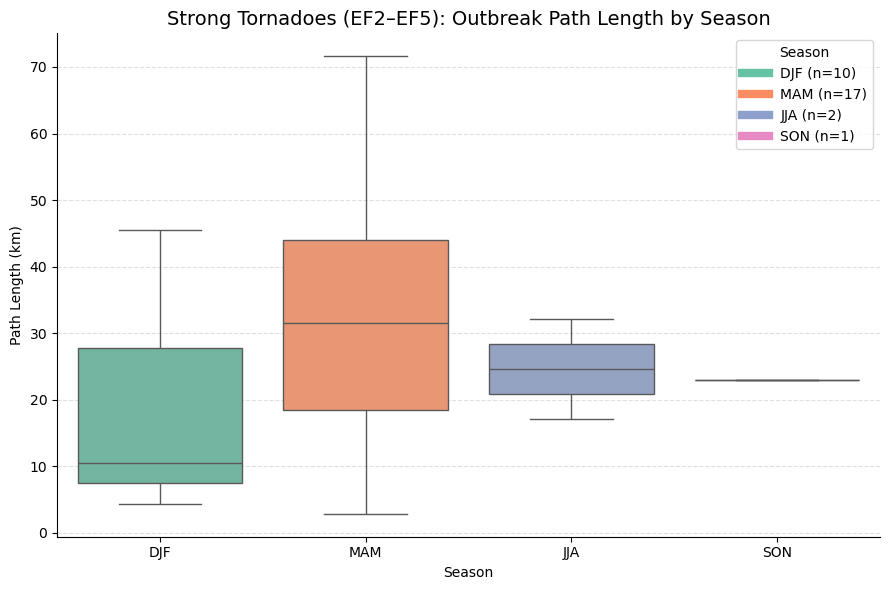


5-Number Summary (Path Length km)
  Season    Min     Q1  Median     Q3     Max
0    DJF   4.35   7.48   10.54  27.72   45.54
1    MAM   2.86  18.51   31.49  43.93  111.37
2    JJA  17.06  20.84   24.62  28.40   32.19
3    SON  22.93  22.93   22.93  22.93   22.93


/tmp/ipykernel_1432/2912303516.py:127: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




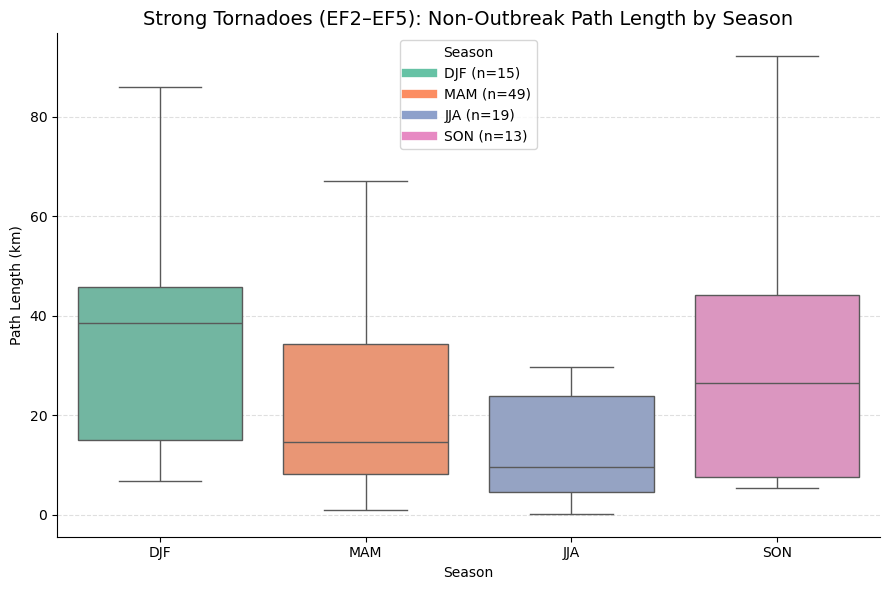


5-Number Summary (Path Length km)
  Season   Min     Q1  Median     Q3     Max
0    DJF  6.79  14.99   38.46  45.71  124.88
1    MAM  0.84   8.21   14.64  34.28  204.55
2    JJA  0.16   4.59    9.66  23.94   78.21
3    SON  5.31   7.56   26.51  44.26  103.80

================ Strong Tornadoes – Outbreak =================

Kruskal-Wallis Test
-------------------
H = 3.372
p-value = 0.337813

Pairwise Comparisons
---------------------
  Group1 Group2         H   p-value  Adj p-value  Significant?  \
0    DJF    MAM  3.182930  0.074411     0.446467         False   
1    DJF    JJA  0.741053  0.389324     2.335943         False   
2    DJF    SON  0.100457  0.751282     4.507694         False   
3    MAM    JJA  0.217129  0.641236     3.847418         False   
4    MAM    SON  0.083938  0.772030     4.632182         False   
5    JJA    SON  0.000000  1.000000     6.000000         False   

   Adj Significant?  
0             False  
1             False  
2             False  
3          

In [36]:
# ================================================================
# Cell: Seasonal Pathlength Boxplots (Strong Tornadoes: EF2–EF5)
# ================================================================

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import kruskal
import itertools

# ------------------------------------------------
# 1. Prepare dataset (buffer tornadoes)
# ------------------------------------------------
river_buffer_tornadoes = pd.concat([
    west_side, east_side, crossing_tornadoes
]).copy()

# Path length (km)
river_buffer_tornadoes["path_km"] = river_buffer_tornadoes["len"] * 1.60934

# ------------------------------------------------
# FILTER: Strong tornadoes only (EF2–EF5)
# ------------------------------------------------
river_buffer_tornadoes = river_buffer_tornadoes[
    river_buffer_tornadoes["mag"].isin([2, 3, 4, 5])
].copy()

# ------------------------------------------------
# Season (LOCAL time)
# ------------------------------------------------
river_buffer_tornadoes["date"] = pd.to_datetime(
    river_buffer_tornadoes["date"], errors="coerce"
)

def get_season(month):
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    else:
        return "SON"

river_buffer_tornadoes["season"] = river_buffer_tornadoes["date"].dt.month.apply(get_season)

# ------------------------------------------------
# 2. Outbreak classification (24h)
# ------------------------------------------------
river_buffer_tornadoes["outbreak_type"] = river_buffer_tornadoes["outbreak_24h"]

# Clean
river_buffer_tornadoes = river_buffer_tornadoes.dropna(
    subset=["path_km", "season", "outbreak_type"]
)

season_order = ["DJF", "MAM", "JJA", "SON"]
palette = sns.color_palette("Set2", 4)

# ------------------------------------------------
# 3. 5-number summary
# ------------------------------------------------
def five_number(series):
    return [
        np.min(series),
        np.percentile(series, 25),
        np.median(series),
        np.percentile(series, 75),
        np.max(series)
    ]

# ------------------------------------------------
# 4. Stats function
# ------------------------------------------------
def run_stats(df, label):

    print(f"\n================ {label} =================")

    groups = [
        df[df["season"] == s]["path_km"]
        for s in season_order
    ]

    H, p = kruskal(*groups)

    print("\nKruskal-Wallis Test")
    print("-------------------")
    print(f"H = {H:.3f}")
    print(f"p-value = {p:.6f}")

    pairs = list(itertools.combinations(season_order, 2))
    results = []

    for g1, g2 in pairs:
        d1 = df[df["season"] == g1]["path_km"]
        d2 = df[df["season"] == g2]["path_km"]

        H_pair, p_pair = kruskal(d1, d2)

        results.append({
            "Group1": g1,
            "Group2": g2,
            "H": H_pair,
            "p-value": p_pair
        })

    results_df = pd.DataFrame(results)

    # Bonferroni correction
    results_df["Adj p-value"] = results_df["p-value"] * len(results_df)
    results_df["Significant?"] = results_df["p-value"] < 0.05
    results_df["Adj Significant?"] = results_df["Adj p-value"] < 0.05

    print("\nPairwise Comparisons")
    print("---------------------")
    print(results_df)


# ------------------------------------------------
# 5. Plot function
# ------------------------------------------------
def plot_box(df, title):

    plt.figure(figsize=(9,6))

    ax = sns.boxplot(
        data=df,
        x="season",
        y="path_km",
        order=season_order,
        palette=palette,
        showfliers=False
    )

    # Counts
    counts = df["season"].value_counts()

    legend_elements = [
        plt.Line2D([0],[0], color=palette[i], lw=6,
                   label=f"{season_order[i]} (n={counts.get(season_order[i],0)})")
        for i in range(len(season_order))
    ]

    ax.legend(handles=legend_elements, title="Season")

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Season")
    ax.set_ylabel("Path Length (km)")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    sns.despine()
    plt.tight_layout()
    plt.show()

    # 5-number summary
    summary = []
    for s in season_order:
        vals = df[df["season"] == s]["path_km"]

        if len(vals) == 0:
            summary.append([s, np.nan, np.nan, np.nan, np.nan, np.nan])
            continue

        stats = five_number(vals)

        summary.append([
            s,
            round(stats[0],2),
            round(stats[1],2),
            round(stats[2],2),
            round(stats[3],2),
            round(stats[4],2)
        ])

    summary_df = pd.DataFrame(
        summary,
        columns=["Season","Min","Q1","Median","Q3","Max"]
    )

    print("\n5-Number Summary (Path Length km)")
    print(summary_df)


# ------------------------------------------------
# 6. Split datasets
# ------------------------------------------------
outbreak_df = river_buffer_tornadoes[
    river_buffer_tornadoes["outbreak_type"] == "Outbreak"
]

non_outbreak_df = river_buffer_tornadoes[
    river_buffer_tornadoes["outbreak_type"] == "Individual"
]

# ------------------------------------------------
# 7. Plots
# ------------------------------------------------
plot_box(outbreak_df, "Strong Tornadoes (EF2–EF5): Outbreak Path Length by Season")
plot_box(non_outbreak_df, "Strong Tornadoes (EF2–EF5): Non-Outbreak Path Length by Season")

# ------------------------------------------------
# 8. Statistics
# ------------------------------------------------
run_stats(outbreak_df, "Strong Tornadoes – Outbreak")
run_stats(non_outbreak_df, "Strong Tornadoes – Non-Outbreak")

In [38]:
# import matplotlib.pyplot as plt
# import geopandas as gpd
# import numpy as np

# # ------------------------------------------------
# # 1. Convert everything to lat/lon
# # ------------------------------------------------
# river_latlon = gpd.GeoSeries([river_il_geom], crs=target_crs).to_crs("EPSG:4326")
# buffer_latlon = gpd.GeoSeries([river_buffer], crs=target_crs).to_crs("EPSG:4326")

# states_latlon = states_plot.to_crs("EPSG:4326")

# # ------------------------------------------------
# # 2. Compute centroid X (IN PROJECTED CRS)
# # ------------------------------------------------
# river_center_x_proj = river_il_geom.centroid.x

# # Convert that vertical line into lat/lon space
# # Strategy: create line in projected CRS, then reproject

# ymin, ymax = river_il_geom.bounds[1], river_il_geom.bounds[3]

# from shapely.geometry import LineString

# centroid_line_proj = LineString([
#     (river_center_x_proj, ymin),
#     (river_center_x_proj, ymax)
# ])

# centroid_line_latlon = gpd.GeoSeries(
#     [centroid_line_proj],
#     crs=target_crs
# ).to_crs("EPSG:4326")

# # ------------------------------------------------
# # 3. Plot
# # ------------------------------------------------
# fig, ax = plt.subplots(figsize=(10, 12))

# # States
# states_latlon.boundary.plot(ax=ax, color="black", linewidth=1, alpha=0.6)

# # River
# river_latlon.plot(ax=ax, color="blue", linewidth=1.5, label="Mississippi River")

# # Buffer (10 km)
# buffer_latlon.boundary.plot(
#     ax=ax,
#     color="red",
#     linewidth=2,
#     linestyle="--",
#     label="10 km Buffer"
# )

# # ------------------------------------------------
# # Centroid X split line
# # ------------------------------------------------
# centroid_line_latlon.plot(
#     ax=ax,
#     color="purple",
#     linewidth=2,
#     linestyle=":",
#     label="River Centroid X (West/East Split)"
# )

# # ------------------------------------------------
# # Labels
# # ------------------------------------------------
# ax.set_title("Mississippi River Buffer and West/East Split Line", fontsize=14)
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")

# ax.legend()

# plt.tight_layout()
# plt.show()

In [39]:
# import matplotlib.pyplot as plt
# import geopandas as gpd
# import numpy as np
# from shapely.ops import nearest_points

# # ------------------------------------------------
# # 1. Rebuild buffer-only tornadoes (important)
# # ------------------------------------------------
# buffer_only = tornado_gdf[
#     tornado_gdf.intersects(river_buffer) &
#     (~tornado_gdf.intersects(river_il_geom))
# ].copy()

# # ------------------------------------------------
# # 2. Apply nearest-point classification
# # ------------------------------------------------
# def assign_side_nearest(row):
#     centroid = row.geometry.representative_point()
#     nearest = nearest_points(centroid, river_il_geom)[1]
#     dx = centroid.x - nearest.x
#     return "West" if dx < 0 else "East"

# buffer_only["side_np"] = buffer_only.apply(assign_side_nearest, axis=1)

# # Split
# west_np = buffer_only[buffer_only["side_np"] == "West"]
# east_np = buffer_only[buffer_only["side_np"] == "East"]

# # ------------------------------------------------
# # 3. Convert everything to lat/lon
# # ------------------------------------------------
# west_latlon = west_np.to_crs("EPSG:4326")
# east_latlon = east_np.to_crs("EPSG:4326")

# river_latlon = gpd.GeoSeries([river_il_geom], crs=target_crs).to_crs("EPSG:4326")
# buffer_latlon = gpd.GeoSeries([river_buffer], crs=target_crs).to_crs("EPSG:4326")
# states_latlon = states_plot.to_crs("EPSG:4326")

# # ------------------------------------------------
# # 4. Plot
# # ------------------------------------------------
# fig, ax = plt.subplots(figsize=(10, 12))

# # States
# states_latlon.boundary.plot(ax=ax, color="black", linewidth=1, alpha=0.6)

# # Buffer
# buffer_latlon.boundary.plot(
#     ax=ax,
#     color="red",
#     linestyle="--",
#     linewidth=2,
#     label="10 km Buffer"
# )

# # River
# river_latlon.plot(
#     ax=ax,
#     color="blue",
#     linewidth=1.5,
#     label="Mississippi River"
# )

# # ------------------------------------------------
# # West/East classification points
# # ------------------------------------------------
# west_latlon.plot(
#     ax=ax,
#     color="green",
#     markersize=10,
#     label="West (nearest-point)"
# )

# east_latlon.plot(
#     ax=ax,
#     color="orange",
#     markersize=10,
#     label="East (nearest-point)"
# )

# # ------------------------------------------------
# # Labels
# # ------------------------------------------------
# ax.set_title("Nearest-Point West/East Classification (Buffer Tornadoes)", fontsize=14)
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")

# ax.legend()

# plt.tight_layout()
# plt.show()

In [40]:
# import matplotlib.pyplot as plt
# import geopandas as gpd
# import numpy as np
# from shapely.geometry import LineString

# # ------------------------------------------------
# # 1. Rebuild buffer-only tornadoes
# # ------------------------------------------------
# buffer_only = tornado_gdf[
#     tornado_gdf.intersects(river_buffer) &
#     (~tornado_gdf.intersects(river_il_geom))
# ].copy()

# # ------------------------------------------------
# # 2. Centroid-based classification
# # ------------------------------------------------
# buffer_only["centroid"] = buffer_only.geometry.centroid

# river_center_x = river_il_geom.centroid.x

# west_centroid = buffer_only[buffer_only["centroid"].x < river_center_x]
# east_centroid = buffer_only[buffer_only["centroid"].x >= river_center_x]

# # ------------------------------------------------
# # 3. Convert to lat/lon
# # ------------------------------------------------
# west_latlon = west_centroid.to_crs("EPSG:4326")
# east_latlon = east_centroid.to_crs("EPSG:4326")

# river_latlon = gpd.GeoSeries([river_il_geom], crs=target_crs).to_crs("EPSG:4326")
# buffer_latlon = gpd.GeoSeries([river_buffer], crs=target_crs).to_crs("EPSG:4326")
# states_latlon = states_plot.to_crs("EPSG:4326")

# # ------------------------------------------------
# # 4. Build vertical split line
# # ------------------------------------------------
# ymin, ymax = river_il_geom.bounds[1], river_il_geom.bounds[3]

# centroid_line_proj = LineString([
#     (river_center_x, ymin),
#     (river_center_x, ymax)
# ])

# centroid_line_latlon = gpd.GeoSeries(
#     [centroid_line_proj],
#     crs=target_crs
# ).to_crs("EPSG:4326")

# # ------------------------------------------------
# # 5. Plot
# # ------------------------------------------------
# fig, ax = plt.subplots(figsize=(10, 12))

# # States
# states_latlon.boundary.plot(ax=ax, color="black", linewidth=1, alpha=0.6)

# # Buffer
# buffer_latlon.boundary.plot(
#     ax=ax,
#     color="red",
#     linestyle="--",
#     linewidth=2,
#     label="10 km Buffer"
# )

# # River
# river_latlon.plot(
#     ax=ax,
#     color="blue",
#     linewidth=1.5,
#     label="Mississippi River"
# )

# # ------------------------------------------------
# # West/East classification points
# # ------------------------------------------------
# west_latlon.plot(
#     ax=ax,
#     color="green",
#     markersize=10,
#     label="West (centroid split)"
# )

# east_latlon.plot(
#     ax=ax,
#     color="orange",
#     markersize=10,
#     label="East (centroid split)"
# )

# # ------------------------------------------------
# # Vertical split line
# # ------------------------------------------------
# centroid_line_latlon.plot(
#     ax=ax,
#     color="purple",
#     linestyle=":",
#     linewidth=2,
#     label="Centroid X Split Line"
# )

# # ------------------------------------------------
# # Labels
# # ------------------------------------------------
# ax.set_title("Centroid-Based West/East Classification (Buffer Tornadoes)", fontsize=14)
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")

# ax.legend()

# plt.tight_layout()
# plt.show()


CENTROID METHOD COUNTS
West:      120
East:      163
Crossing:  89
Total:     372

NEAREST-POINT METHOD COUNTS
West:      142
East:      141
Crossing:  89
Total:     372


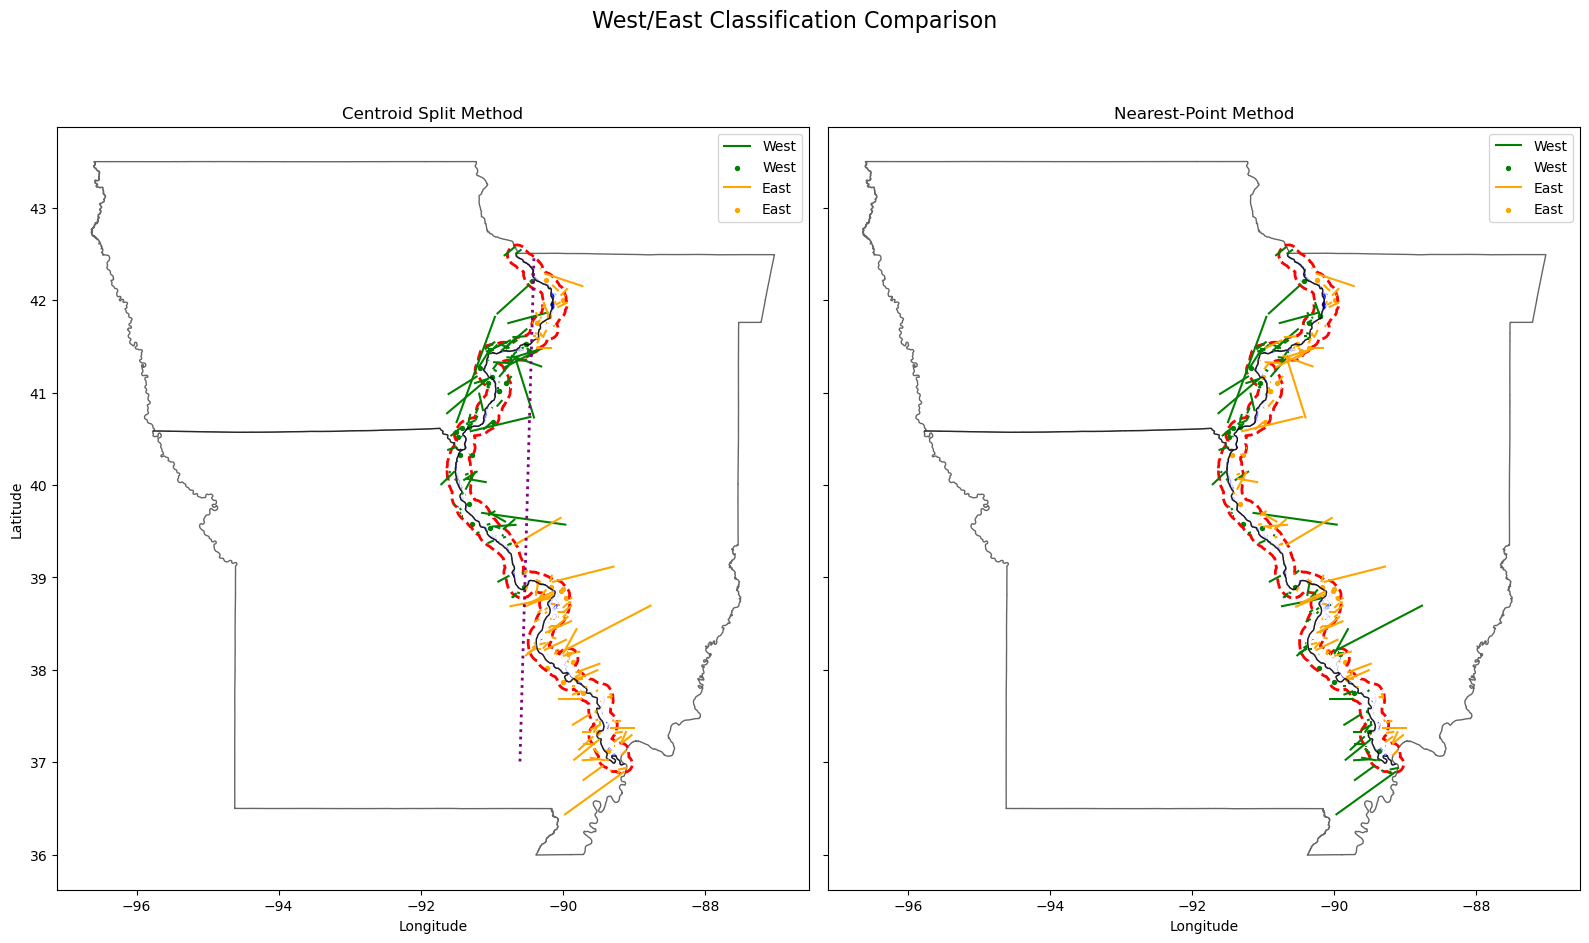

In [37]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import LineString
from shapely.ops import nearest_points

# ------------------------------------------------
# 1. Rebuild datasets
# ------------------------------------------------
all_tornadoes = tornado_gdf.copy()

crossing_tornadoes = all_tornadoes[
    all_tornadoes.intersects(river_il_geom)
].copy()

buffer_only = all_tornadoes[
    all_tornadoes.intersects(river_buffer) &
    (~all_tornadoes.intersects(river_il_geom))
].copy()

# ------------------------------------------------
# 2. METHOD 1: CENTROID SPLIT
# ------------------------------------------------
buffer_only["centroid"] = buffer_only.geometry.centroid
river_center_x = river_il_geom.centroid.x

west_centroid = buffer_only[buffer_only["centroid"].x < river_center_x]
east_centroid = buffer_only[buffer_only["centroid"].x >= river_center_x]

# ------------------------------------------------
# 3. METHOD 2: NEAREST-POINT SPLIT
# ------------------------------------------------
def assign_side(row):
    centroid = row.geometry.representative_point()
    nearest = nearest_points(centroid, river_il_geom)[1]
    dx = centroid.x - nearest.x
    return "West" if dx < 0 else "East"

buffer_only["side_np"] = buffer_only.apply(assign_side, axis=1)

west_np = buffer_only[buffer_only["side_np"] == "West"]
east_np = buffer_only[buffer_only["side_np"] == "East"]

# ------------------------------------------------
# 4. PRINT COUNTS
# ------------------------------------------------
print("\n==============================")
print("CENTROID METHOD COUNTS")
print("==============================")
print(f"West:      {len(west_centroid)}")
print(f"East:      {len(east_centroid)}")
print(f"Crossing:  {len(crossing_tornadoes)}")
print(f"Total:     {len(west_centroid) + len(east_centroid) + len(crossing_tornadoes)}")

print("\n==============================")
print("NEAREST-POINT METHOD COUNTS")
print("==============================")
print(f"West:      {len(west_np)}")
print(f"East:      {len(east_np)}")
print(f"Crossing:  {len(crossing_tornadoes)}")
print(f"Total:     {len(west_np) + len(east_np) + len(crossing_tornadoes)}")

# ------------------------------------------------
# 5. Convert to lat/lon
# ------------------------------------------------
states_latlon = states_plot.to_crs("EPSG:4326")
river_latlon = gpd.GeoSeries([river_il_geom], crs=target_crs).to_crs("EPSG:4326")
buffer_latlon = gpd.GeoSeries([river_buffer], crs=target_crs).to_crs("EPSG:4326")

west_centroid_ll = west_centroid.to_crs("EPSG:4326")
east_centroid_ll = east_centroid.to_crs("EPSG:4326")

west_np_ll = west_np.to_crs("EPSG:4326")
east_np_ll = east_np.to_crs("EPSG:4326")

# ------------------------------------------------
# 6. Build centroid split line
# ------------------------------------------------
ymin, ymax = river_il_geom.bounds[1], river_il_geom.bounds[3]

centroid_line = LineString([
    (river_center_x, ymin),
    (river_center_x, ymax)
])

centroid_line_ll = gpd.GeoSeries([centroid_line], crs=target_crs).to_crs("EPSG:4326")

# ------------------------------------------------
# 7. Plot side-by-side
# ------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharex=True, sharey=True)

# ======================
# LEFT: CENTROID METHOD
# ======================
ax = axes[0]

states_latlon.boundary.plot(ax=ax, color="black", linewidth=1, alpha=0.6)
buffer_latlon.boundary.plot(ax=ax, color="red", linestyle="--", linewidth=2)
river_latlon.plot(ax=ax, color="blue", linewidth=1.5)

west_centroid_ll.plot(ax=ax, color="green", markersize=8, label="West")
east_centroid_ll.plot(ax=ax, color="orange", markersize=8, label="East")

centroid_line_ll.plot(ax=ax, color="purple", linestyle=":", linewidth=2)

ax.set_title("Centroid Split Method")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()

# ======================
# RIGHT: NEAREST METHOD
# ======================
ax = axes[1]

states_latlon.boundary.plot(ax=ax, color="black", linewidth=1, alpha=0.6)
buffer_latlon.boundary.plot(ax=ax, color="red", linestyle="--", linewidth=2)
river_latlon.plot(ax=ax, color="blue", linewidth=1.5)

west_np_ll.plot(ax=ax, color="green", markersize=8, label="West")
east_np_ll.plot(ax=ax, color="orange", markersize=8, label="East")

ax.set_title("Nearest-Point Method")
ax.set_xlabel("Longitude")
ax.legend()

plt.suptitle("West/East Classification Comparison", fontsize=16)

plt.tight_layout()
plt.show()

In [38]:
#Outbreak vs. Non-outbreak pathlength comparison by side type. Then do a second boxplot where random subsampling of the non-outbreak cases occurs to match outbreak count. Then 10,000 iterations for robustness. 

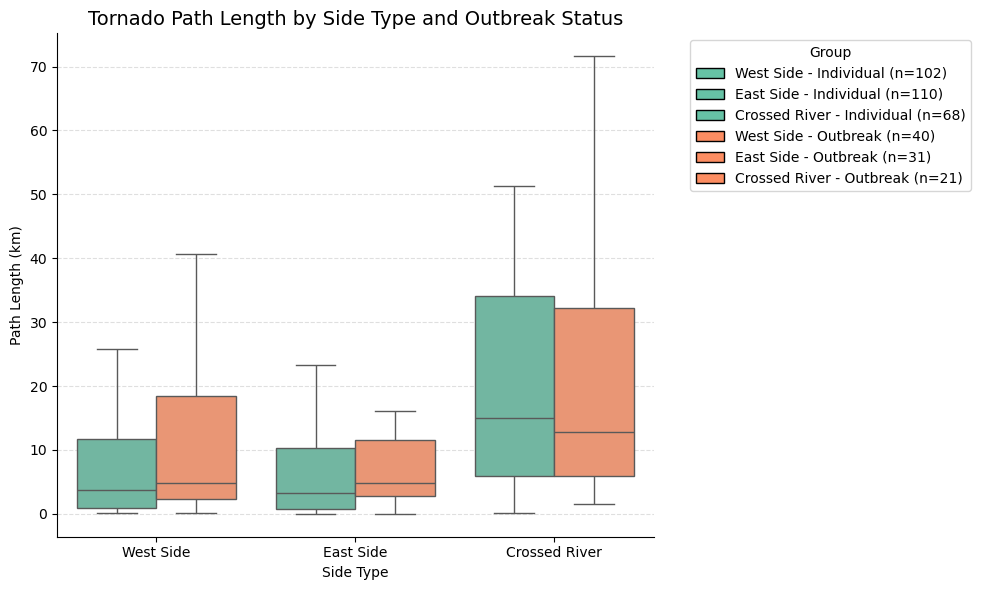


--- 5-Number Summary (Path Length in km) ---


,Group,Min,Q1,Median,Q3,Max
0,West Side - Individual,0.06,0.84,3.67,11.71,147.25
1,West Side - Outbreak,0.16,2.39,4.83,18.51,51.50
2,East Side - Individual,0.03,0.80,3.22,10.35,80.47
3,East Side - Outbreak,0.00,2.82,4.83,11.59,107.83
4,Crossed River - Individual,0.16,5.94,14.99,34.04,237.22
5,Crossed River - Outbreak,1.61,5.86,12.87,32.19,111.37



Kruskal-Wallis Test (All 6 Groups)
----------------------------------
H = 45.283
p-value = 0.000000

Pairwise Kruskal-Wallis Tests
--------------------------------


,Group1,Group2,H,p-value,Adj p-value (Bonferroni),Significant?,Adj Significant?
0,West Side - Individual,West Side - Outbreak,1.280718,2.577655e-01,3.866483e+00,False,False
1,West Side - Individual,East Side - Individual,0.645563,4.217034e-01,6.325550e+00,False,False
2,West Side - Individual,East Side - Outbreak,1.110476,2.919785e-01,4.379677e+00,False,False
3,West Side - Individual,Crossed River - Individual,25.870846,3.650409e-07,5.475614e-06,True,True
4,West Side - Individual,Crossed River - Outbreak,10.915910,9.534185e-04,1.430128e-02,True,True
5,West Side - Outbreak,East Side - Individual,2.246603,1.339080e-01,2.008621e+00,False,False
6,West Side - Outbreak,East Side - Outbreak,0.000841,9.768666e-01,1.465300e+01,False,False
7,West Side - Outbreak,Crossed River - Individual,9.681259,1.861570e-03,2.792355e-02,True,True
8,West Side - Outbreak,Crossed River - Outbreak,5.085332,2.412906e-02,3.619359e-01,True,False
9,East Side - Individual,East Side - Outbreak,2.209548,1.371589e-01,2.057383e+00,False,False


In [39]:
# ------------------------------------------------
# 1. Build dataset
# ------------------------------------------------
plot_df = pd.concat([
    west_side.assign(side_type="West Side"),
    east_side.assign(side_type="East Side"),
    crossing_tornadoes.assign(side_type="Crossed River")
]).copy()

# Path length (km)
plot_df["path_km"] = plot_df["len"] * 1.60934

# Outbreak classification (use 24h window)
plot_df["outbreak_type"] = plot_df["outbreak_24h"]

# Drop missing
plot_df = plot_df.dropna(subset=["path_km", "side_type", "outbreak_type"])

# ------------------------------------------------
# 2. Boxplot (6 boxes total)
# ------------------------------------------------
plt.figure(figsize=(10,6))

palette = sns.color_palette("Set2", 2)

ax = sns.boxplot(
    data=plot_df,
    x="side_type",
    y="path_km",
    hue="outbreak_type",
    palette=palette,
    showfliers=False
)

# Counts for legend
counts = plot_df.groupby(["side_type","outbreak_type"]).size()

legend_elements = []
for i, ot in enumerate(["Individual","Outbreak"]):
    for side in ["West Side","East Side","Crossed River"]:
        if (side, ot) in counts:
            n = counts[(side, ot)]
            legend_elements.append(
                Patch(facecolor=palette[i], edgecolor='black',
                      label=f"{side} - {ot} (n={n})")
            )

ax.legend(handles=legend_elements, title="Group", bbox_to_anchor=(1.05,1), loc="upper left")

ax.set_title("Tornado Path Length by Side Type and Outbreak Status", fontsize=14)
ax.set_xlabel("Side Type")
ax.set_ylabel("Path Length (km)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 3. 5-number summary
# ------------------------------------------------
def five_number(series):
    return [
        np.min(series),
        np.percentile(series, 25),
        np.median(series),
        np.percentile(series, 75),
        np.max(series)
    ]

order = []
for side in ["West Side","East Side","Crossed River"]:
    for ot in ["Individual","Outbreak"]:
        order.append((side, ot))

summary_rows = []

for side, ot in order:
    subset = plot_df[
        (plot_df["side_type"] == side) &
        (plot_df["outbreak_type"] == ot)
    ]["path_km"]

    if len(subset) == 0:
        continue

    stats = five_number(subset)

    summary_rows.append([
        f"{side} - {ot}",
        round(stats[0],2),
        round(stats[1],2),
        round(stats[2],2),
        round(stats[3],2),
        round(stats[4],2)
    ])

summary_df = pd.DataFrame(
    summary_rows,
    columns=["Group","Min","Q1","Median","Q3","Max"]
)

print("\n--- 5-Number Summary (Path Length in km) ---")
display(summary_df)

# ------------------------------------------------
# 4. Kruskal-Wallis (overall test across 6 groups)
# ------------------------------------------------
groups = [
    plot_df[
        (plot_df["side_type"] == side) &
        (plot_df["outbreak_type"] == ot)
    ]["path_km"]
    for side, ot in order
    if len(plot_df[
        (plot_df["side_type"] == side) &
        (plot_df["outbreak_type"] == ot)
    ]) > 0
]

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test (All 6 Groups)")
print("----------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

# ------------------------------------------------
# 5. Pairwise comparisons
# ------------------------------------------------
results = []

valid_groups = [
    (side, ot) for side, ot in order
    if len(plot_df[
        (plot_df["side_type"] == side) &
        (plot_df["outbreak_type"] == ot)
    ]) > 0
]

for (s1, o1), (s2, o2) in itertools.combinations(valid_groups, 2):

    data1 = plot_df[
        (plot_df["side_type"] == s1) &
        (plot_df["outbreak_type"] == o1)
    ]["path_km"]

    data2 = plot_df[
        (plot_df["side_type"] == s2) &
        (plot_df["outbreak_type"] == o2)
    ]["path_km"]

    H_pair, p_pair = kruskal(data1, data2)

    results.append({
        "Group1": f"{s1} - {o1}",
        "Group2": f"{s2} - {o2}",
        "H": H_pair,
        "p-value": p_pair
    })

results_df = pd.DataFrame(results)

# Bonferroni correction
results_df["Adj p-value (Bonferroni)"] = results_df["p-value"] * len(results_df)
results_df["Significant?"] = results_df["p-value"] < 0.05
results_df["Adj Significant?"] = results_df["Adj p-value (Bonferroni)"] < 0.05

print("\nPairwise Kruskal-Wallis Tests")
print("--------------------------------")
display(results_df)

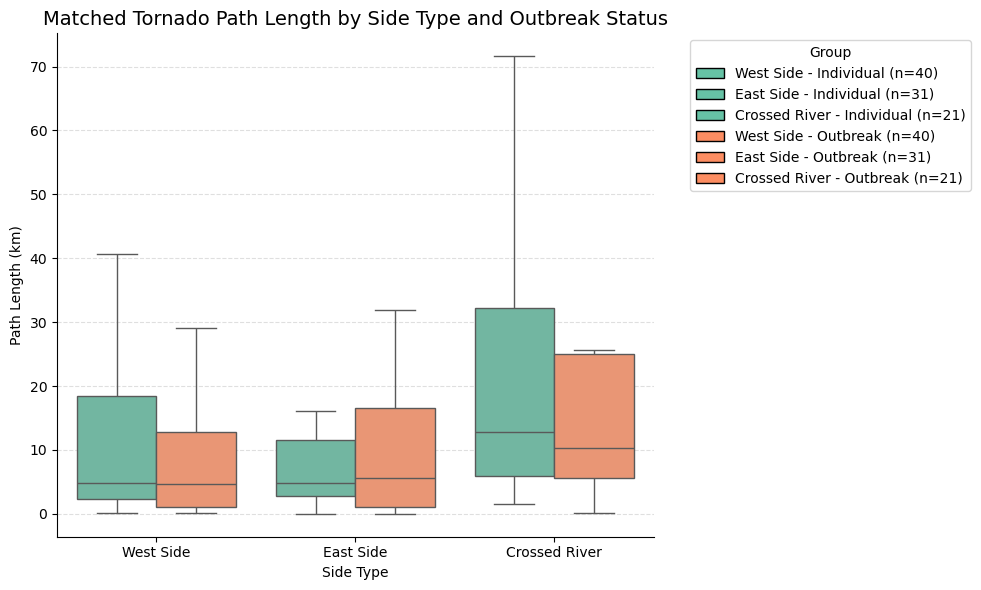


--- 5-Number Summary (Matched Sample) ---


,Group,Min,Q1,Median,Q3,Max
0,West Side - Individual,0.06,1.09,4.61,12.87,137.12
1,West Side - Outbreak,0.16,2.39,4.83,18.51,51.50
2,East Side - Individual,0.03,1.12,5.63,16.60,78.37
3,East Side - Outbreak,0.00,2.82,4.83,11.59,107.83
4,Crossed River - Individual,0.16,5.63,10.30,24.94,180.41
5,Crossed River - Outbreak,1.61,5.86,12.87,32.19,111.37



Kruskal-Wallis Test (Matched Groups)
------------------------------------
H = 11.283
p-value = 0.046048

Pairwise Kruskal-Wallis Tests (Matched Sample)
----------------------------------------------


,Group1,Group2,H,p-value,Adj p-value (Bonferroni),Significant?,Adj Significant?
0,West Side - Individual,West Side - Outbreak,0.422108,0.515887,7.738309,False,False
1,West Side - Individual,East Side - Individual,0.109203,0.741054,11.115806,False,False
2,West Side - Individual,East Side - Outbreak,0.363502,0.546568,8.198517,False,False
3,West Side - Individual,Crossed River - Individual,4.169032,0.041169,0.617540,True,False
4,West Side - Individual,Crossed River - Outbreak,6.583138,0.010295,0.154424,True,False
5,West Side - Outbreak,East Side - Individual,0.014831,0.903070,13.546057,False,False
6,West Side - Outbreak,East Side - Outbreak,0.000841,0.976867,14.652998,False,False
7,West Side - Outbreak,Crossed River - Individual,2.494606,0.114237,1.713554,False,False
8,West Side - Outbreak,Crossed River - Outbreak,5.085332,0.024129,0.361936,True,False
9,East Side - Individual,East Side - Outbreak,0.047653,0.827199,12.407991,False,False


In [40]:
# ------------------------------------------------
# 1. Build base dataset
# ------------------------------------------------
plot_df = pd.concat([
    west_side.assign(side_type="West Side"),
    east_side.assign(side_type="East Side"),
    crossing_tornadoes.assign(side_type="Crossed River")
]).copy()

# Path length
plot_df["path_km"] = plot_df["len"] * 1.60934

# Outbreak classification
plot_df["outbreak_type"] = plot_df["outbreak_24h"]

# Clean
plot_df = plot_df.dropna(subset=["path_km","side_type","outbreak_type","mag"])

# ------------------------------------------------
# 2. MATCHED SUBSAMPLING (CORE STEP)
# ------------------------------------------------
matched_rows = []

for side in ["West Side","East Side","Crossed River"]:
    for ef in sorted(plot_df["mag"].unique()):

        outbreak_subset = plot_df[
            (plot_df["side_type"] == side) &
            (plot_df["outbreak_type"] == "Outbreak") &
            (plot_df["mag"] == ef)
        ]

        non_subset = plot_df[
            (plot_df["side_type"] == side) &
            (plot_df["outbreak_type"] == "Individual") &
            (plot_df["mag"] == ef)
        ]

        n = len(outbreak_subset)

        if n == 0:
            continue

        # If enough non-outbreak tornadoes → sample without replacement
        if len(non_subset) >= n:
            sampled_non = non_subset.sample(n=n, replace=False, random_state=42)
        else:
            # Otherwise fallback to replacement
            sampled_non = non_subset.sample(n=n, replace=True, random_state=42)

        matched_rows.append(outbreak_subset)
        matched_rows.append(sampled_non)

# Combine matched dataset
matched_df = pd.concat(matched_rows)

# ------------------------------------------------
# 3. Boxplot (balanced groups)
# ------------------------------------------------
plt.figure(figsize=(10,6))

palette = sns.color_palette("Set2", 2)

ax = sns.boxplot(
    data=matched_df,
    x="side_type",
    y="path_km",
    hue="outbreak_type",
    palette=palette,
    showfliers=False
)

# Counts
counts = matched_df.groupby(["side_type","outbreak_type"]).size()

legend_elements = []
for i, ot in enumerate(["Individual","Outbreak"]):
    for side in ["West Side","East Side","Crossed River"]:
        if (side, ot) in counts:
            legend_elements.append(
                Patch(
                    facecolor=palette[i],
                    edgecolor='black',
                    label=f"{side} - {ot} (n={counts[(side, ot)]})"
                )
            )

ax.legend(handles=legend_elements, title="Group", bbox_to_anchor=(1.05,1), loc="upper left")

ax.set_title("Matched Tornado Path Length by Side Type and Outbreak Status", fontsize=14)
ax.set_xlabel("Side Type")
ax.set_ylabel("Path Length (km)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 4. 5-number summary
# ------------------------------------------------
def five_number(series):
    return [
        np.min(series),
        np.percentile(series, 25),
        np.median(series),
        np.percentile(series, 75),
        np.max(series)
    ]

order = []
for side in ["West Side","East Side","Crossed River"]:
    for ot in ["Individual","Outbreak"]:
        order.append((side, ot))

summary_rows = []

for side, ot in order:
    subset = matched_df[
        (matched_df["side_type"] == side) &
        (matched_df["outbreak_type"] == ot)
    ]["path_km"]

    if len(subset) == 0:
        continue

    stats = five_number(subset)

    summary_rows.append([
        f"{side} - {ot}",
        round(stats[0],2),
        round(stats[1],2),
        round(stats[2],2),
        round(stats[3],2),
        round(stats[4],2)
    ])

summary_df = pd.DataFrame(
    summary_rows,
    columns=["Group","Min","Q1","Median","Q3","Max"]
)

print("\n--- 5-Number Summary (Matched Sample) ---")
display(summary_df)

# ------------------------------------------------
# 5. Kruskal-Wallis
# ------------------------------------------------
groups = [
    matched_df[
        (matched_df["side_type"] == side) &
        (matched_df["outbreak_type"] == ot)
    ]["path_km"]
    for side, ot in order
    if len(matched_df[
        (matched_df["side_type"] == side) &
        (matched_df["outbreak_type"] == ot)
    ]) > 0
]

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test (Matched Groups)")
print("------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

# ------------------------------------------------
# 6. Pairwise comparisons
# ------------------------------------------------
results = []

valid_groups = [
    (side, ot) for side, ot in order
    if len(matched_df[
        (matched_df["side_type"] == side) &
        (matched_df["outbreak_type"] == ot)
    ]) > 0
]

for (s1, o1), (s2, o2) in itertools.combinations(valid_groups, 2):

    data1 = matched_df[
        (matched_df["side_type"] == s1) &
        (matched_df["outbreak_type"] == o1)
    ]["path_km"]

    data2 = matched_df[
        (matched_df["side_type"] == s2) &
        (matched_df["outbreak_type"] == o2)
    ]["path_km"]

    H_pair, p_pair = kruskal(data1, data2)

    results.append({
        "Group1": f"{s1} - {o1}",
        "Group2": f"{s2} - {o2}",
        "H": H_pair,
        "p-value": p_pair
    })

results_df = pd.DataFrame(results)

# Bonferroni correction
results_df["Adj p-value (Bonferroni)"] = results_df["p-value"] * len(results_df)
results_df["Significant?"] = results_df["p-value"] < 0.05
results_df["Adj Significant?"] = results_df["Adj p-value (Bonferroni)"] < 0.05

print("\nPairwise Kruskal-Wallis Tests (Matched Sample)")
print("----------------------------------------------")
display(results_df)

In [41]:
# ------------------------------------------------
# 1. Raw counts (long format)
# ------------------------------------------------
count_table = (
    matched_df
    .groupby(["side_type", "outbreak_type", "mag"])
    .size()
    .reset_index(name="count")
    .sort_values(["side_type","outbreak_type","mag"])
)

print("\n--- Counts by Side × Outbreak × EF Scale ---")
display(count_table)

# ------------------------------------------------
# 2. Pivot table (wide format, easier to read)
# ------------------------------------------------
pivot_table = count_table.pivot_table(
    index=["side_type","outbreak_type"],
    columns="mag",
    values="count",
    fill_value=0
)

pivot_table.columns = [f"EF{int(c)}" for c in pivot_table.columns]

print("\n--- Pivot Table (Counts) ---")
display(pivot_table)

# ------------------------------------------------
# 3. Row totals (sanity check)
# ------------------------------------------------
pivot_table["Total"] = pivot_table.sum(axis=1)

print("\n--- With Totals ---")
display(pivot_table)

# ------------------------------------------------
# 4. Percent distribution (optional but useful)
# ------------------------------------------------
percent_table = pivot_table.div(pivot_table["Total"], axis=0) * 100

print("\n--- Percent Distribution (%) ---")
display(percent_table.round(2))


--- Counts by Side × Outbreak × EF Scale ---


,side_type,outbreak_type,mag,count
0,Crossed River,Individual,0,8
1,Crossed River,Individual,1,3
2,Crossed River,Individual,2,5
3,Crossed River,Individual,3,4
4,Crossed River,Individual,4,1
5,Crossed River,Outbreak,0,8
6,Crossed River,Outbreak,1,3
7,Crossed River,Outbreak,2,5
8,Crossed River,Outbreak,3,4
9,Crossed River,Outbreak,4,1



--- Pivot Table (Counts) ---


EF0   EF1  EF2  EF3  EF4
side_type     outbreak_type                           
Crossed River Individual      8.0   3.0  5.0  4.0  1.0
              Outbreak        8.0   3.0  5.0  4.0  1.0
East Side     Individual      8.0  16.0  4.0  3.0  0.0
              Outbreak        8.0  16.0  4.0  3.0  0.0
West Side     Individual     16.0  11.0  7.0  6.0  0.0
              Outbreak       16.0  11.0  7.0  6.0  0.0


--- With Totals ---


EF0   EF1  EF2  EF3  EF4  Total
side_type     outbreak_type                                  
Crossed River Individual      8.0   3.0  5.0  4.0  1.0   21.0
              Outbreak        8.0   3.0  5.0  4.0  1.0   21.0
East Side     Individual      8.0  16.0  4.0  3.0  0.0   31.0
              Outbreak        8.0  16.0  4.0  3.0  0.0   31.0
West Side     Individual     16.0  11.0  7.0  6.0  0.0   40.0
              Outbreak       16.0  11.0  7.0  6.0  0.0   40.0


--- Percent Distribution (%) ---


EF0    EF1    EF2    EF3   EF4  Total
side_type     outbreak_type                                         
Crossed River Individual     38.10  14.29  23.81  19.05  4.76  100.0
              Outbreak       38.10  14.29  23.81  19.05  4.76  100.0
East Side     Individual     25.81  51.61  12.90   9.68  0.00  100.0
              Outbreak       25.81  51.61  12.90   9.68  0.00  100.0
West Side     Individual     40.00  27.50  17.50  15.00  0.00  100.0
              Outbreak       40.00  27.50  17.50  15.00  0.00  100.0

In [42]:
import numpy as np
import pandas as pd
from scipy.stats import kruskal
import itertools

N_ITER = 10000

results = []

# Predefine groups
sides = ["West Side", "East Side", "Crossed River"]
types = ["Individual", "Outbreak"]

for i in range(N_ITER):

    matched_rows = []

    # ------------------------------------------------
    # MATCHING STEP (same logic as before)
    # ------------------------------------------------
    for side in sides:
        for ef in sorted(plot_df["mag"].unique()):

            outbreak_subset = plot_df[
                (plot_df["side_type"] == side) &
                (plot_df["outbreak_type"] == "Outbreak") &
                (plot_df["mag"] == ef)
            ]

            non_subset = plot_df[
                (plot_df["side_type"] == side) &
                (plot_df["outbreak_type"] == "Individual") &
                (plot_df["mag"] == ef)
            ]

            n = len(outbreak_subset)

            if n == 0:
                continue

            if len(non_subset) >= n:
                sampled_non = non_subset.sample(n=n, replace=False)
            else:
                sampled_non = non_subset.sample(n=n, replace=True)

            matched_rows.append(outbreak_subset)
            matched_rows.append(sampled_non)

    matched_df = pd.concat(matched_rows)

    # ------------------------------------------------
    # MEDIANS
    # ------------------------------------------------
    medians = {}

    for side in sides:
        for t in types:
            subset = matched_df[
                (matched_df["side_type"] == side) &
                (matched_df["outbreak_type"] == t)
            ]["path_km"]

            if len(subset) > 0:
                medians[f"{side}_{t}"] = np.median(subset)

    # ------------------------------------------------
    # KRUSKAL-WALLIS
    # ------------------------------------------------
    groups = [
        matched_df[
            (matched_df["side_type"] == side) &
            (matched_df["outbreak_type"] == t)
        ]["path_km"]
        for side in sides for t in types
    ]

    H, p = kruskal(*groups)

    # ------------------------------------------------
    # PAIRWISE
    # ------------------------------------------------
    pairwise_results = {}

    group_labels = [(side, t) for side in sides for t in types]

    for (s1, t1), (s2, t2) in itertools.combinations(group_labels, 2):

        data1 = matched_df[
            (matched_df["side_type"] == s1) &
            (matched_df["outbreak_type"] == t1)
        ]["path_km"]

        data2 = matched_df[
            (matched_df["side_type"] == s2) &
            (matched_df["outbreak_type"] == t2)
        ]["path_km"]

        _, p_pair = kruskal(data1, data2)

        key = f"{s1}_{t1} vs {s2}_{t2}"
        pairwise_results[key] = p_pair

    # Store iteration
    results.append({
        "H": H,
        "p": p,
        **medians,
        **pairwise_results
    })

# ------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------
results_df = pd.DataFrame(results)

# ------------------------------------------------
# SUMMARY OUTPUT
# ------------------------------------------------
print("\n==============================")
print(" ROBUSTNESS SUMMARY (10,000 runs)")
print("==============================")

# Overall test
print("\nKruskal-Wallis:")
print("Mean p-value:", results_df["p"].mean())
print("Median p-value:", results_df["p"].median())
print("Std p-value:", results_df["p"].std())
print("% Significant (p<0.05):", (results_df["p"] < 0.05).mean()*100)

# Medians
print("\n--- Median Path Length (km) ---")
median_cols = [c for c in results_df.columns if "West" in c or "East" in c or "Crossed" in c]

summary_medians = results_df[median_cols].describe().loc[["mean","std","min","25%","50%","75%","max"]]
display(summary_medians)

# Pairwise significance
pairwise_cols = [c for c in results_df.columns if "vs" in c]

print("\n--- Pairwise Significance (% p < 0.05) ---")
pairwise_sig = {
    col: (results_df[col] < 0.05).mean()*100
    for col in pairwise_cols
}

pairwise_sig_df = pd.DataFrame.from_dict(pairwise_sig, orient="index", columns=["% Significant"])
display(pairwise_sig_df.sort_values("% Significant", ascending=False))


 ROBUSTNESS SUMMARY (10,000 runs)

Kruskal-Wallis:
Mean p-value: 0.014579415167735891
Median p-value: 0.008291470370304052
Std p-value: 0.017892237808304026
% Significant (p<0.05): 94.89

--- Median Path Length (km) ---


,West Side_Individual,West Side_Outbreak,East Side_Individual,East Side_Outbreak,Crossed River_Individual,Crossed River_Outbreak,West Side_Individual vs West Side_Outbreak,West Side_Individual vs East Side_Individual,West Side_Individual vs East Side_Outbreak,West Side_Individual vs Crossed River_Individual,...,West Side_Outbreak vs East Side_Individual,West Side_Outbreak vs East Side_Outbreak,West Side_Outbreak vs Crossed River_Individual,West Side_Outbreak vs Crossed River_Outbreak,East Side_Individual vs East Side_Outbreak,East Side_Individual vs Crossed River_Individual,East Side_Individual vs Crossed River_Outbreak,East Side_Outbreak vs Crossed River_Individual,East Side_Outbreak vs Crossed River_Outbreak,Crossed River_Individual vs Crossed River_Outbreak
mean,3.609515,4.828020e+00,4.386601,4.828020e+00,13.235668,1.287472e+01,0.351124,0.655217,0.350634,0.033682,...,0.483029,9.768666e-01,0.122503,0.024129,0.470663,0.044603,0.006670,0.095992,2.341678e-02,0.699190
std,0.949520,8.882228e-16,1.234382,8.882228e-16,2.882682,1.776446e-15,0.184970,0.229232,0.186951,0.047137,...,0.233421,3.330836e-16,0.111987,0.000000,0.236456,0.061514,0.008178,0.085639,3.469620e-18,0.200982
min,1.311612,4.828020e+00,1.609340,4.828020e+00,5.632690,1.287472e+01,0.014491,0.021045,0.013085,0.000079,...,0.022967,9.768666e-01,0.000859,0.024129,0.020143,0.000046,0.000026,0.001842,2.341678e-02,0.055857
25%,2.945092,4.828020e+00,3.218680,4.828020e+00,10.943512,1.287472e+01,0.209081,0.486482,0.206264,0.006430,...,0.299030,9.768666e-01,0.044154,0.024129,0.281378,0.008780,0.001780,0.035885,2.341678e-02,0.554381
50%,3.443988,4.828020e+00,4.828020,4.828020e+00,14.162192,1.287472e+01,0.320285,0.684875,0.321464,0.017154,...,0.457783,9.768666e-01,0.088944,0.024129,0.442761,0.022877,0.003956,0.068994,2.341678e-02,0.724671
75%,3.838276,4.828020e+00,4.828020,4.828020e+00,14.693274,1.287472e+01,0.461468,0.848279,0.461592,0.040431,...,0.646849,9.768666e-01,0.166886,0.024129,0.637143,0.055824,0.008086,0.128499,2.341678e-02,0.870105
max,9.816974,4.828020e+00,9.977908,4.828020e+00,34.761744,1.287472e+01,1.000000,1.000000,1.000000,0.543718,...,1.000000,9.768666e-01,0.951548,0.024129,1.000000,0.830169,0.102682,0.881360,2.341678e-02,1.000000



--- Pairwise Significance (% p < 0.05) ---


,% Significant
West Side_Outbreak vs Crossed River_Outbreak,100.00
East Side_Outbreak vs Crossed River_Outbreak,100.00
West Side_Individual vs Crossed River_Outbreak,99.91
East Side_Individual vs Crossed River_Outbreak,99.58
West Side_Individual vs Crossed River_Individual,80.08
East Side_Individual vs Crossed River_Individual,72.23
East Side_Outbreak vs Crossed River_Individual,36.24
West Side_Outbreak vs Crossed River_Individual,28.54
West Side_Individual vs East Side_Outbreak,0.55
East Side_Individual vs East Side_Outbreak,0.40


In [43]:
#Side note for interpretation of the results: Pairwise comparisons indicated that differences involving crossing tornadoes were statistically significant
#in over 90–100% of iterations, whereas differences between outbreak and non-outbreak tornadoes within the same side classification were not robust. 
#These results suggest that river interaction is a stronger determinant of tornado path length than outbreak classification.”

In [44]:
print("\n--- Outbreak tornado counts by time period ---")

mask1 = (tornado_gdf["datetime"] >= "1950-01-01") & (tornado_gdf["datetime"] <= "1975-12-31")
mask2 = (tornado_gdf["datetime"] >= "1999-01-01") & (tornado_gdf["datetime"] <= "2024-12-31")

print("1950–1975:")
print(tornado_gdf[mask1]["outbreak_24h"].value_counts())

print("\n1999–2024:")
print(tornado_gdf[mask2]["outbreak_24h"].value_counts())


--- Outbreak tornado counts by time period ---
1950–1975:
outbreak_24h
Individual    737
Outbreak       30
Name: count, dtype: int64

1999–2024:
outbreak_24h
Individual    3050
Outbreak      1048
Name: count, dtype: int64


In [45]:
#The cell above prints out the post-cleaned and post-filtered counts of outbreak/individual tornadoes. Total, including 1976-1998 period, will be approximately 5793 tornadoes. 

In [46]:
print("\n--- Outbreak tornado counts by time period ---")

csv = pd.read_csv("/home/njm12/ATMS_596/ATMS-596-Capstone-Project/CSV Files/tornadoes_with_dbscan_outbreaks.csv")

mask = (pd.to_datetime(csv["datetime"], utc=True) >= "1950-01-01") & \
       (pd.to_datetime(csv["datetime"], utc=True) <= "1975-12-31")

mask_2 = (pd.to_datetime(csv["datetime"], utc=True) >= "1999-01-01") & \
       (pd.to_datetime(csv["datetime"], utc=True) <= "2024-12-31")

print("1950–1975:")
print(csv.loc[mask, "outbreak_24h"].value_counts())

print("\n1999–2024:")
print(csv.loc[mask_2, "outbreak_24h"].value_counts())


--- Outbreak tornado counts by time period ---
1950–1975:
outbreak_24h
Individual    1875
Outbreak       108
Name: count, dtype: int64

1999–2024:
outbreak_24h
Individual    3067
Outbreak      1050
Name: count, dtype: int64


In [47]:
#The cell above prints out the pre-cleaned and pre-filtered counts of outbreak/individual tornadoes. Total, including 1976-1998 period, will be approximately 8287 tornadoes.

In [48]:
# ================================================================
# INTERACTIVE MAP (FAST + INLINE)
# Crossed-River Outbreak Tornadoes (n = 21)
# ================================================================

import folium
import geopandas as gpd
from IPython.display import display

# ------------------------------------------------
# 1. Select crossed-river outbreak tornadoes
# ------------------------------------------------
crossed_outbreaks = crossing_tornadoes[
    crossing_tornadoes["outbreak_24h_original"] == "Outbreak"
].copy()

print("Crossed-river outbreak tornadoes:", len(crossed_outbreaks))

# ------------------------------------------------
# 2. Convert to lat/lon
# ------------------------------------------------
crossed_latlon = crossed_outbreaks.to_crs("EPSG:4326")

river_latlon = gpd.GeoSeries([river_il_geom], crs=target_crs).to_crs("EPSG:4326")
buffer_latlon = gpd.GeoSeries([river_buffer], crs=target_crs).to_crs("EPSG:4326")

# ------------------------------------------------
# 3. SIMPLIFY GEOMETRY (CRITICAL FOR PERFORMANCE)
# ------------------------------------------------
river_simple = river_latlon.copy()
river_simple.iloc[0] = river_simple.iloc[0].simplify(0.005)

buffer_simple = buffer_latlon.copy()
buffer_simple.iloc[0] = buffer_simple.iloc[0].simplify(0.01)

# ------------------------------------------------
# 4. Map setup
# ------------------------------------------------
m = folium.Map(
    location=[41.5, -90.5],
    zoom_start=6,
    tiles="CartoDB positron",
    width="100%",
    height="650px"
)

# ------------------------------------------------
# 5. Add river buffer (red outline)
# ------------------------------------------------
folium.GeoJson(
    buffer_simple.iloc[0],
    style_function=lambda x: {
        "fillColor": "none",
        "color": "red",
        "weight": 2
    },
    name="10 km Buffer"
).add_to(m)

# ------------------------------------------------
# 6. Add river (blue)
# ------------------------------------------------
folium.GeoJson(
    river_simple.iloc[0],
    style_function=lambda x: {
        "color": "blue",
        "weight": 2
    },
    name="Mississippi River"
).add_to(m)

# ------------------------------------------------
# 7. Tornado tracks
# ------------------------------------------------
cluster_col = "cluster_24h"  # adjust if needed

for _, row in crossed_latlon.iterrows():

    geom = row.geometry

    length_km = row["len"] * 1.60934
    # Short popup for speed
    popup_text = (
        f"Date: {row['date']}<br>"
        f"EF: {row['mag']}<br>"
        f"Length: {length_km:.2f} km<br>"   
        f"Cluster: {row.get(cluster_col, 'N/A')}"
    )

    popup = folium.Popup(popup_text, max_width=250)

    # LINESTRING (track)
    if geom.geom_type == "LineString":
        coords = [(lat, lon) for lon, lat in geom.coords]

        folium.PolyLine(
            coords,
            color="darkred",
            weight=3,
            opacity=0.8,
            popup=popup,
            smooth_factor=2
        ).add_to(m)

    # POINT fallback
    elif geom.geom_type == "Point":
        folium.CircleMarker(
            location=[geom.y, geom.x],
            radius=5,
            color="darkred",
            fill=True,
            fill_opacity=0.8,
            popup=popup
        ).add_to(m)

# ------------------------------------------------
# 8. Layer control
# ------------------------------------------------
folium.LayerControl().add_to(m)

# ------------------------------------------------
# 9. Cluster counts (printed)
# ------------------------------------------------
print("\nOutbreak cluster counts:")
print(
    crossed_latlon[cluster_col]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------
# 10. DISPLAY INLINE
# ------------------------------------------------
display(m)

Crossed-river outbreak tornadoes: 21

Outbreak cluster counts:
cluster_24h
25     2
235    1
352    1
353    3
361    2
384    2
437    1
438    3
487    1
559    1
719    1
742    1
745    2
Name: count, dtype: int64


In [49]:
# ================================================================
# INTERACTIVE MAP: ALL BUFFER TORNADOES (372)
# Categorized by Side + Outbreak Status
# ================================================================

import folium
import geopandas as gpd
from IPython.display import display

# ------------------------------------------------
# 1. Combine all buffer tornadoes
# ------------------------------------------------
buffer_tornadoes = pd.concat([
    west_side,
    east_side,
    crossing_tornadoes
]).copy()

print("Total buffer tornadoes:", len(buffer_tornadoes))

# ------------------------------------------------
# 2. Assign side_type
# ------------------------------------------------
buffer_tornadoes["side_type"] = None
buffer_tornadoes.loc[west_side.index, "side_type"] = "West Side"
buffer_tornadoes.loc[east_side.index, "side_type"] = "East Side"
buffer_tornadoes.loc[crossing_tornadoes.index, "side_type"] = "Crossed River"

# ------------------------------------------------
# 3. Convert to lat/lon
# ------------------------------------------------
buffer_latlon = buffer_tornadoes.to_crs("EPSG:4326")

river_latlon = gpd.GeoSeries([river_il_geom], crs=target_crs).to_crs("EPSG:4326")
buffer_geom_latlon = gpd.GeoSeries([river_buffer], crs=target_crs).to_crs("EPSG:4326")

# ------------------------------------------------
# 4. Simplify geometry (CRITICAL)
# ------------------------------------------------
river_simple = river_latlon.copy()
river_simple.iloc[0] = river_simple.iloc[0].simplify(0.005)

buffer_simple = buffer_geom_latlon.copy()
buffer_simple.iloc[0] = buffer_simple.iloc[0].simplify(0.01)

# ------------------------------------------------
# 5. Map setup
# ------------------------------------------------
m = folium.Map(
    location=[41.5, -90.5],
    zoom_start=6,
    tiles="CartoDB positron",
    width="100%",
    height="650px"
)

# ------------------------------------------------
# 6. Add buffer (red outline)
# ------------------------------------------------
folium.GeoJson(
    buffer_simple.iloc[0],
    style_function=lambda x: {
        "fillColor": "none",
        "color": "red",
        "weight": 2
    },
    name="10 km Buffer"
).add_to(m)

# ------------------------------------------------
# 7. Add river
# ------------------------------------------------
folium.GeoJson(
    river_simple.iloc[0],
    style_function=lambda x: {
        "color": "blue",
        "weight": 2
    },
    name="Mississippi River"
).add_to(m)

# ------------------------------------------------
# 8. Color mapping by side
# ------------------------------------------------
color_map = {
    "West Side": "blue",
    "East Side": "green",
    "Crossed River": "red"
}

cluster_col = "cluster_24h"  # adjust if needed

# ------------------------------------------------
# 9. Plot tornado tracks
# ------------------------------------------------
for _, row in buffer_latlon.iterrows():

    geom = row.geometry
    side = row["side_type"]
    color = color_map.get(side, "black")

    # Convert miles → km
    length_km = row["len"] * 1.60934

    # Popup info
    popup_text = (
        f"<b>Date:</b> {row['date']}<br>"
        f"<b>EF:</b> {row['mag']}<br>"
        f"<b>Length:</b> {length_km:.2f} km<br>"
        f"<b>Side:</b> {side}<br>"
        f"<b>Type:</b> {row['outbreak_24h_original']}<br>"
        f"<b>Cluster:</b> {row.get(cluster_col, 'N/A')}"
    )

    popup = folium.Popup(popup_text, max_width=250)

    # LineString (preferred)
    if geom.geom_type == "LineString":
        coords = [(lat, lon) for lon, lat in geom.coords]

        folium.PolyLine(
            coords,
            color=color,
            weight=2.5,
            opacity=0.8,
            popup=popup,
            smooth_factor=2
        ).add_to(m)

    # Point fallback
    elif geom.geom_type == "Point":
        folium.CircleMarker(
            location=[geom.y, geom.x],
            radius=4,
            color=color,
            fill=True,
            fill_opacity=0.8,
            popup=popup
        ).add_to(m)

# ------------------------------------------------
# 10. Legend (custom HTML)
# ------------------------------------------------
legend_html = """
<div style="
    position: fixed; 
    bottom: 50px; left: 50px; width: 200px; height: 120px; 
    background-color: white; 
    border:2px solid grey; z-index:9999; font-size:14px;
    padding: 10px;
">
<b>Tornado Type</b><br>
<span style="color:blue;">■</span> West Side<br>
<span style="color:green;">■</span> East Side<br>
<span style="color:red;">■</span> Crossed River<br>
</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))

# ------------------------------------------------
# 11. Layer control
# ------------------------------------------------
folium.LayerControl().add_to(m)

# ------------------------------------------------
# 12. Save + Display
# ------------------------------------------------
output_file = "buffer_tornado_map.html"
m.save(output_file)

print(f"\nMap saved to: {output_file}")

display(m)

Total buffer tornadoes: 372

Map saved to: buffer_tornado_map.html


Total buffer tornadoes: 372


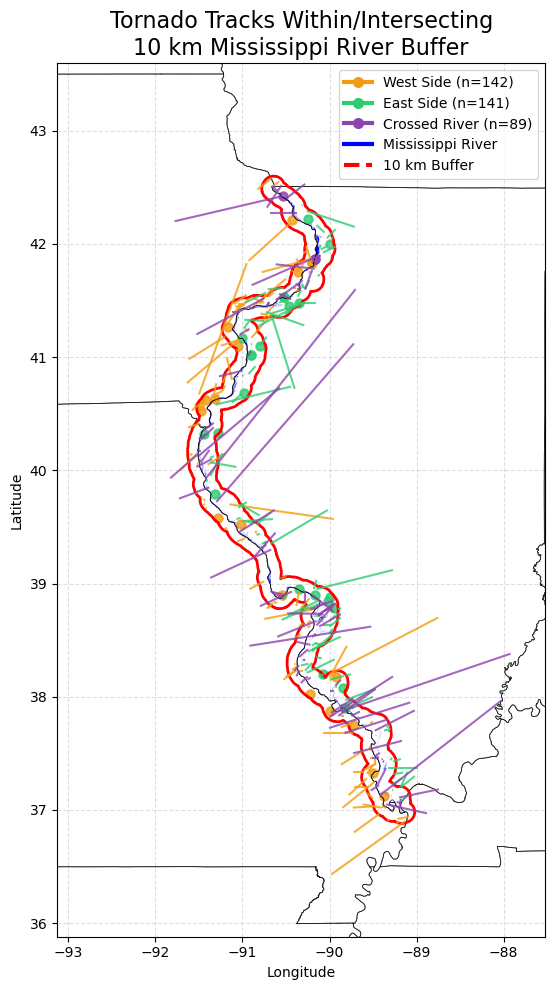


--- Tornado Counts ---
side_type
West Side        142
East Side        141
Crossed River     89
Name: count, dtype: int64


In [52]:
# ================================================================
# STATIC MAP: Mississippi River Buffer Tornadoes
# Combined Line + Point Legend Symbols
# ================================================================

import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from matplotlib.lines import Line2D

# ------------------------------------------------
# 1. Combine tornadoes
# ------------------------------------------------
buffer_tornadoes = pd.concat([
    west_side,
    east_side,
    crossing_tornadoes
]).copy()

print("Total buffer tornadoes:", len(buffer_tornadoes))

# ------------------------------------------------
# 2. Assign side type
# ------------------------------------------------
buffer_tornadoes["side_type"] = None

buffer_tornadoes.loc[
    west_side.index, "side_type"
] = "West Side"

buffer_tornadoes.loc[
    east_side.index, "side_type"
] = "East Side"

buffer_tornadoes.loc[
    crossing_tornadoes.index, "side_type"
] = "Crossed River"

# ------------------------------------------------
# 3. Convert to lat/lon
# ------------------------------------------------
buffer_latlon = buffer_tornadoes.to_crs("EPSG:4326")

river_latlon = gpd.GeoSeries(
    [river_il_geom],
    crs=target_crs
).to_crs("EPSG:4326")

buffer_geom_latlon = gpd.GeoSeries(
    [river_buffer],
    crs=target_crs
).to_crs("EPSG:4326")

# ------------------------------------------------
# 4. GeoDataFrames
# ------------------------------------------------
river_gdf = gpd.GeoDataFrame(
    geometry=river_latlon,
    crs="EPSG:4326"
)

buffer_gdf = gpd.GeoDataFrame(
    geometry=buffer_geom_latlon,
    crs="EPSG:4326"
)

# ------------------------------------------------
# 5. Colors
# ------------------------------------------------
color_map = {
    "West Side": "#f39c12",      # orange
    "East Side": "#2ecc71",      # green
    "Crossed River": "#8e44ad"   # purple
}

# ------------------------------------------------
# 6. Plot setup
# ------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

# ------------------------------------------------
# 7. Plot state boundaries
# ------------------------------------------------
states.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.6,
    alpha=0.7
)

# ------------------------------------------------
# 8. Plot river buffer
# ------------------------------------------------
buffer_gdf.boundary.plot(
    ax=ax,
    color="red",
    linewidth=2
)

# ------------------------------------------------
# 9. Plot Mississippi River
# ------------------------------------------------
river_gdf.plot(
    ax=ax,
    color="blue",
    linewidth=2
)

# ------------------------------------------------
# 10. Plot tornado tracks
# ------------------------------------------------
for side, color in color_map.items():

    subset = buffer_latlon[
        buffer_latlon["side_type"] == side
    ]

    subset.plot(
        ax=ax,
        color=color,
        linewidth=1.5,
        alpha=0.8
    )

# ------------------------------------------------
# 11. Zoom to river region
# ------------------------------------------------
minx, miny, maxx, maxy = buffer_gdf.total_bounds

pad_x = 1.5
pad_y = 1.0

ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

# ------------------------------------------------
# 12. Labels
# ------------------------------------------------
ax.set_title(
    "Tornado Tracks Within/Intersecting\n"
    "10 km Mississippi River Buffer",
    fontsize=16
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.grid(
    linestyle="--",
    alpha=0.4
)

# ------------------------------------------------
# 13. Custom legend
# (combined line + point symbols)
# ------------------------------------------------
counts = buffer_tornadoes["side_type"].value_counts()

legend_elements = [

    # Tornado groups
    Line2D(
        [0], [0],
        color=color_map["West Side"],
        lw=3,
        marker='o',
        markersize=7,
        label=f"West Side (n={counts['West Side']})"
    ),

    Line2D(
        [0], [0],
        color=color_map["East Side"],
        lw=3,
        marker='o',
        markersize=7,
        label=f"East Side (n={counts['East Side']})"
    ),

    Line2D(
        [0], [0],
        color=color_map["Crossed River"],
        lw=3,
        marker='o',
        markersize=7,
        label=f"Crossed River (n={counts['Crossed River']})"
    ),

    # River
    Line2D(
        [0], [0],
        color='blue',
        lw=3,
        label='Mississippi River'
    ),

    # Buffer
    Line2D(
        [0], [0],
        color='red',
        lw=3,
        linestyle='--',
        label='10 km Buffer'
    )
]

ax.legend(
    handles=legend_elements,
    loc="upper right",
    fontsize=10,
    frameon=True
)

# ------------------------------------------------
# 14. Layout
# ------------------------------------------------
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 15. Counts
# ------------------------------------------------
print("\n--- Tornado Counts ---")
print(buffer_tornadoes["side_type"].value_counts())